In [1]:
#!pip install jax
#!pip install lightkurve
import numpy as np
import lightkurve as lk
import matplotlib.pyplot as plt
import pandas as pd
import csv
import glob
import os
from astropy.io import fits
from scipy.ndimage import uniform_filter1d
from scipy.optimize import curve_fit
from tqdm import tqdm

C:\Users\douga\anaconda3\Lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [52]:
#DEFINE SCALING RELATION
    
def delta_nu_from_numax(numax):
    return 0.263 * numax**0.772
    
#DEFINE SLIDING AUTOCORRELATION
    
def sliding_acf_search(frequency, #frequency array
                       power_flat, #flattened power spectrum
                       numax_grid, #array of values of nu_max to run autocorrelation around
                       k_width=4.0, #width of each window as a multiple of delta_nu
                       lag_frac=(0.8, 1.2) 
                      ):
    
    acf_strength = [] #array to store acf strengths for each nu_max in numax_grid
    df = frequency[1] - frequency[0] #frequency resolution
    for nu_c in numax_grid:
    
        #use scaling relation to get estimated delta_nu for each nu_max
        dnu = delta_nu_from_numax(nu_c)
    
        #window width
        W = k_width * dnu

        #create mask of width W around nu_c
        mask = (frequency > nu_c - W/2) & (frequency < nu_c + W/2)
        if mask.sum() < 20:
            acf_strength.append(0.0)
            continue
    
        # local, whitened spectrum (normalises, so oscillations stand out)
        p = power_flat[mask]
        p = p / np.median(p)
    
        # autocorrelation
        acf = np.correlate(p - np.mean(p), p - np.mean(p), mode="full")
        acf = acf[acf.size//2:] #keep only the positive lag values, because the acf is symmetric
    
        # lag axis
        lag = np.arange(acf.size) * df
    
        # measure strength near Δν
        lag_mask = (lag > lag_frac[0]*dnu) & (lag < lag_frac[1]*dnu)
        strength = np.max(acf[lag_mask])
    
        acf_strength.append(strength)
    
    return np.array(acf_strength)

#DEFINE MASK AROUND DELTA_NU_EST PEAK

def mask_acf_for_deltanu(lags, acf, delta_nu_est, window_frac):    
        
        # Central window around delta_nu
        main_lo = delta_nu_est * (1 - window_frac)
        main_hi = delta_nu_est * (1 + window_frac)
    
        mask = (
            (lags > main_lo) & (lags < main_hi)
        )
    
        return lags[mask], acf[mask]

#FUNCTIONS FOR GENERATING NOISE

def random(values):
    randomised = []
    for i in values:
        a=np.random.uniform(0,1)
        randomised.append(i*-np.log(a))
    return randomised

def fake_signals(freqs, N, noise_lvl):
    # freqs: list of frequencies
    # N: number of different fake signals
    # noise_lvl: desired whitenoise level
    #returns N noise only spectra
    signals= []
    for i in range(0,N):
        fake_base=[noise_lvl]*len(freqs)
        fake_signal=random(fake_base)
        signals.append(fake_signal)
    return np.array(signals)

#DEFINE GAUSSIAN

def gaussian(x, A, mu, sigma, c):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2) + c

#FIND METRICS FOR DETECTION STRENGTH OF NU_MAX, DELTA_NU AND COMBINED METRIC

def find_metric(power, freq):
    #SMOOTHING
        
    df = np.median(np.diff(freq))  # µHz
    smooth_width_muHz = 500    #justify smoothing choice - larger scales than delta_nu
    smooth_width_bins = int(smooth_width_muHz / df)
    background = uniform_filter1d(power, size =smooth_width_bins) #find background
    power_flat = power / background #divide out background to flatten the spectrum
        
    #CALL SLIDING AUTOCORRELATOR, GET NU_MAX_METRIC
        
    numax_grid = np.linspace(0, nu_nyq, 100)   #should run up to nyquist (maximum) frequency
        
    acf_power = sliding_acf_search(
        freq,
        power_flat,
        numax_grid,
        k_width=4.0
    )
    nu_max_peak = np.max(acf_power)
    baseline1 = np.median(acf_power)
    scatter1 = np.std(acf_power)
    nu_max_metric = (nu_max_peak - baseline1) / scatter1 #nu_max_metric is a signal to noise ratio of the acf peak
    
    numax_est = numax_grid[np.argmax(acf_power)]
        
    #RUN AUTOCORRELATION AROUND DELTA_NU_EST
        
    delta_nu_est = delta_nu_from_numax(numax_est)
    width = 4* delta_nu_est
    mask = (freq >= numax_est - width/2) & (freq <= numax_est + width/2)
    freq_window = freq[mask]
    power_window = power_flat[mask]
        
    acf_full = np.correlate(power_window, power_window, mode="full")
    N = len(power_window)
    acf = acf_full[N-1:]
    lags_bins = np.arange(len(acf))
    lags_muHz = lags_bins * df
    acf /= acf[0]
        
    #FIND ACF MAX WITHIN MASK, GIVING DELTA_NU_METRIC
        
    lags_fit, acf_fit = mask_acf_for_deltanu(
        lags_muHz,
        acf,
        delta_nu_est,
        window_frac=0.2
    )
    peak2 = np.max(acf_fit)
    baseline2 = np.median(acf_fit)
    scatter2 = np.std(acf_fit)
    
    delta_nu_metric = (peak2 - baseline2)/scatter2 #SNR of acf peak around delta_nu
    
    return nu_max_metric, delta_nu_metric, lags_fit, acf_fit, delta_nu_est, acf_power

def final_fit(lags_fit, acf_fit, delta_nu_est, acf_power):
    if len(acf_fit) < 5 or np.all(acf_fit == acf_fit[0]):
        delta_nu_metric = np.nan
        delta_nu_fit = delta_nu_est
        delta_nu_err = np.nan
    else:
        peak = np.max(acf_fit)
        baseline2 = np.median(acf_fit)
        scatter2 = np.std(acf_fit)
        delta_nu_metric = (peak - baseline2)/scatter2

        # ---- Gaussian fit to Δν ----
        p0 = [peak, delta_nu_est, 0.2*delta_nu_est, baseline2]
        bounds = ([0, 0.5*delta_nu_est, 0.01*delta_nu_est, -np.inf],
                  [np.inf, 1.5*delta_nu_est, 1.0*delta_nu_est, np.inf])
        try:
            popt, pcov = curve_fit(gaussian, lags_fit, acf_fit, p0=p0, bounds=bounds, maxfev=5000)
            delta_nu_fit = popt[1]
            delta_nu_err = np.sqrt(pcov[1,1])
        except RuntimeError:
            delta_nu_fit = delta_nu_est
            delta_nu_err = np.nan

    df = np.median(np.diff(freq))

    smooth_env_bins = int(1.5 * delta_nu_fit / df)
    envelope = uniform_filter1d(acf_power, size=smooth_env_bins)
    
    numax_grid = np.linspace(50, nu_nyq, 100)
    numax_est = numax_grid[np.argmax(acf_power)]
    
    mask_env = (numax_grid > numax_est - 5*delta_nu_fit) & (numax_grid < numax_est + 5*delta_nu_fit)
    if np.any(mask_env):
        p0 = [acf_power[mask_env].max(), numax_est, 2*delta_nu_fit, 1]
        try:
            popt, pcov = curve_fit(gaussian, numax_grid[mask_env], acf_power[mask_env], p0=p0, maxfev=5000)
            nu_max_fit = popt[1]
            nu_max_err = np.sqrt(pcov[1,1])
        except RuntimeError:
            nu_max_fit = numax_est
            nu_max_err = np.nan
    else:
        nu_max_fit = numax_est
        nu_max_err = np.nan
            
    return delta_nu_fit, delta_nu_err, nu_max_fit, nu_max_err

def find_noise_lvl(power, freq, nu_max_fit, nu_max_err):
    nu_start = nu_max_fit + 3*nu_max_err
    nu_end = freq.max()
    mask = (freq >= nu_start) & (freq <= nu_end)
    noise_lvl = np.median(power[mask]) / np.log(2)
    return noise_lvl

In [4]:
fits_file = r"C:\Users\douga\Documents\Asteroseismology\Simdata\LOPS2PICtarget2.1.0.1-t-fg-c-scv.fits"
csv_file  = r"C:\Users\douga\Documents\Asteroseismology\Simdata\50_stars_NSR_below_20_test.csv"

def list_import(path):
    with open(path, "r", newline="", encoding="utf-8-sig") as f:
        return list(csv.reader(f))

def fits_col_to_str_array(col):
    out = []
    for x in col:
        if isinstance(x, (bytes, bytearray)):
            out.append(x.decode("utf-8", errors="ignore").strip())
        else:
            out.append(str(x).strip())
    return np.array(out, dtype=object)

star_list = list_import(csv_file)

# Optional header detection (simple heuristic)
start_idx = 1 if len(star_list) > 0 and not star_list[0][0].startswith("Gaia") else 0

# Build list of requested PIC names from CSV first column
csv_picnames = []
star_labels = []   # stores the f"{mystar[0]}: M = {mystar[1]}, R = {mystar[2]}" strings

for i in range(start_idx, len(star_list)):
    mystar = star_list[i]
    if len(mystar) < 3:
        continue  # skip malformed rows

    picname = str(mystar[0]).strip()
    csv_picnames.append(picname)

    # Build the label you mentioned (if columns 1 and 2 exist)
    try:
        star_name = f"{mystar[0]}: M = {mystar[1]}, R = {mystar[2]} Gmag = {mystar[4]}"
    except IndexError:
        star_name = str(mystar[0])
    star_labels.append(star_name)

with fits.open(fits_file) as hdul:
    data = hdul[1].data  # assumes table is in extension 1

    # Check required columns exist
    required = ["PICname", "Gmag", "BOLrandomSysNSRNCAM_T"]
    missing = [c for c in required if c not in data.columns.names]
    if missing:
        raise KeyError(f"Missing required FITS columns: {missing}")

    # Convert PICname column to clean strings for matching
    fits_picnames = fits_col_to_str_array(data["PICname"])

    # Build a lookup: PICname -> row index
    # (if duplicates exist, this keeps the first occurrence)
    pic_to_index = {}
    for idx, name in enumerate(fits_picnames):
        if name not in pic_to_index:
            pic_to_index[name] = idx

    # Output arrays
    Gmag_array = []
    BOLrandomSysNSRNCAM_T_array = []

    # Optional bookkeeping
    matched_picnames = []
    matched_star_labels = []
    not_found = []

    # Match CSV entries to FITS rows and extract values
    for picname, star_label in zip(csv_picnames, star_labels):
        idx = pic_to_index.get(picname)

        if idx is None:
            not_found.append(picname)
            continue

        gmag_val = data["Gmag"][idx]
        bol_val  = data["BOLrandomSysNSRNCAM_T"][idx]

        # Convert numpy scalars -> Python scalars if needed
        if isinstance(gmag_val, np.generic):
            gmag_val = gmag_val.item()
        if isinstance(bol_val, np.generic):
            bol_val = bol_val.item()

        Gmag_array.append(gmag_val)
        BOLrandomSysNSRNCAM_T_array.append(bol_val)
        matched_picnames.append(picname)
        matched_star_labels.append(star_label)

# Convert to numpy arrays
Gmag_array = np.array(Gmag_array, dtype=float)
BOLrandomSysNSRNCAM_T_array = np.array(BOLrandomSysNSRNCAM_T_array, dtype=float)

# -----------------------------
# Results
# -----------------------------
print(f"Matched {len(Gmag_array)} stars")
print(f"Not found in FITS: {len(not_found)}")

if not_found:
    print("\nFirst few not found:")
    for x in not_found[:10]:
        print("  ", x)

# These are your two separate arrays:
print("\nPIC_IDs:")
print(matched_picnames)

print("\nBOLrandomSysNSRNCAM_T_array:")
print(BOLrandomSysNSRNCAM_T_array)

DF1 = pd.DataFrame({"PIC_ID": matched_picnames,
                    "sig1hr": BOLrandomSysNSRNCAM_T_array,
                    "Gmag": Gmag_array
                   })
print(DF1)

Matched 50 stars
Not found in FITS: 0

PIC_IDs:
['PIC 3055651000014', 'PIC 3019516000004', 'PIC 3016509000091', 'PIC 3006117000071', 'PIC 2993118000281', 'PIC 2990953000149', 'PIC 2953270000139', 'PIC 2914127000043', 'PIC 2901793000033', 'PIC 2893299000027', 'PIC 2878835000060', 'PIC 2864161000018', 'PIC 2857990000007', 'PIC 2850548000009', 'PIC 2841226000121', 'PIC 2834928000134', 'PIC 2807525000024', 'PIC 2805893000144', 'PIC 2800939000054', 'PIC 2797563000103', 'PIC 2795832000048', 'PIC 2787400000022', 'PIC 2778992000018', 'PIC 2773872000124', 'PIC 2772178000055', 'PIC 2768785000027', 'PIC 2768655000123', 'PIC 2766761000048', 'PIC 2761564000023', 'PIC 2754583000062', 'PIC 2752733000008', 'PIC 2749182000061', 'PIC 2736759000143', 'PIC 2736701000108', 'PIC 2699647000039', 'PIC 2682526000062', 'PIC 2588238000213', 'PIC 2584223000150', 'PIC 2577865000019', 'PIC 2563636000091', 'PIC 2459261000546', 'PIC 2436634000119', 'PIC 2416198000076', 'PIC 2395685000232', 'PIC 2383361000076', 'PIC 2

In [29]:
def shot_noise(star_name, power):
    power = np.asarray(power).squeeze()  # make sure it's 1D

    mask = (DF1["PIC_ID"].astype(str) == str(star_name))
    sig_series = DF1.loc[mask, "sig1hr"]

    if sig_series.empty:
        raise KeyError(f"No match for PIC_ID={star_name}")
    if len(sig_series) > 1:
        raise ValueError(f"Multiple matches for PIC_ID={star_name}")

    sig1hr = float(sig_series.iloc[0])  # scalar

    bg_noise = 2 * (sig1hr**2) * 3600 * 1e-6
    spectrum = power + bg_noise

    noisy_spec = []
    for x in spectrum:
        a = np.random.uniform(0, 1)
        noisy_spec.append(x * (-np.log(a)))

    return np.array(noisy_spec)

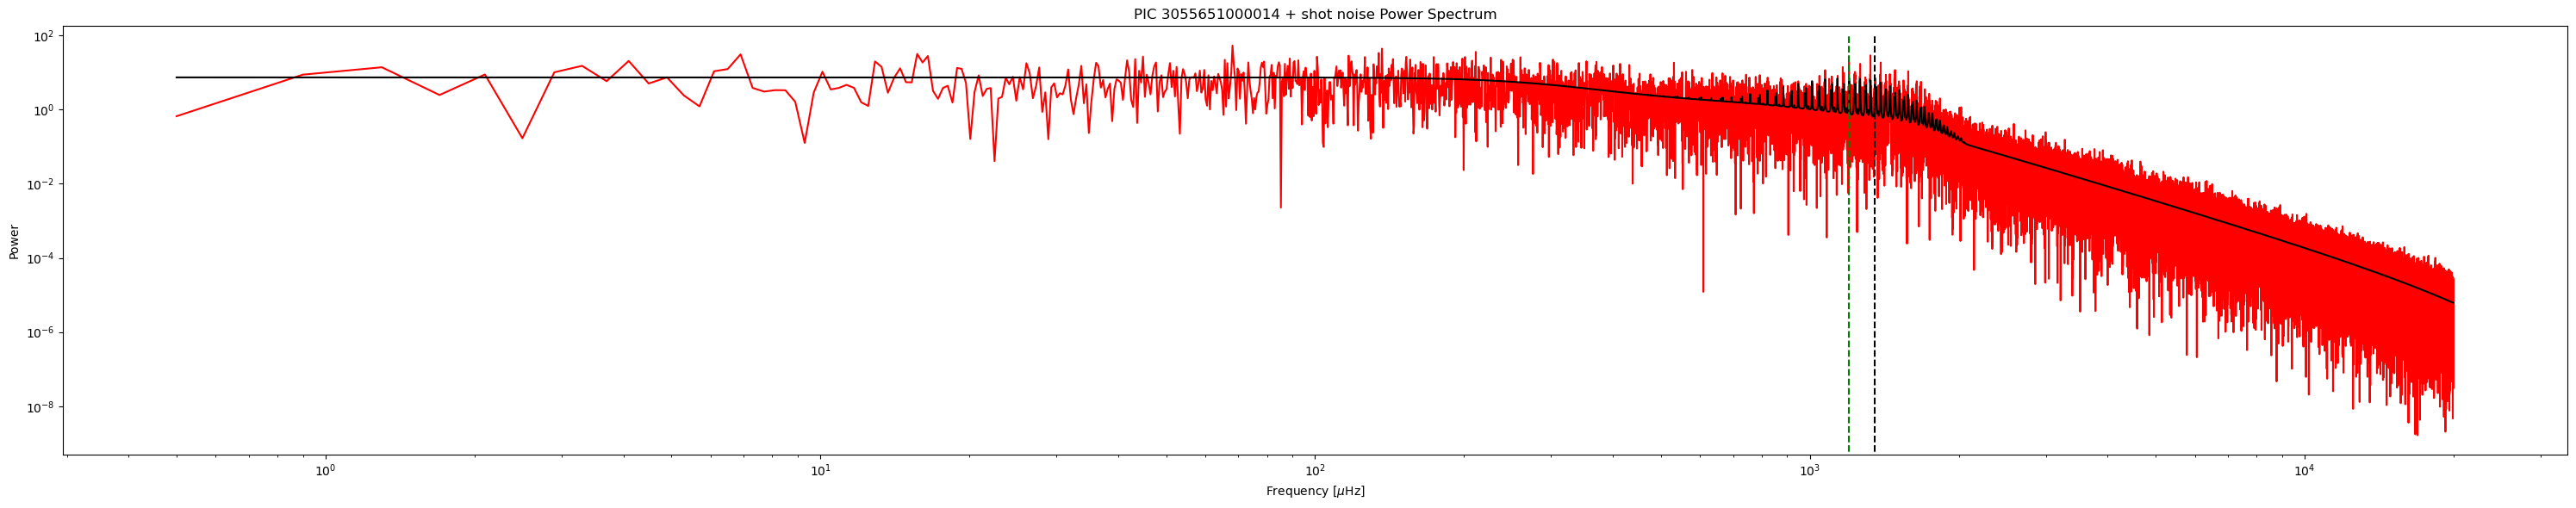

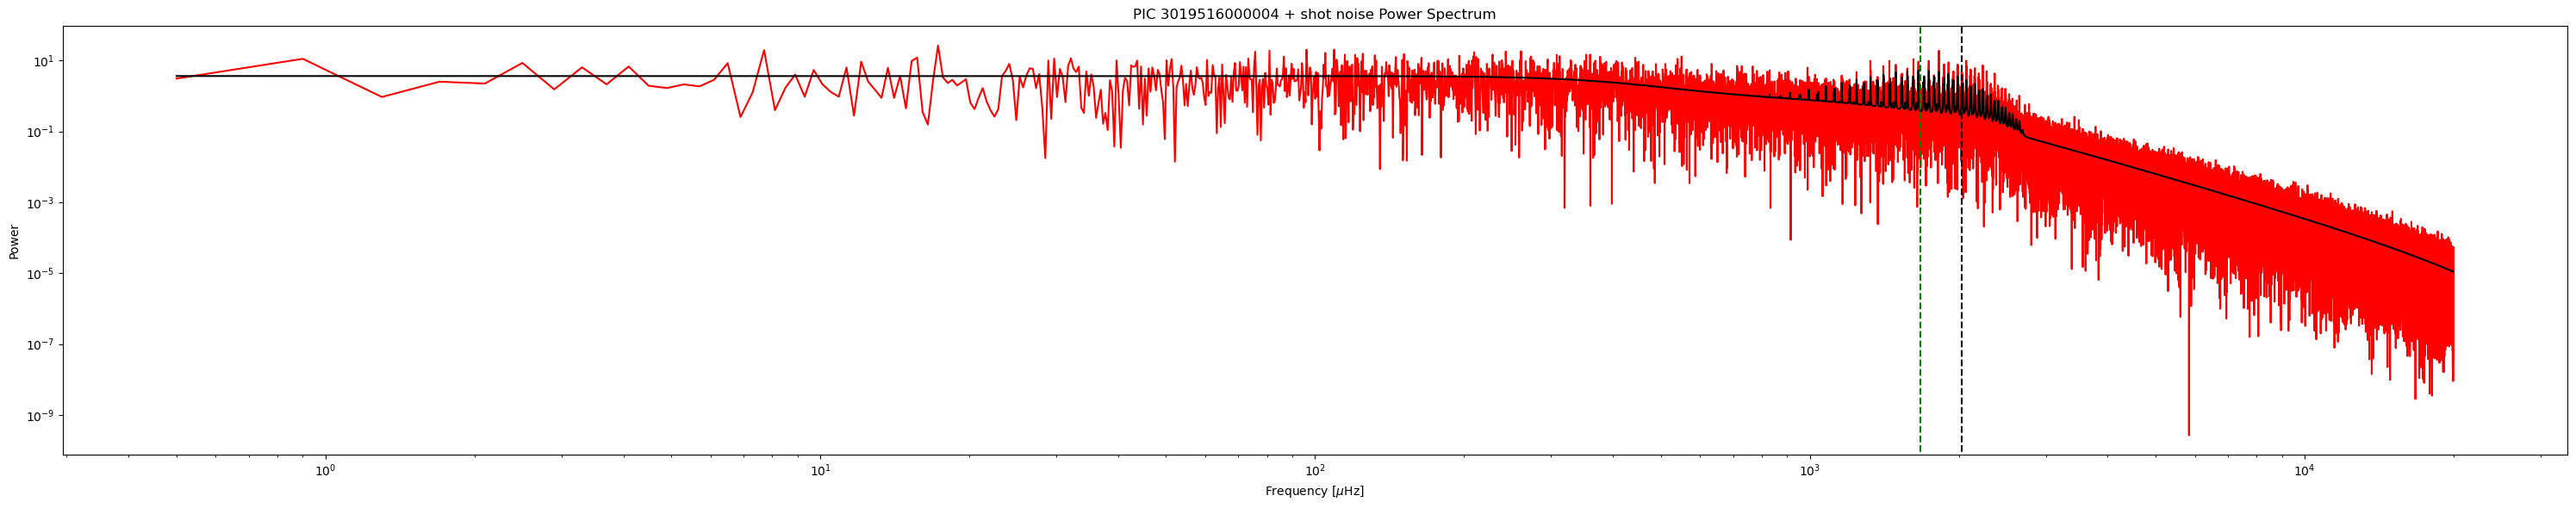

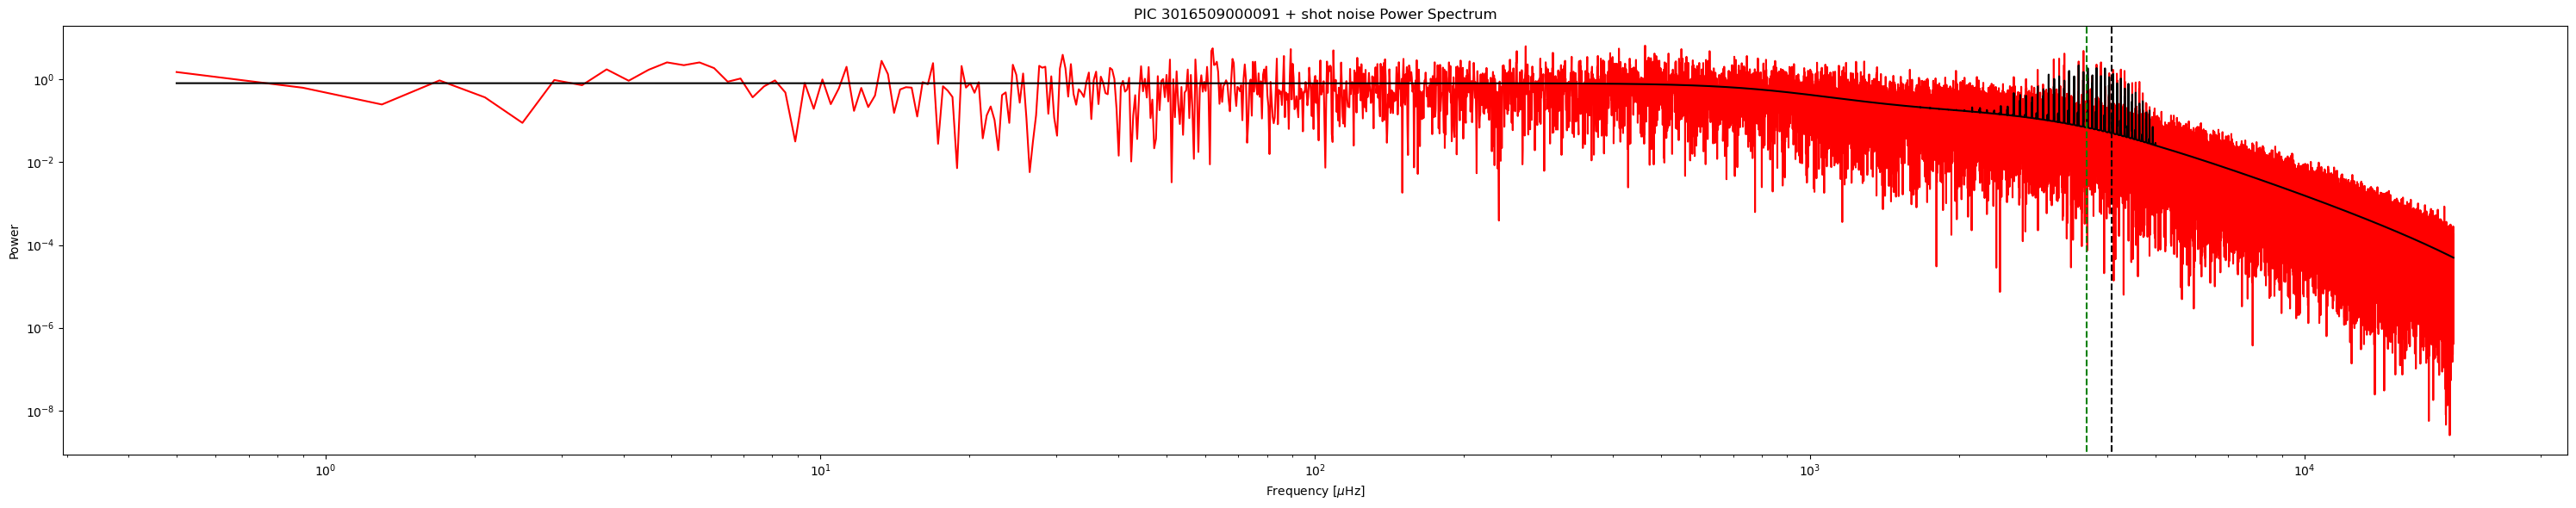

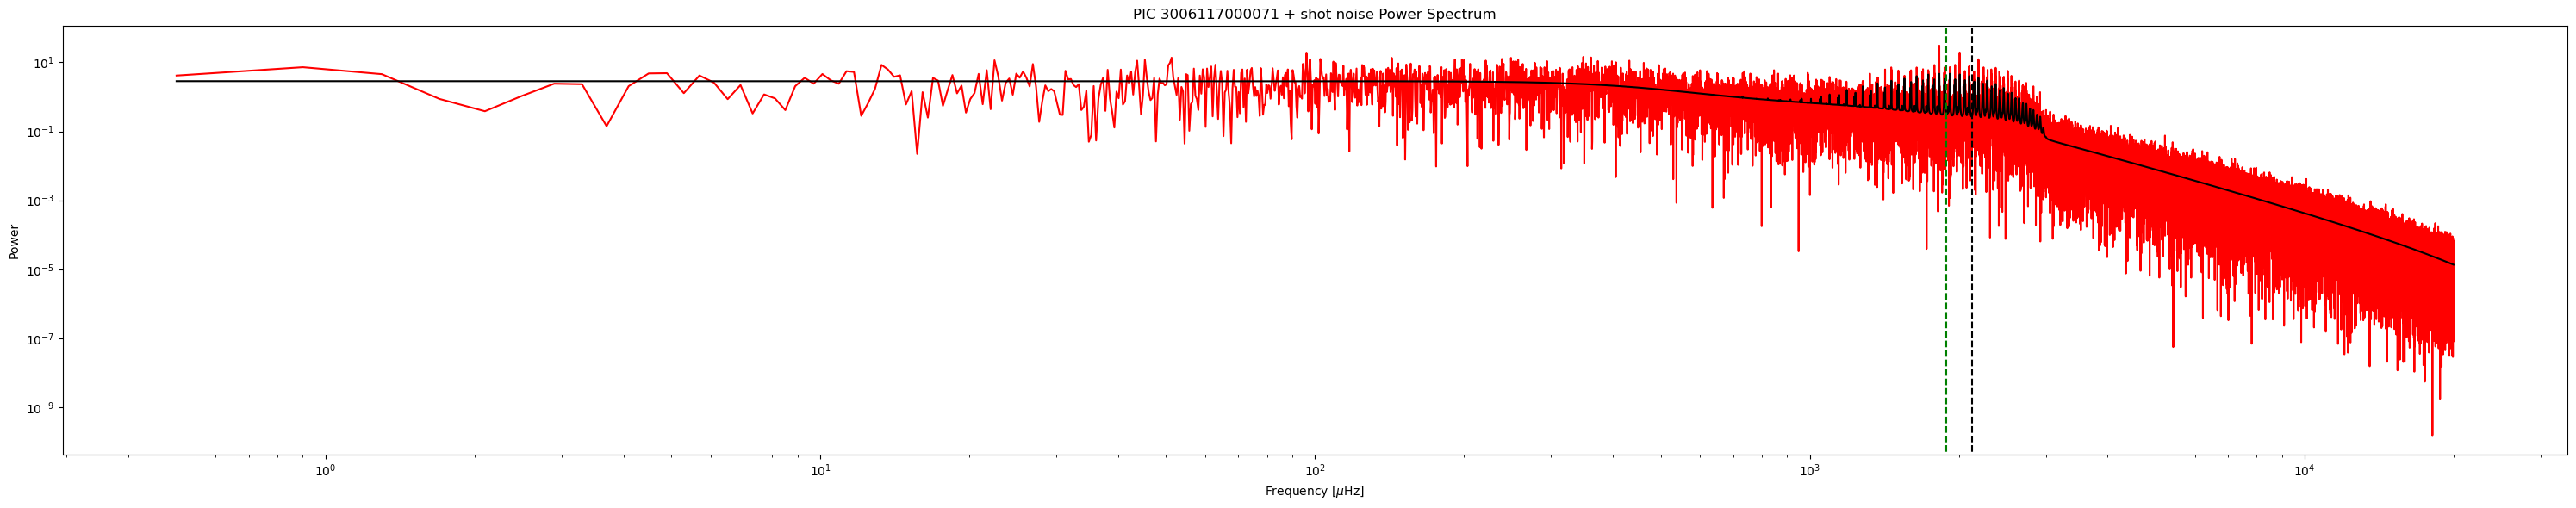

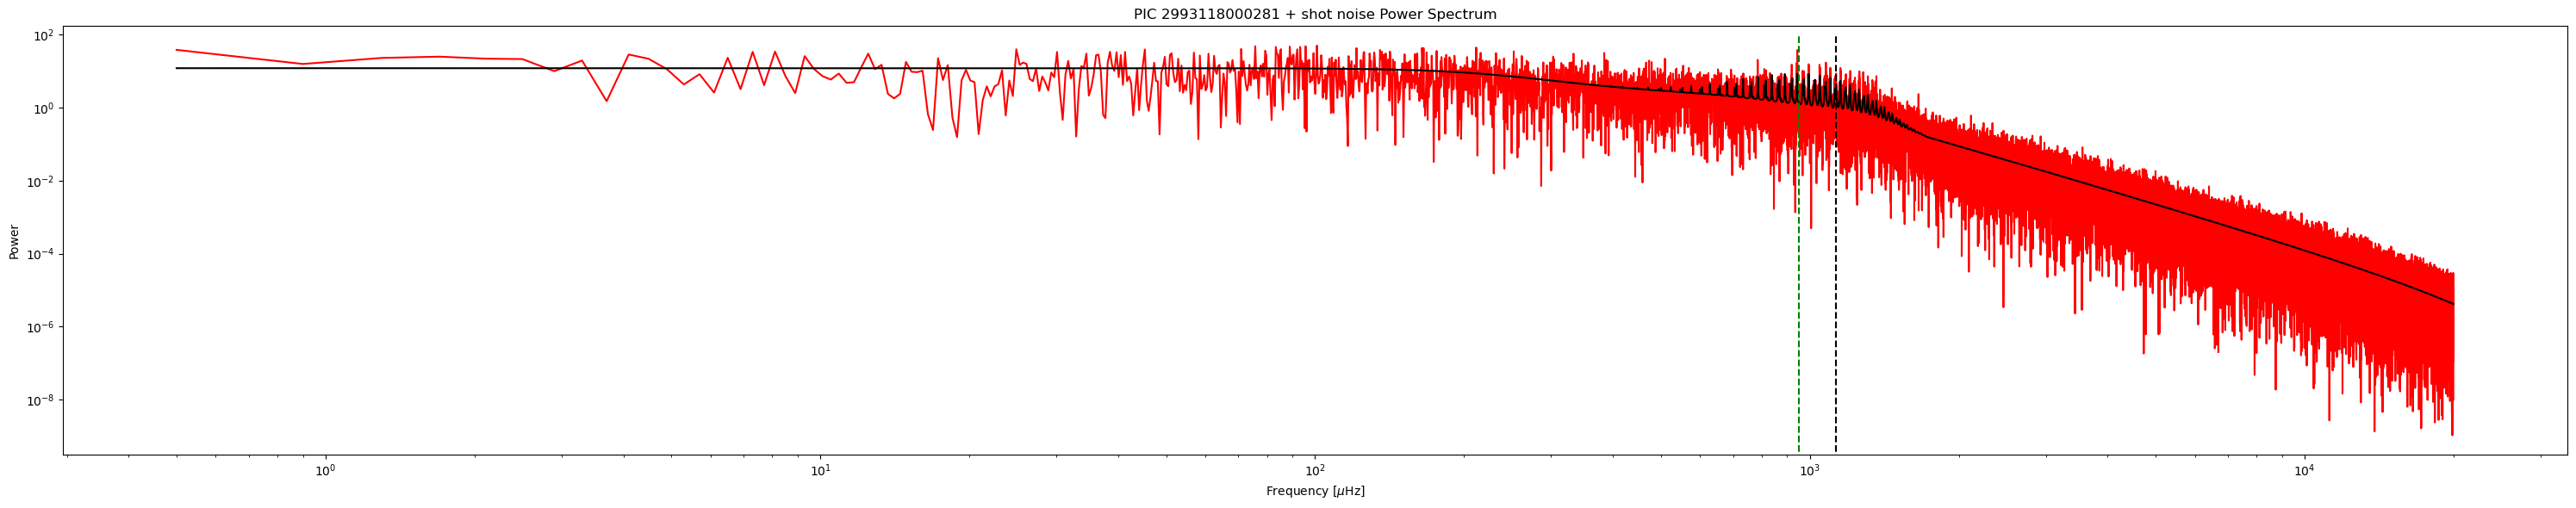

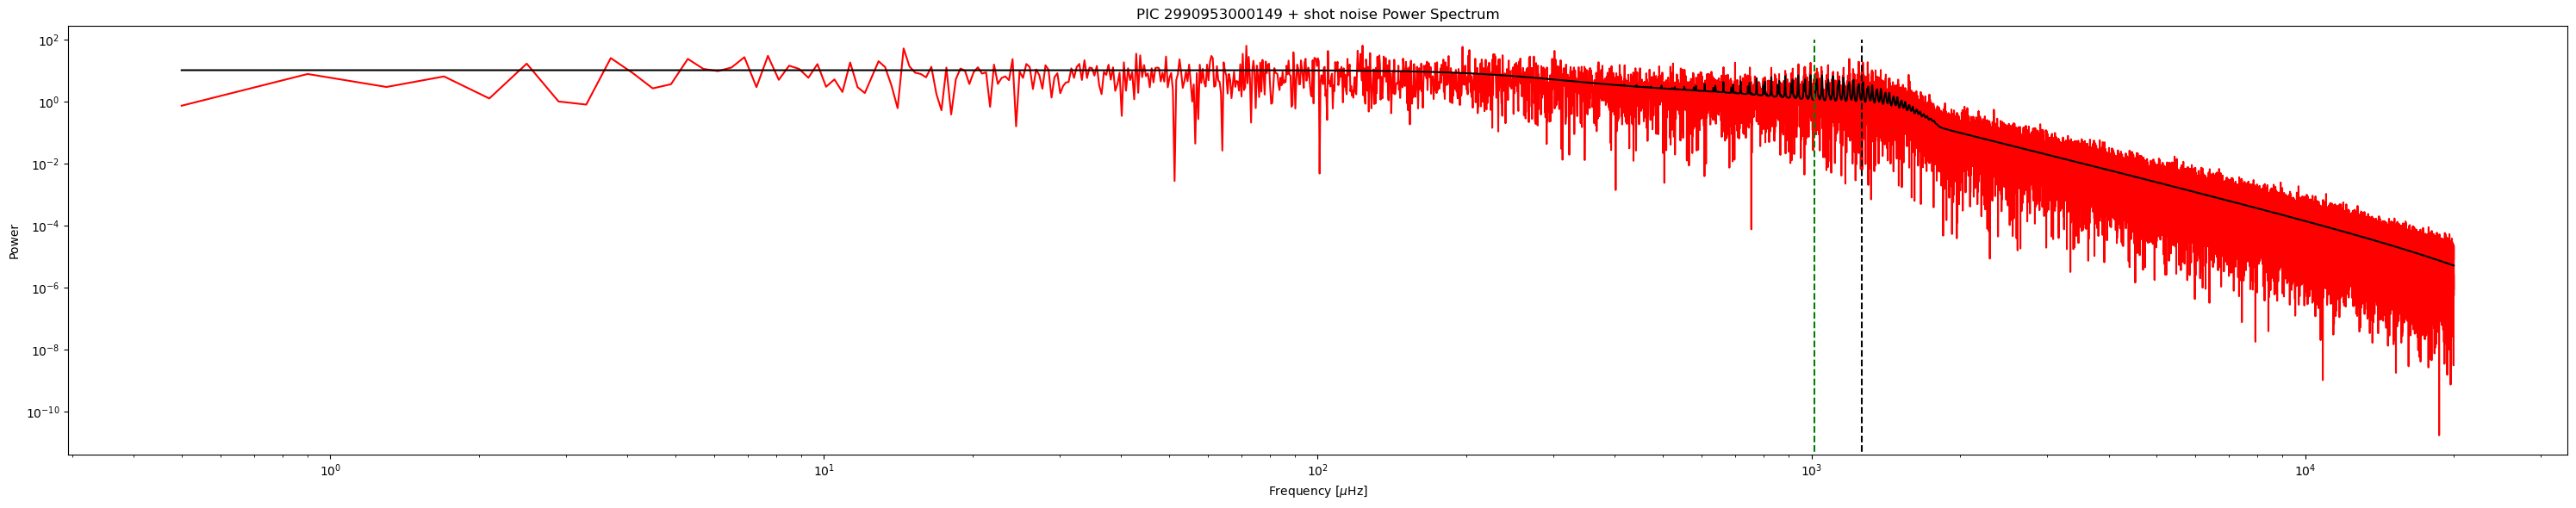

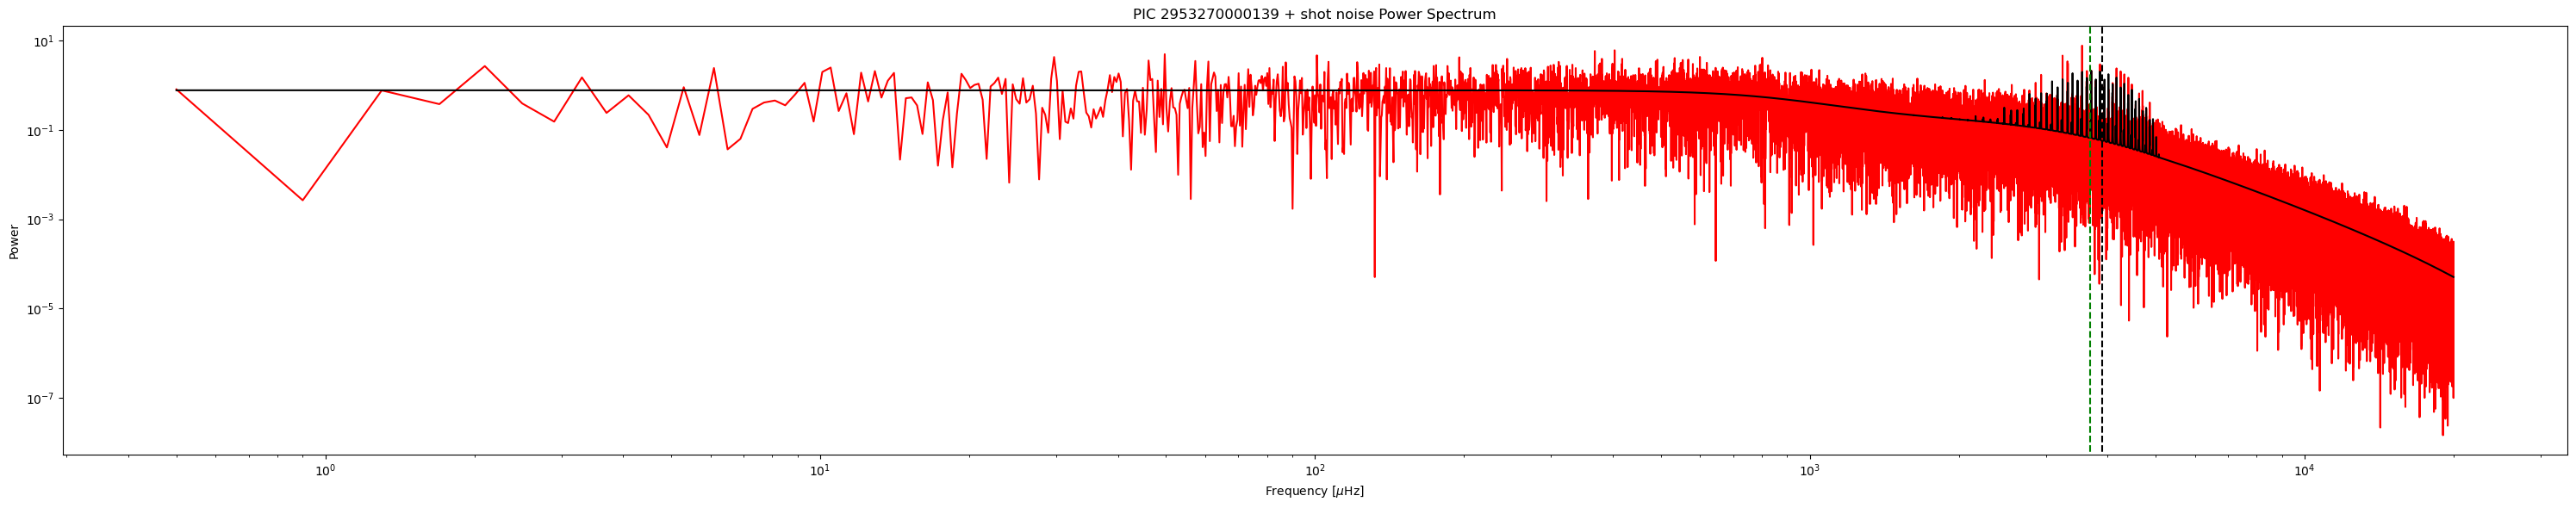

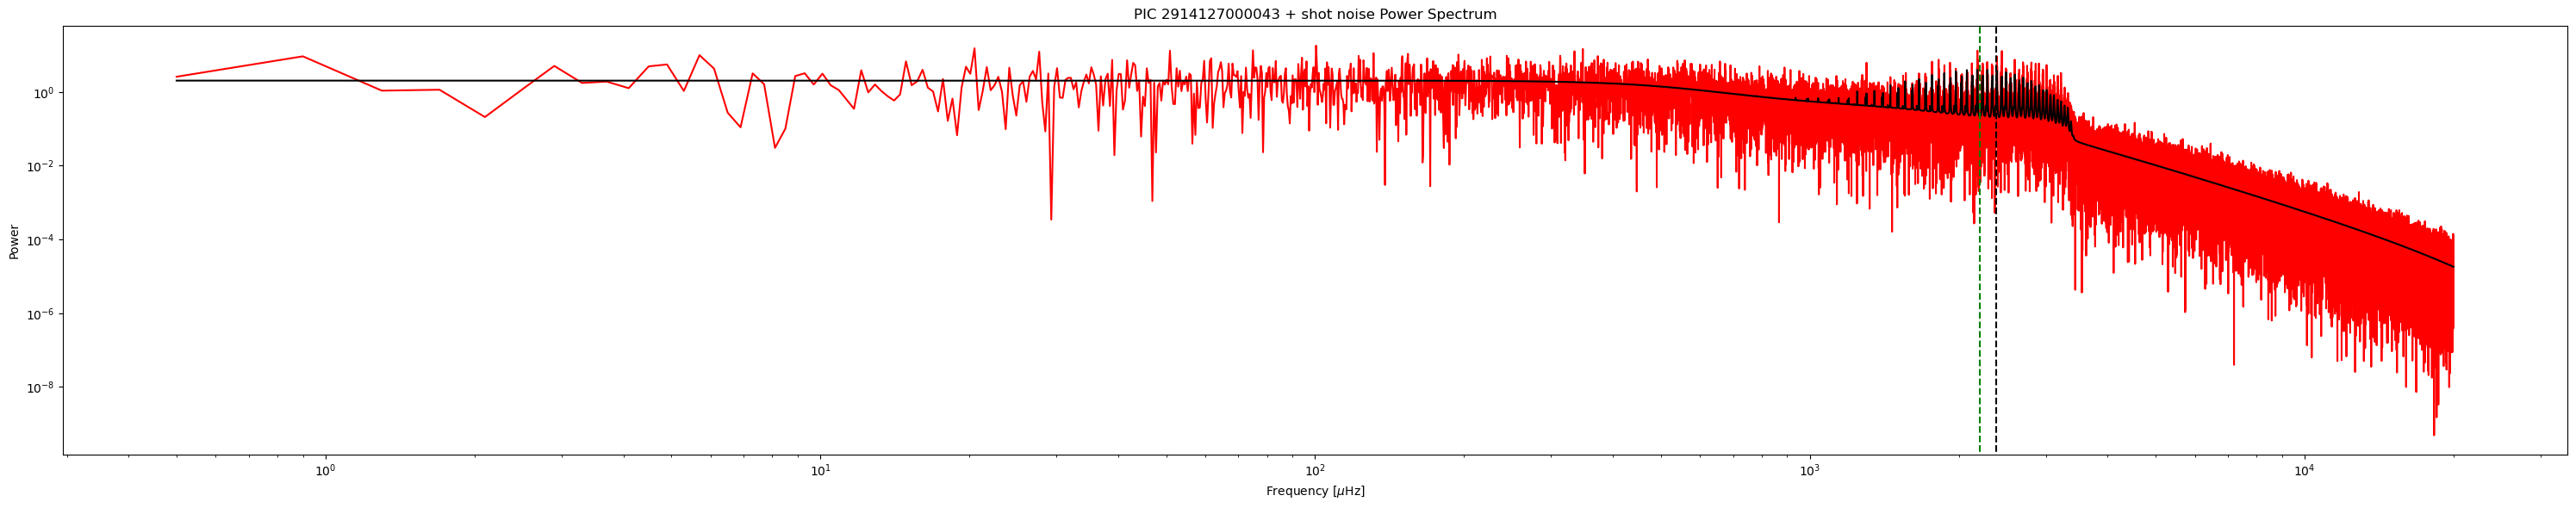

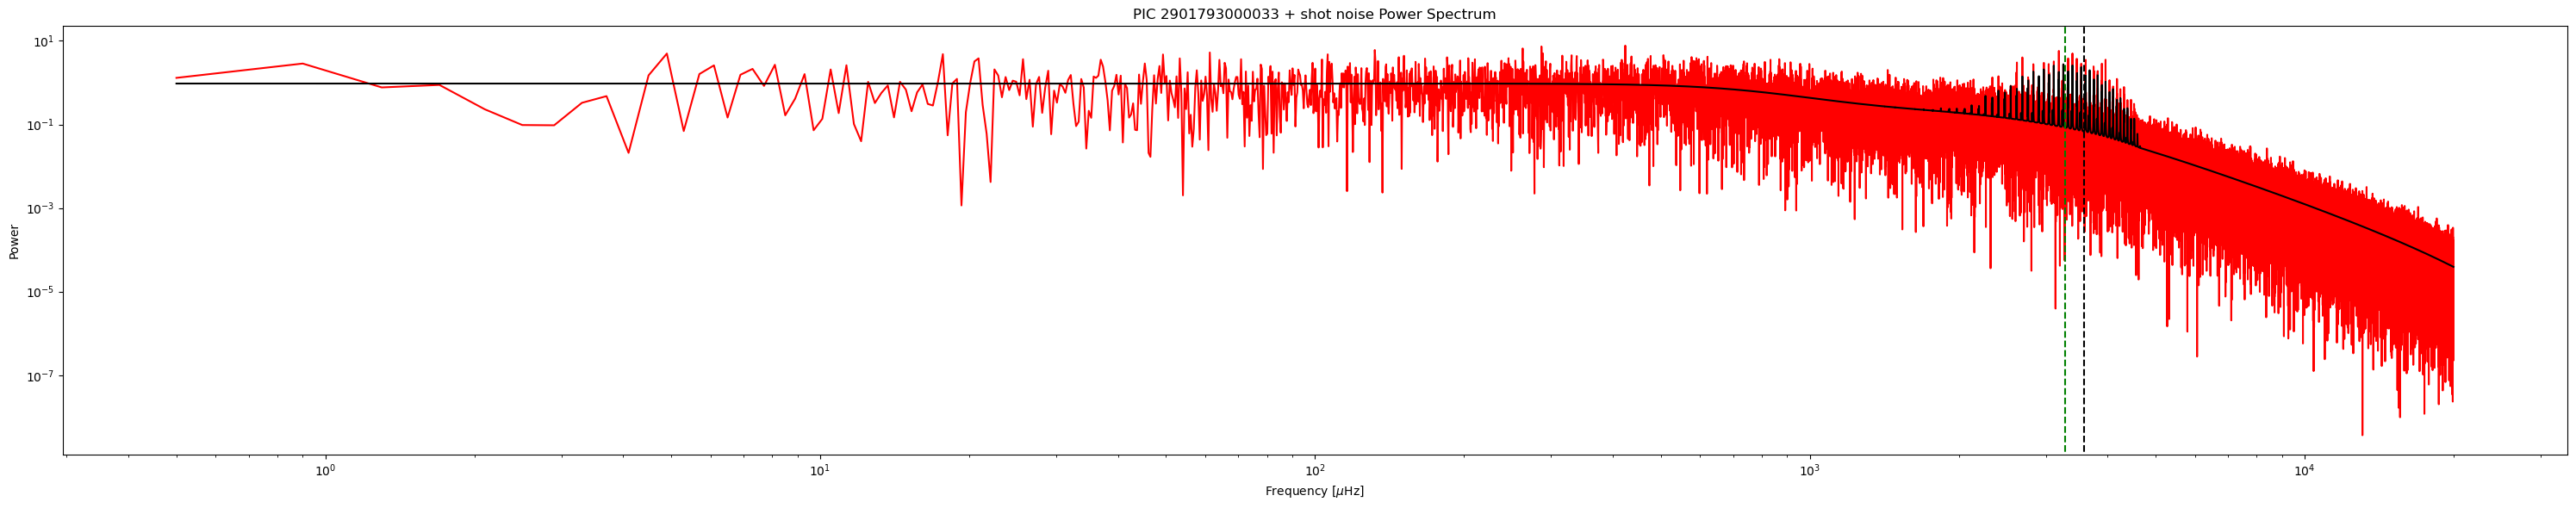

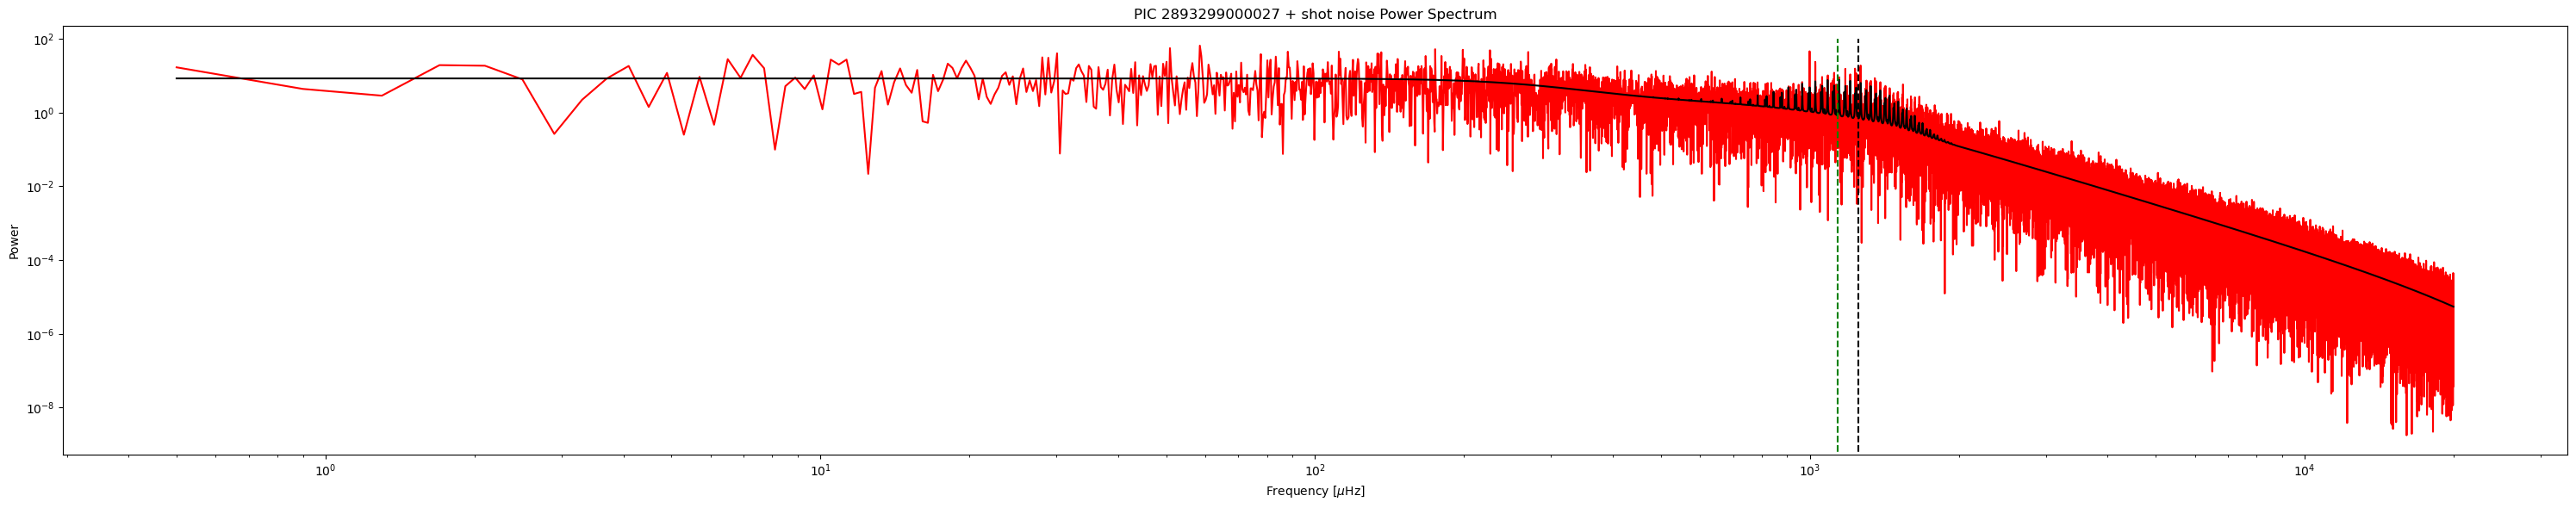

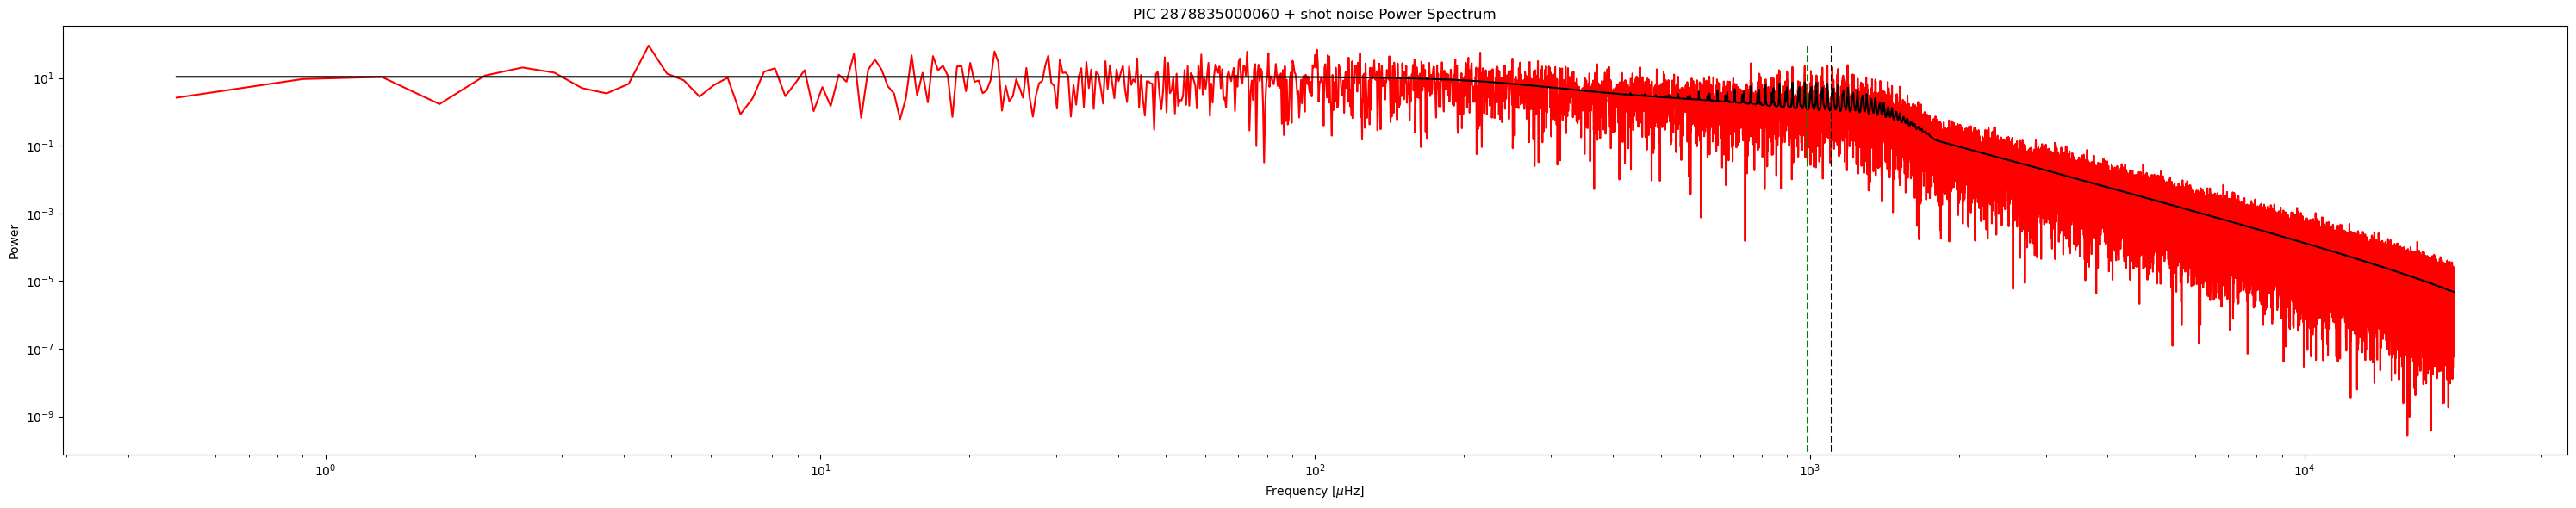

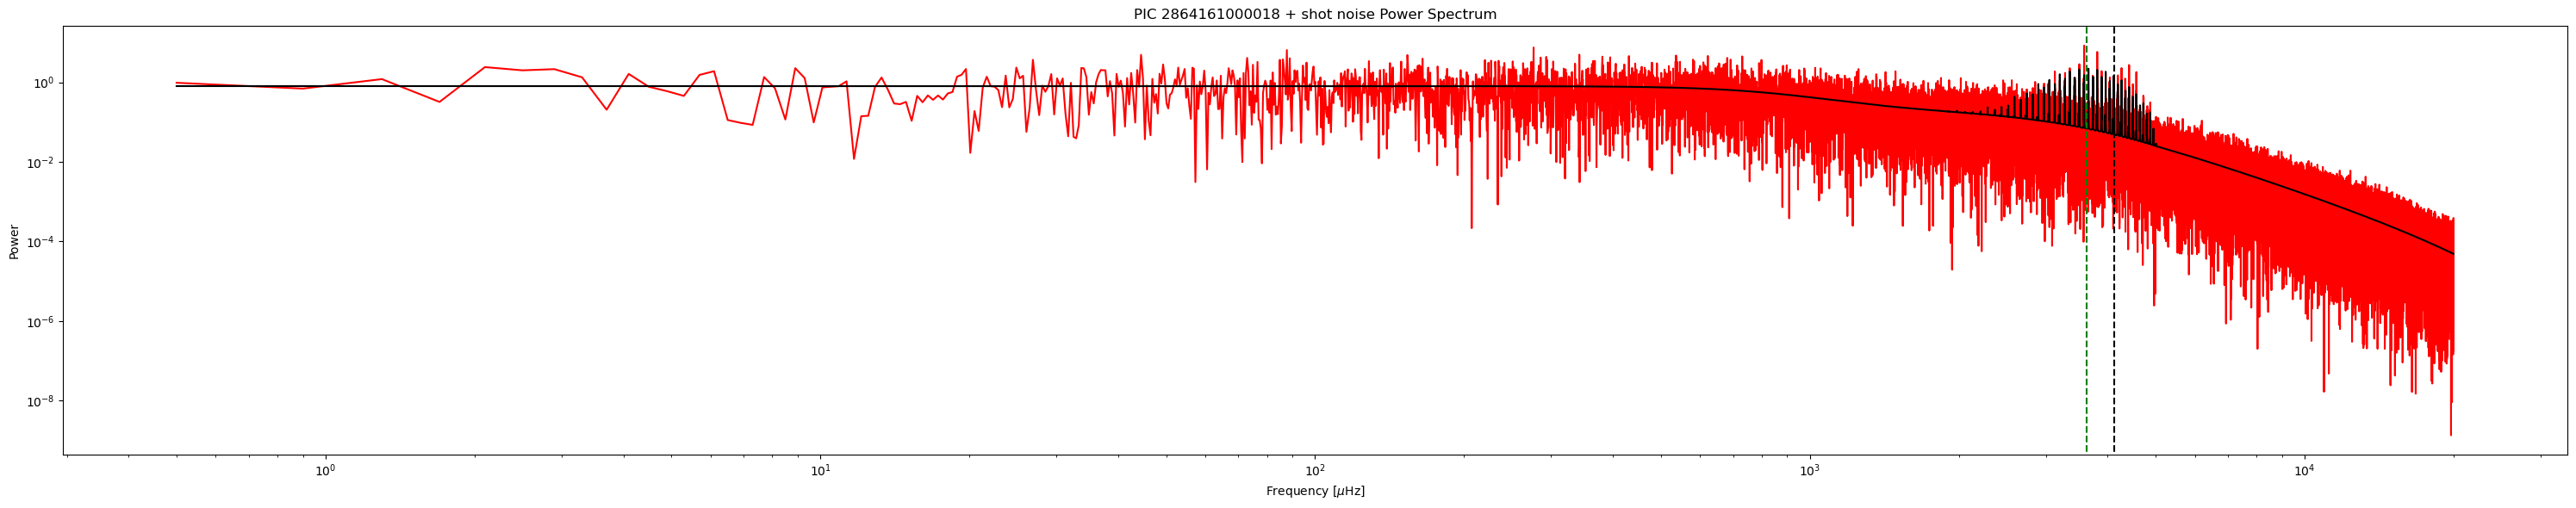

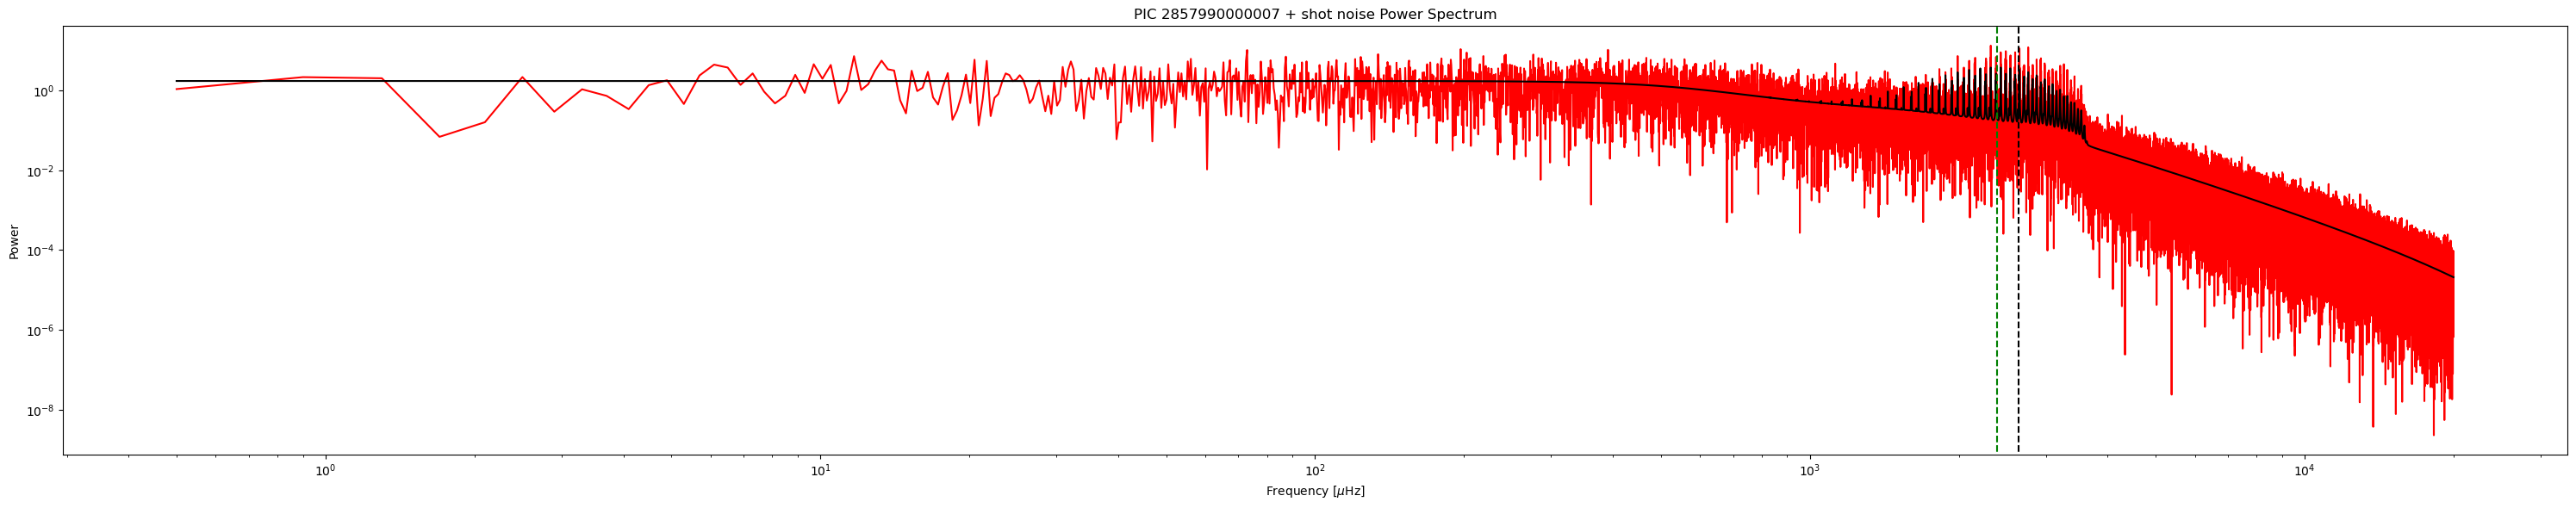

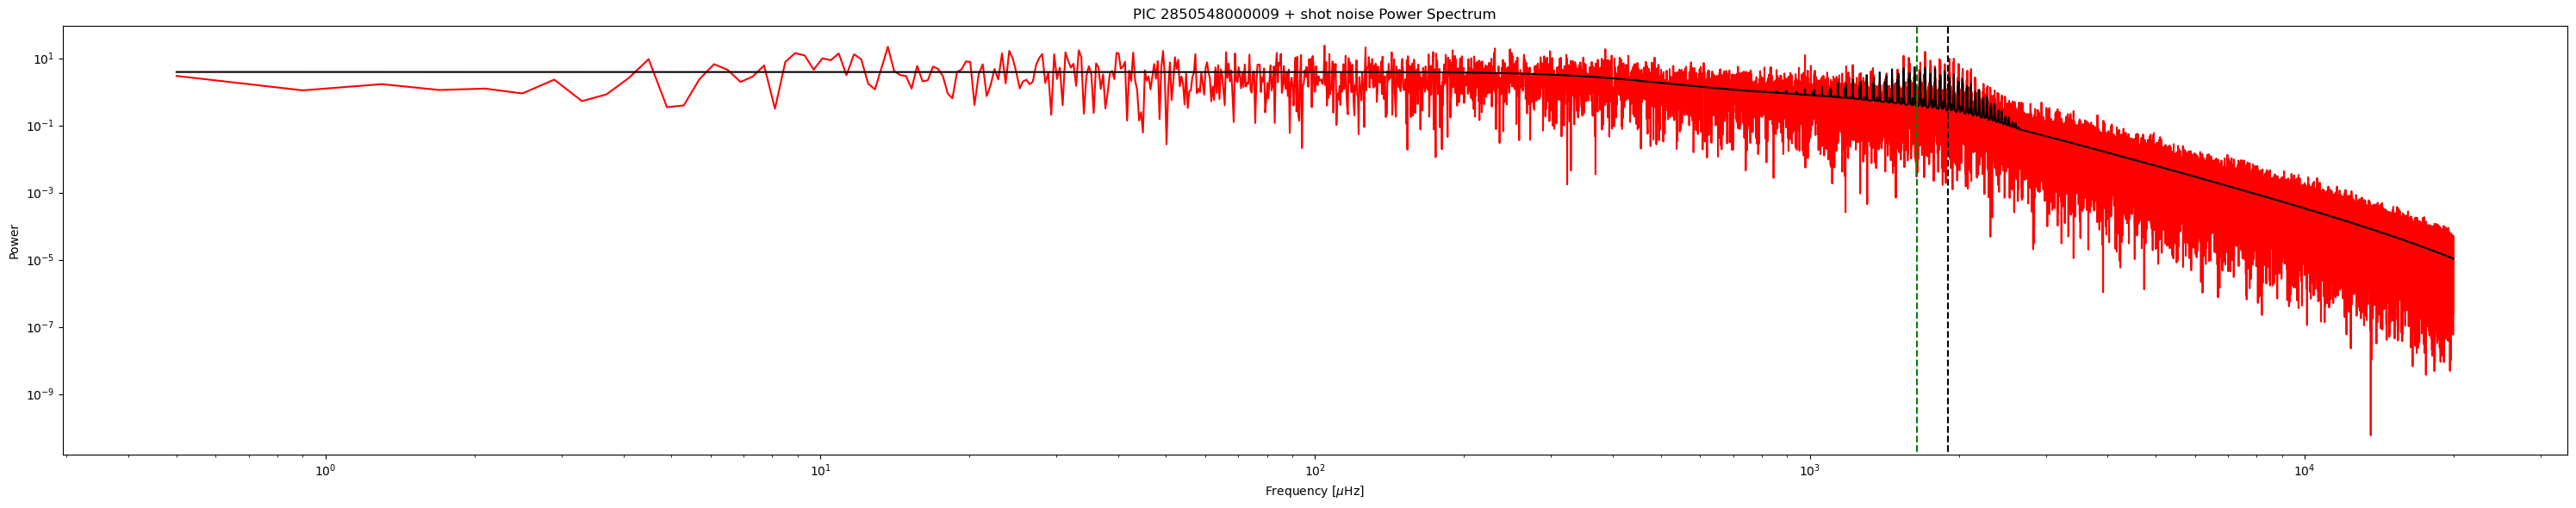

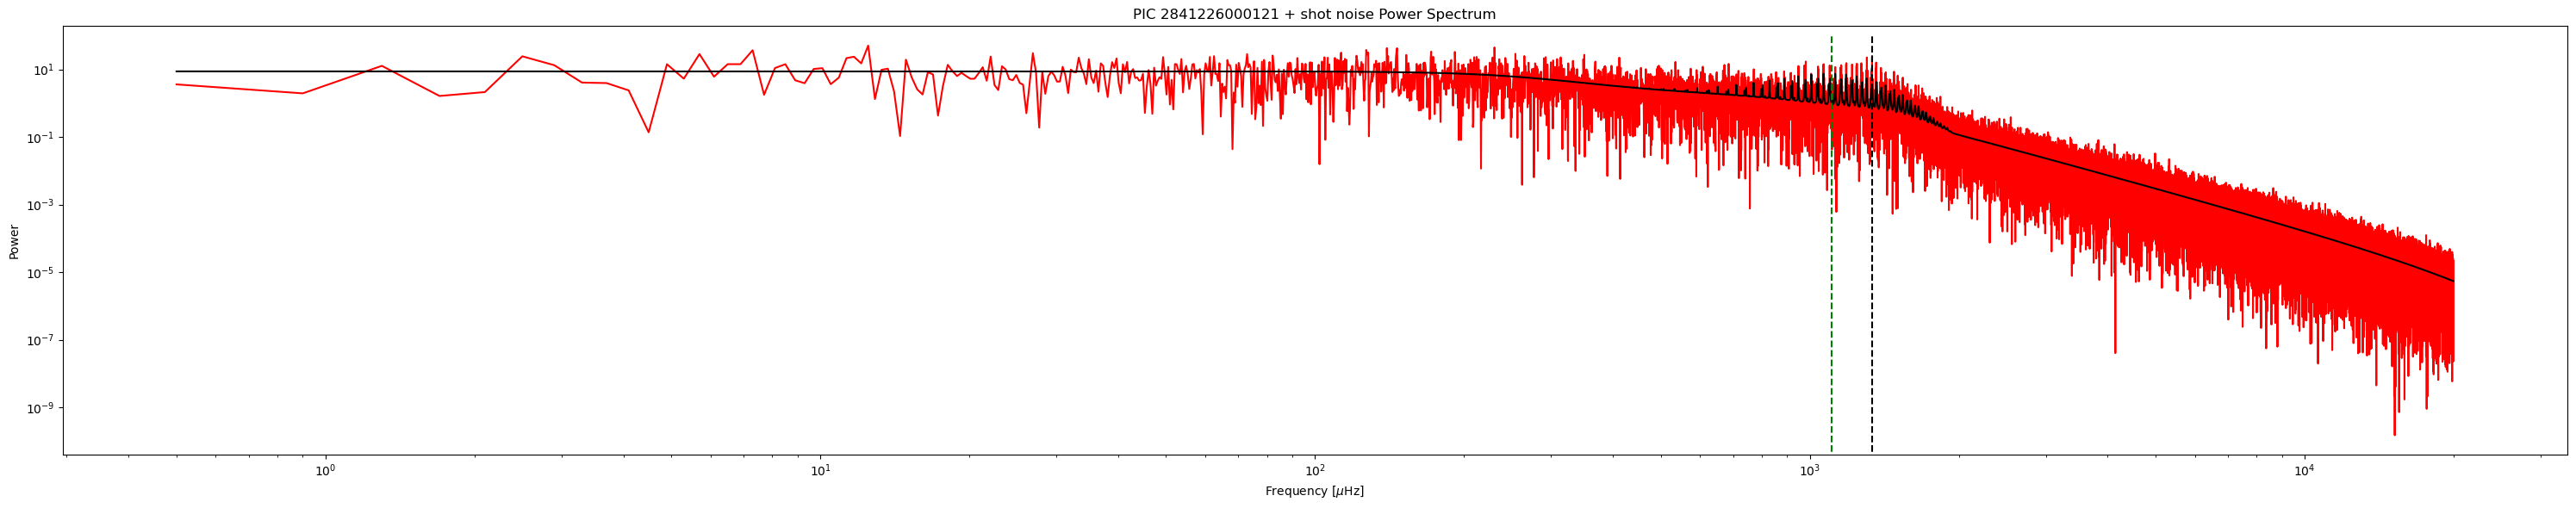

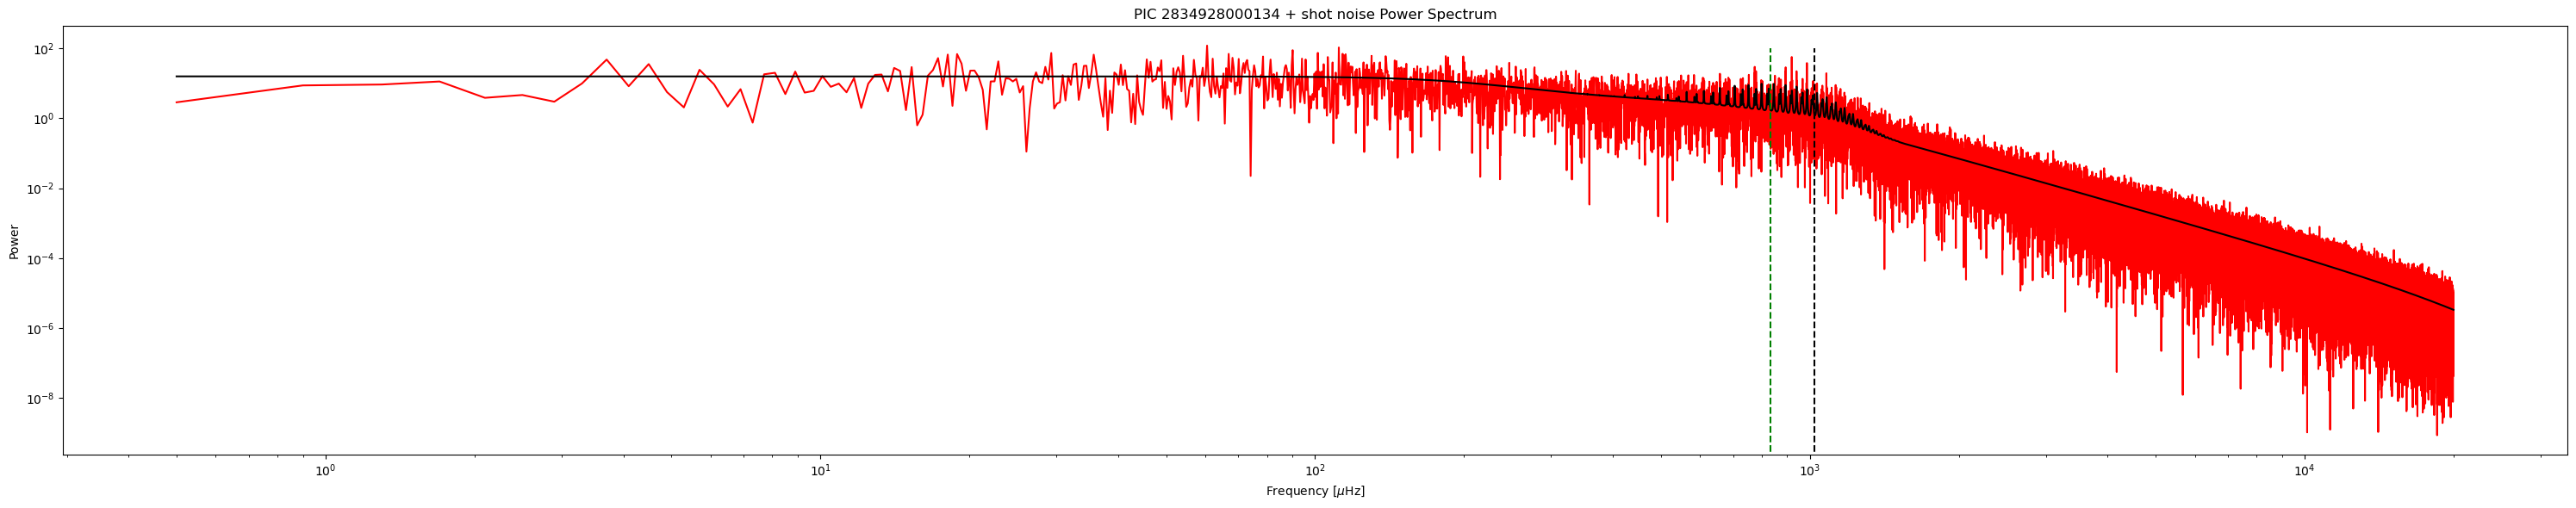

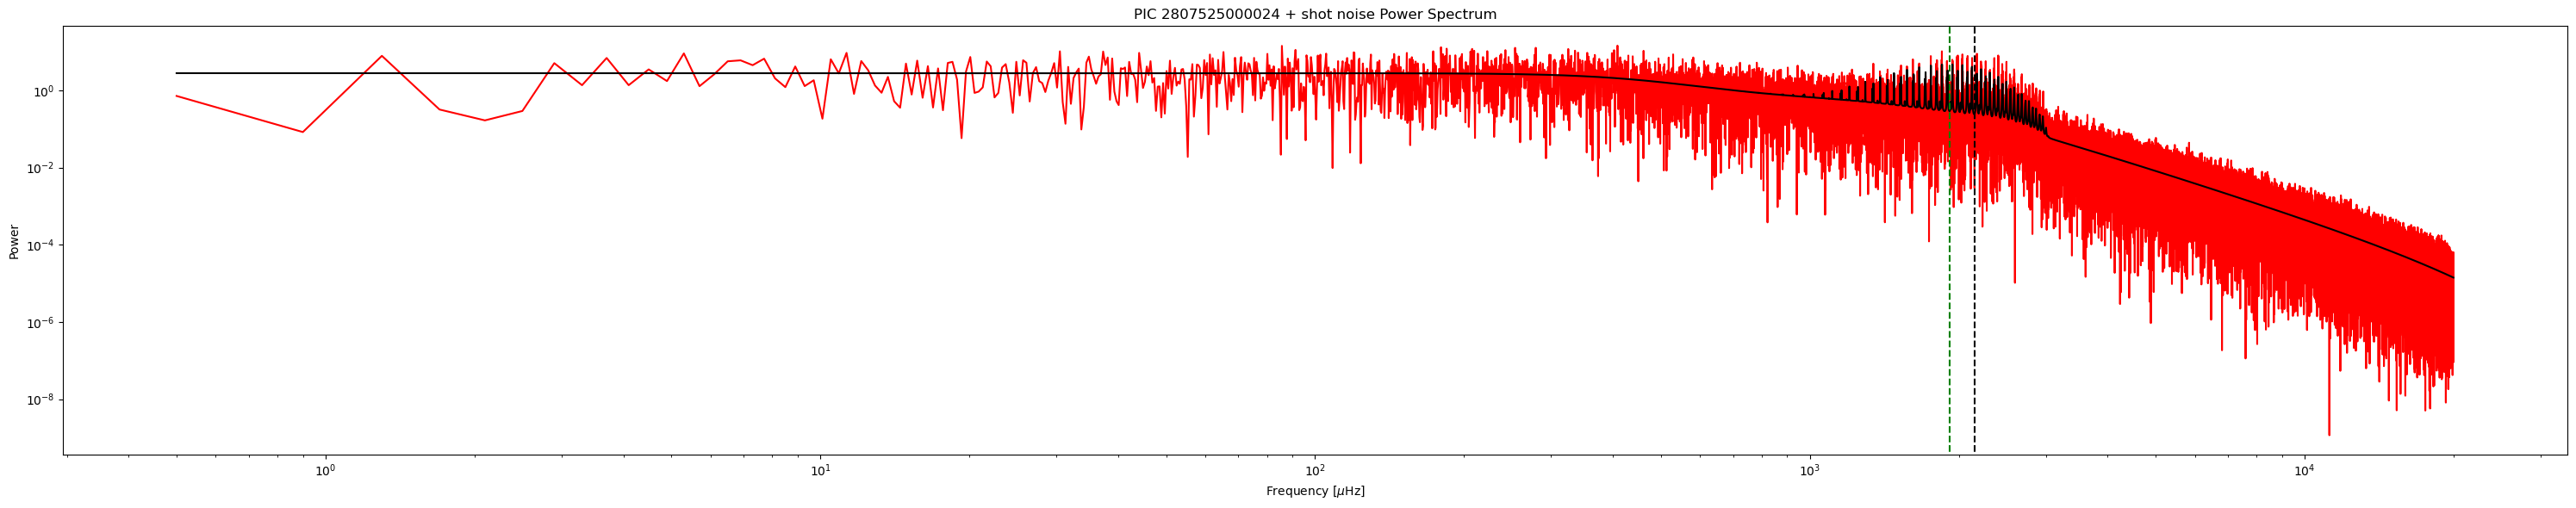

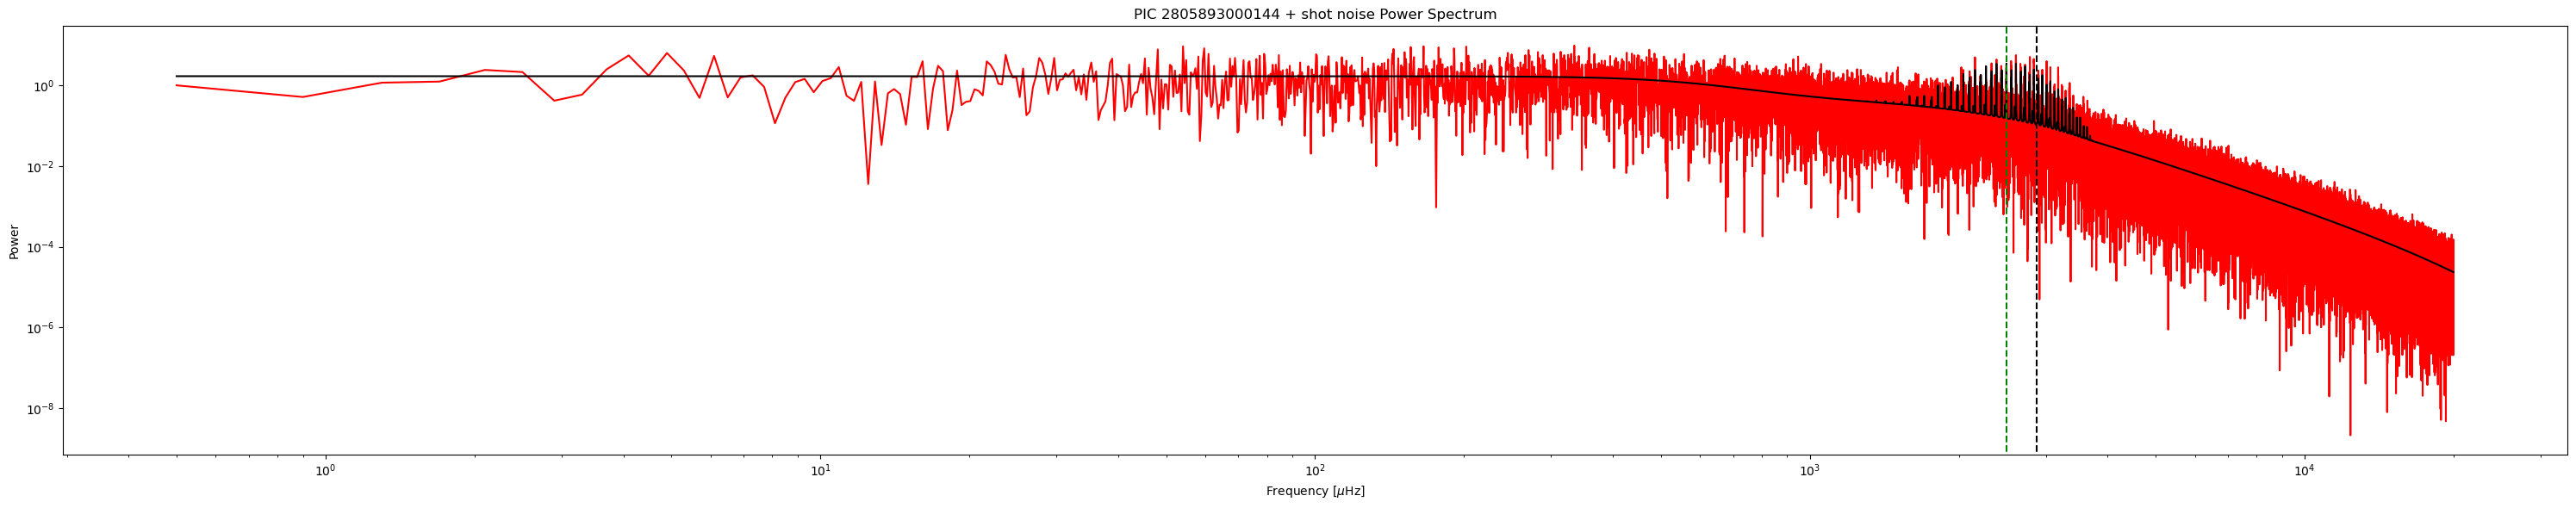

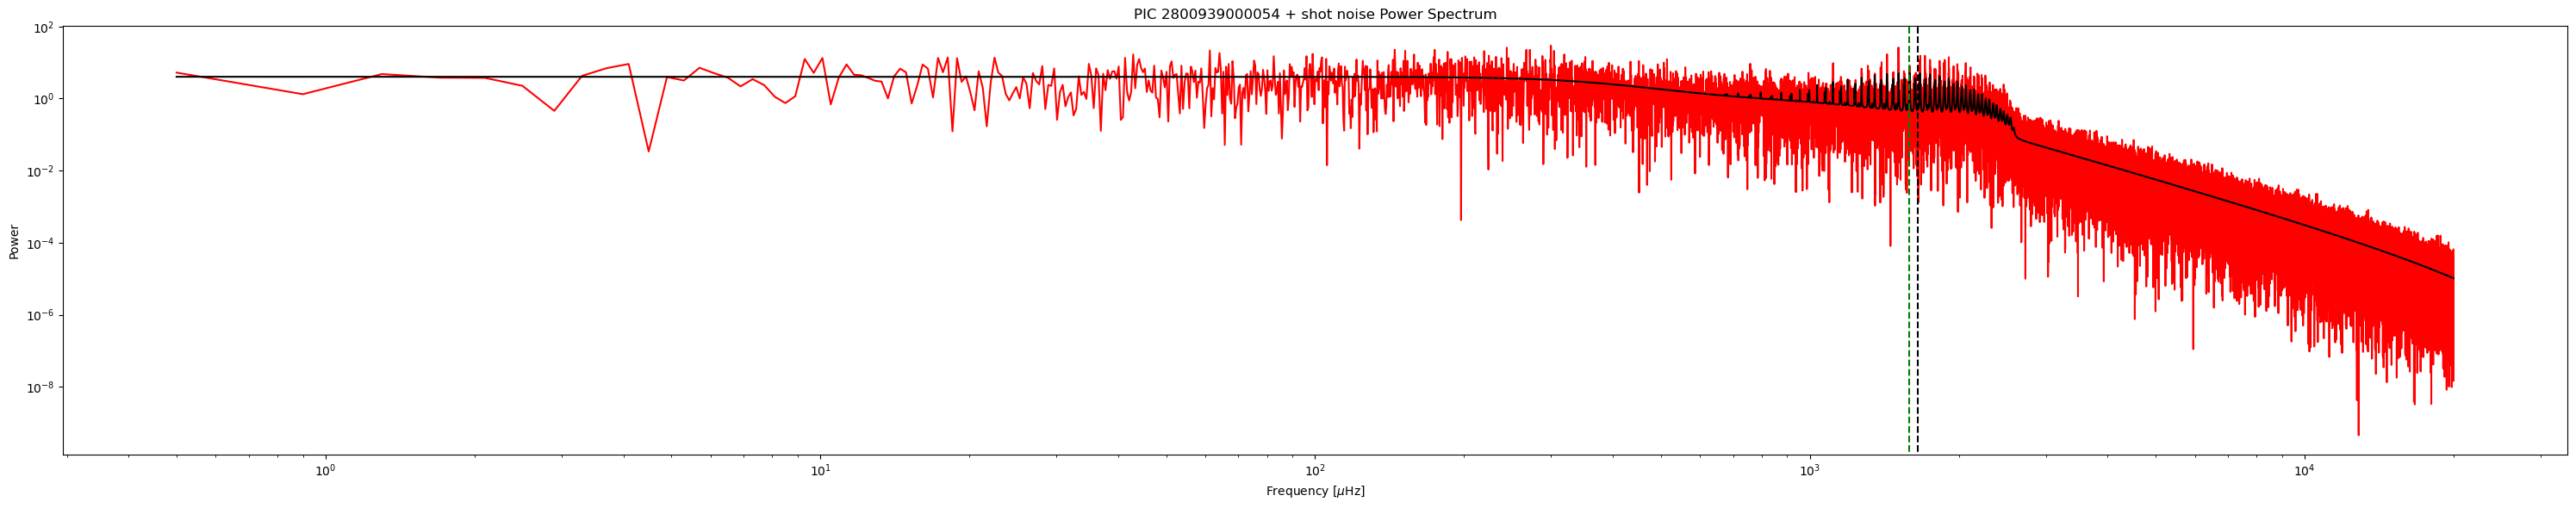

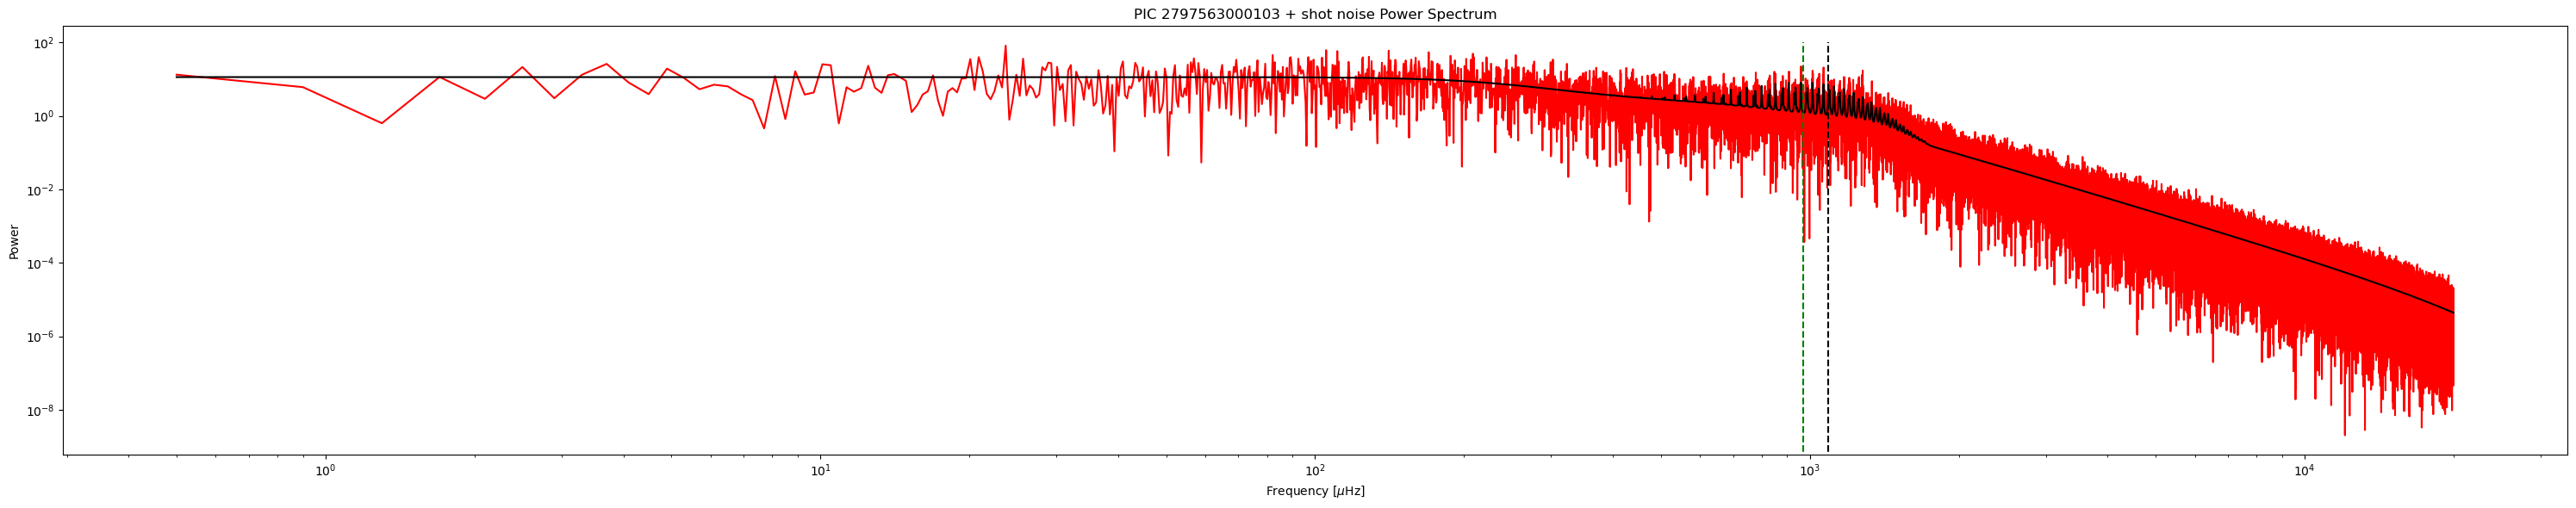

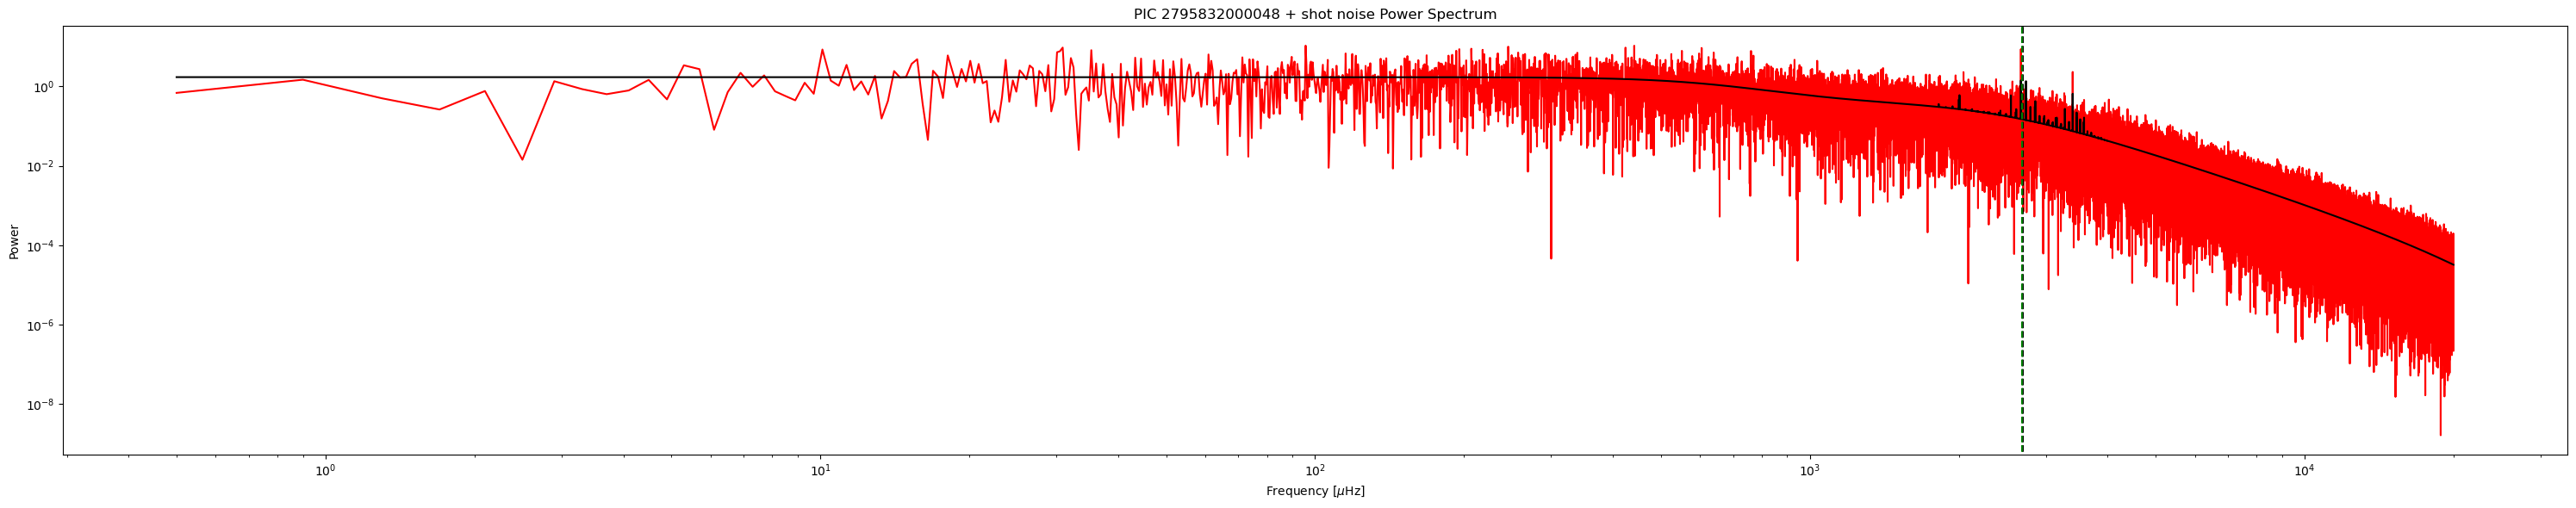

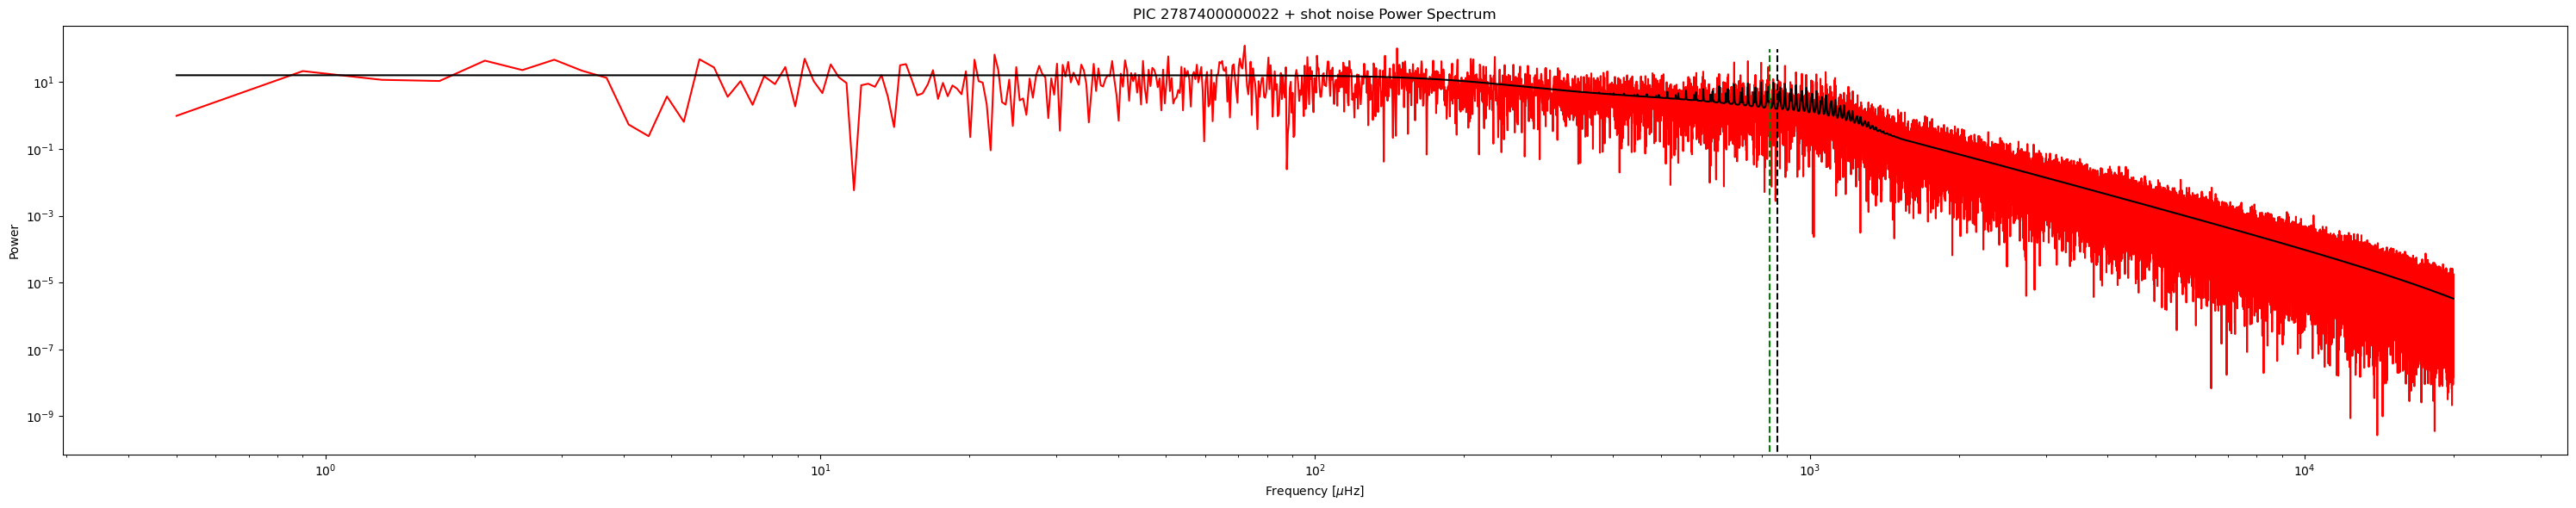

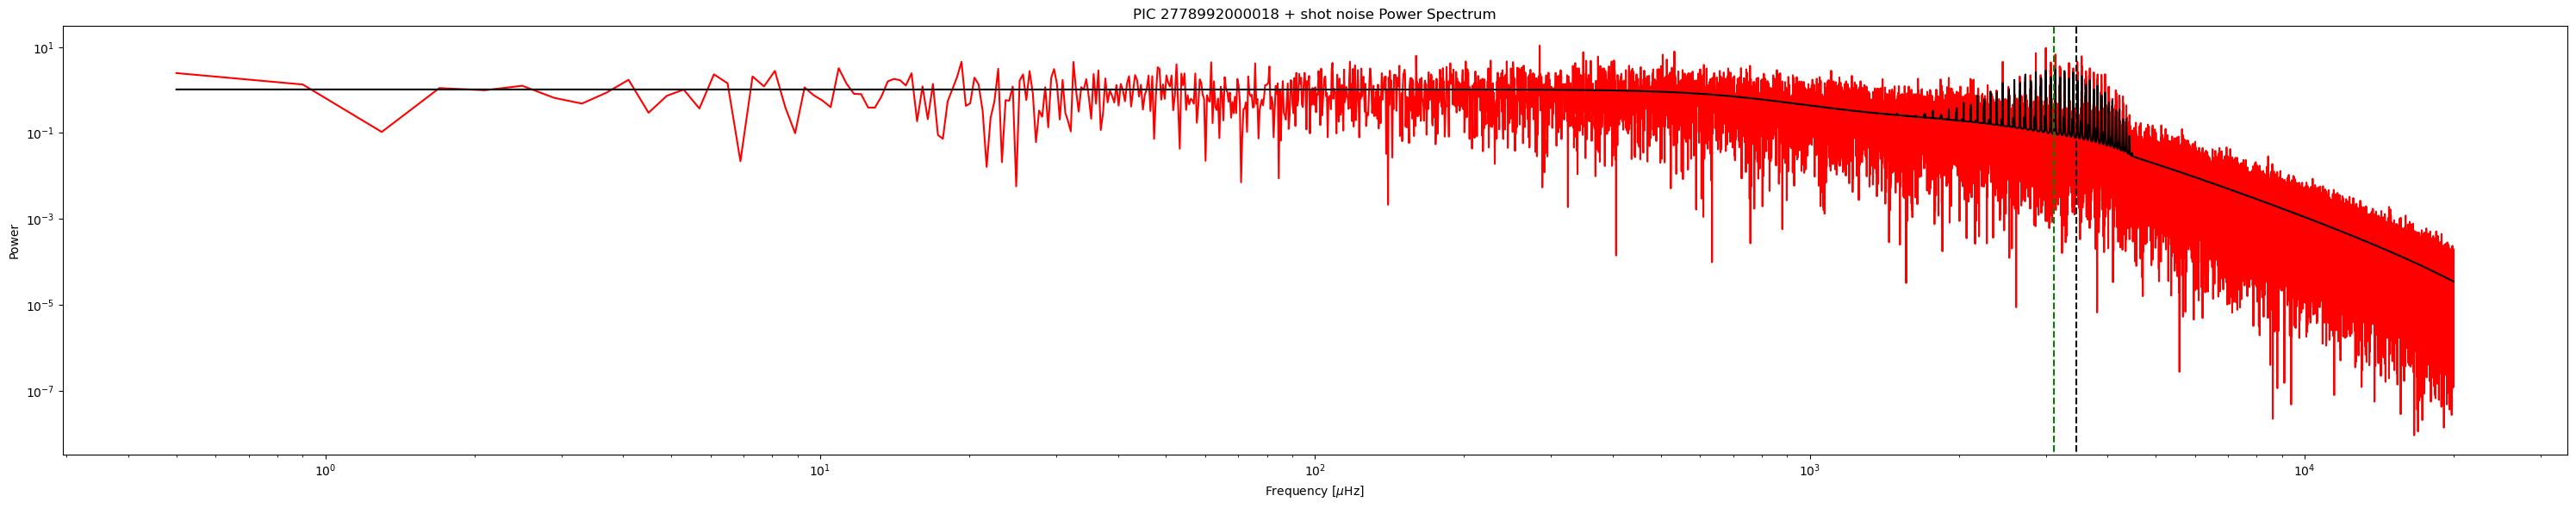

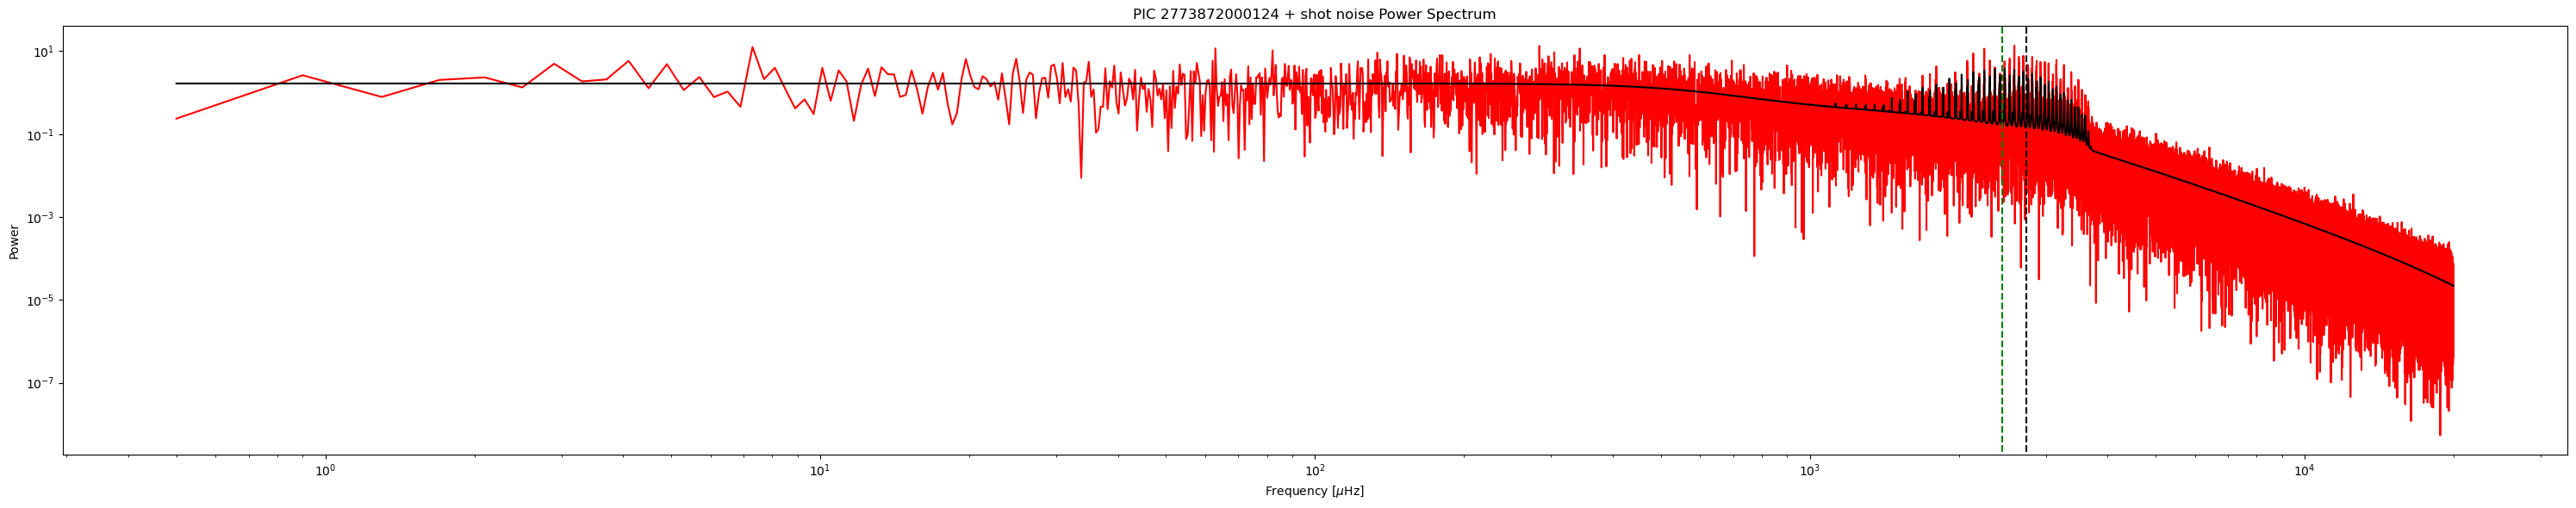

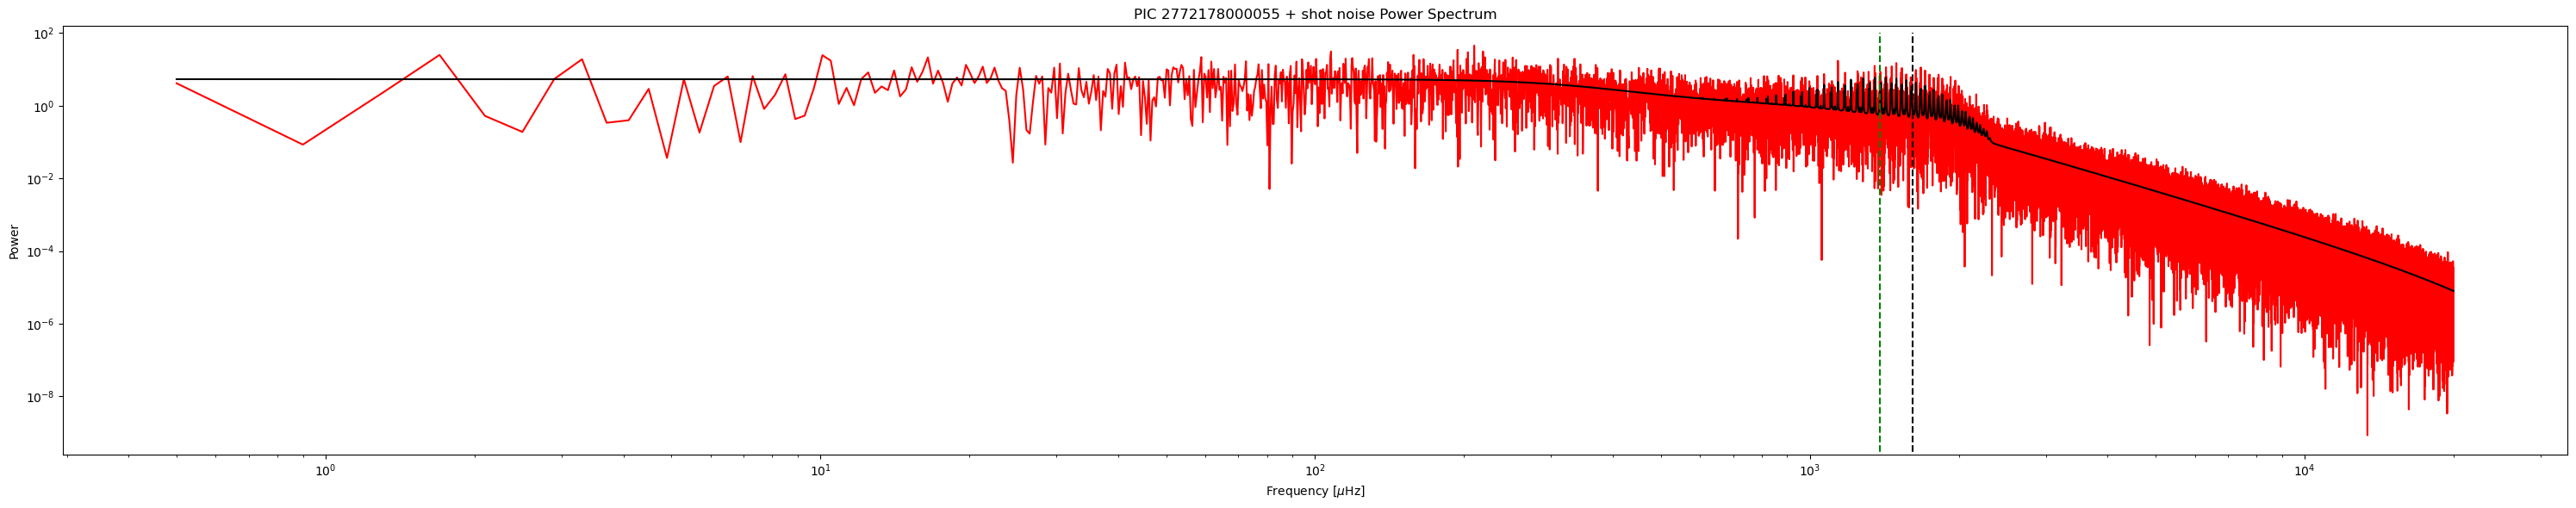

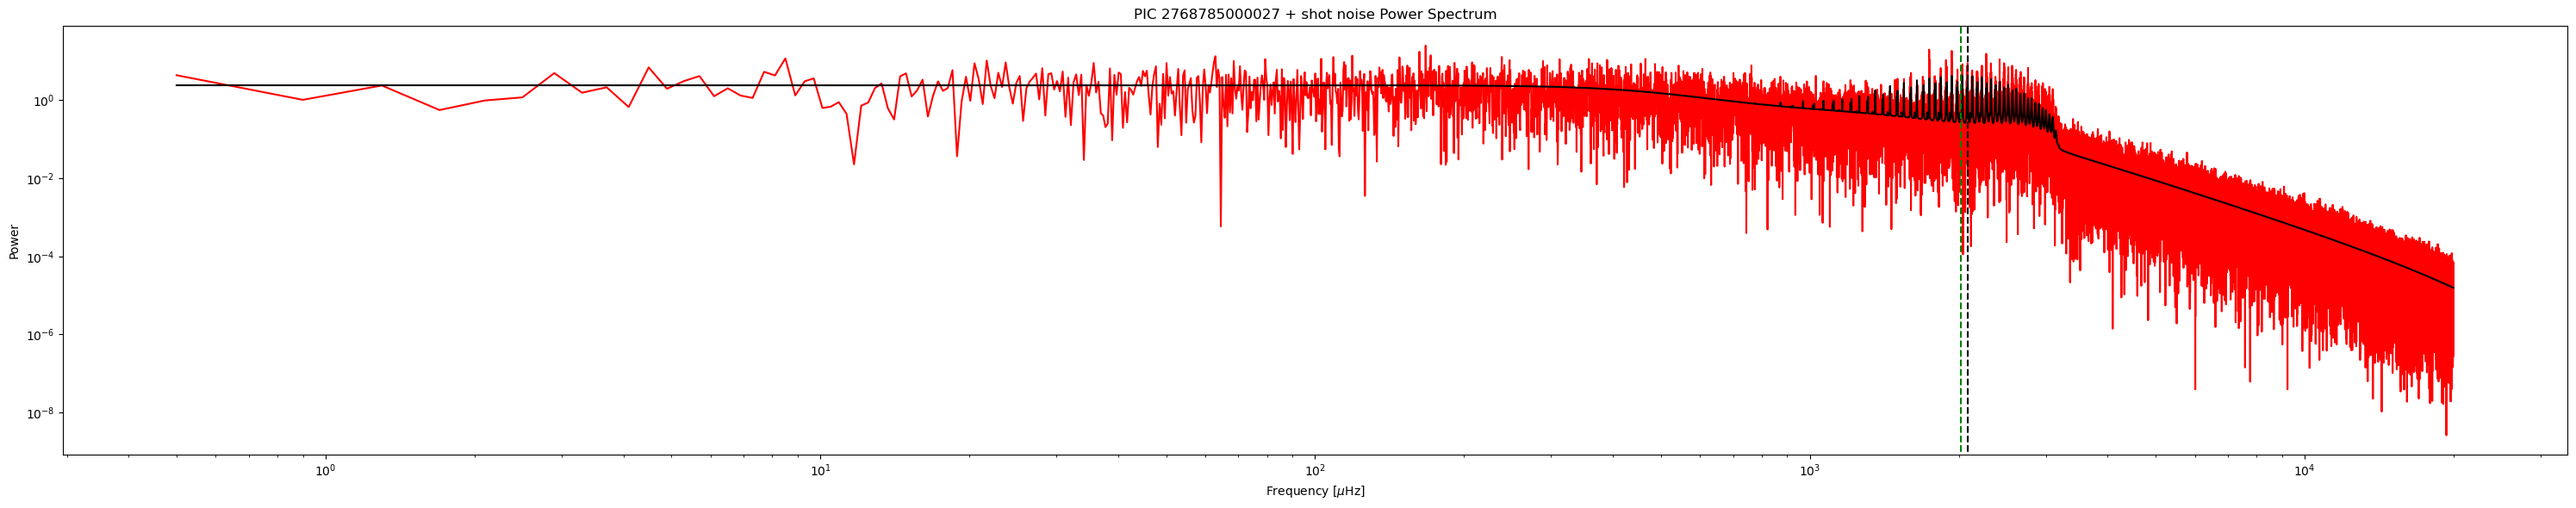

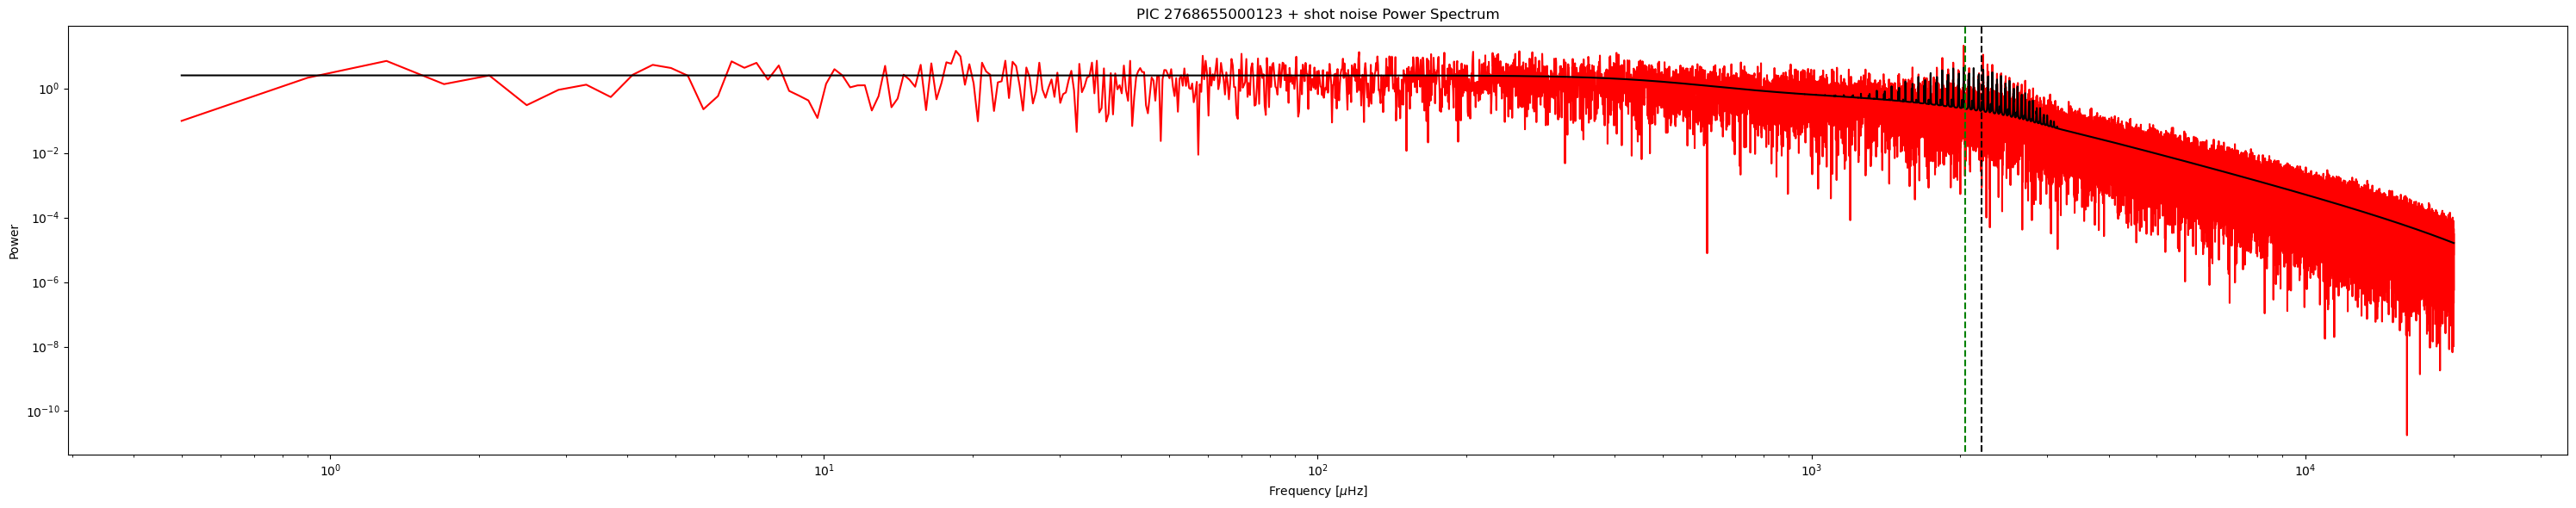

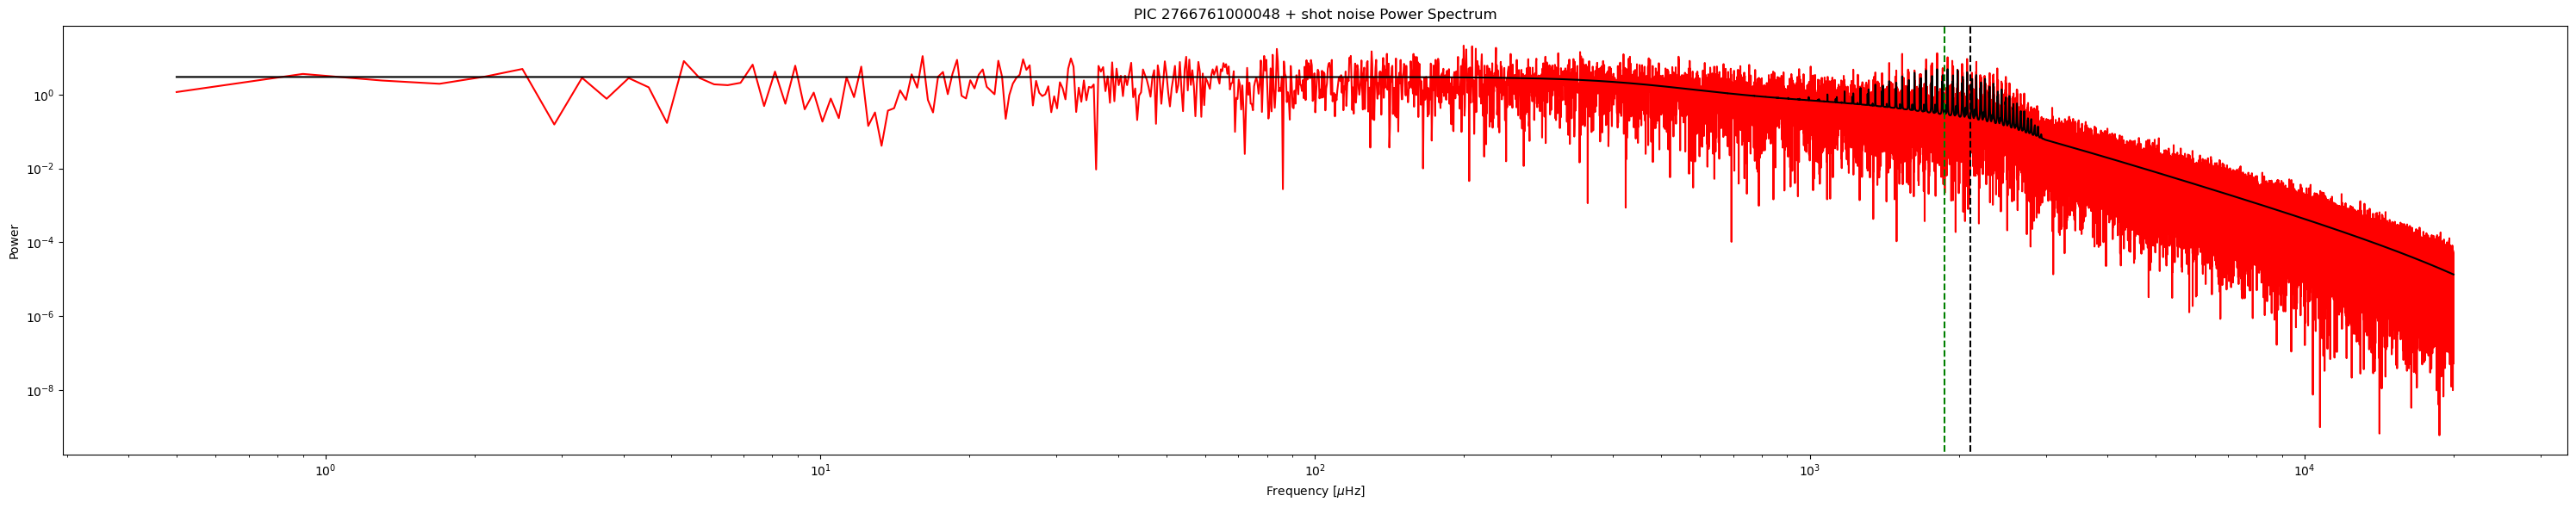

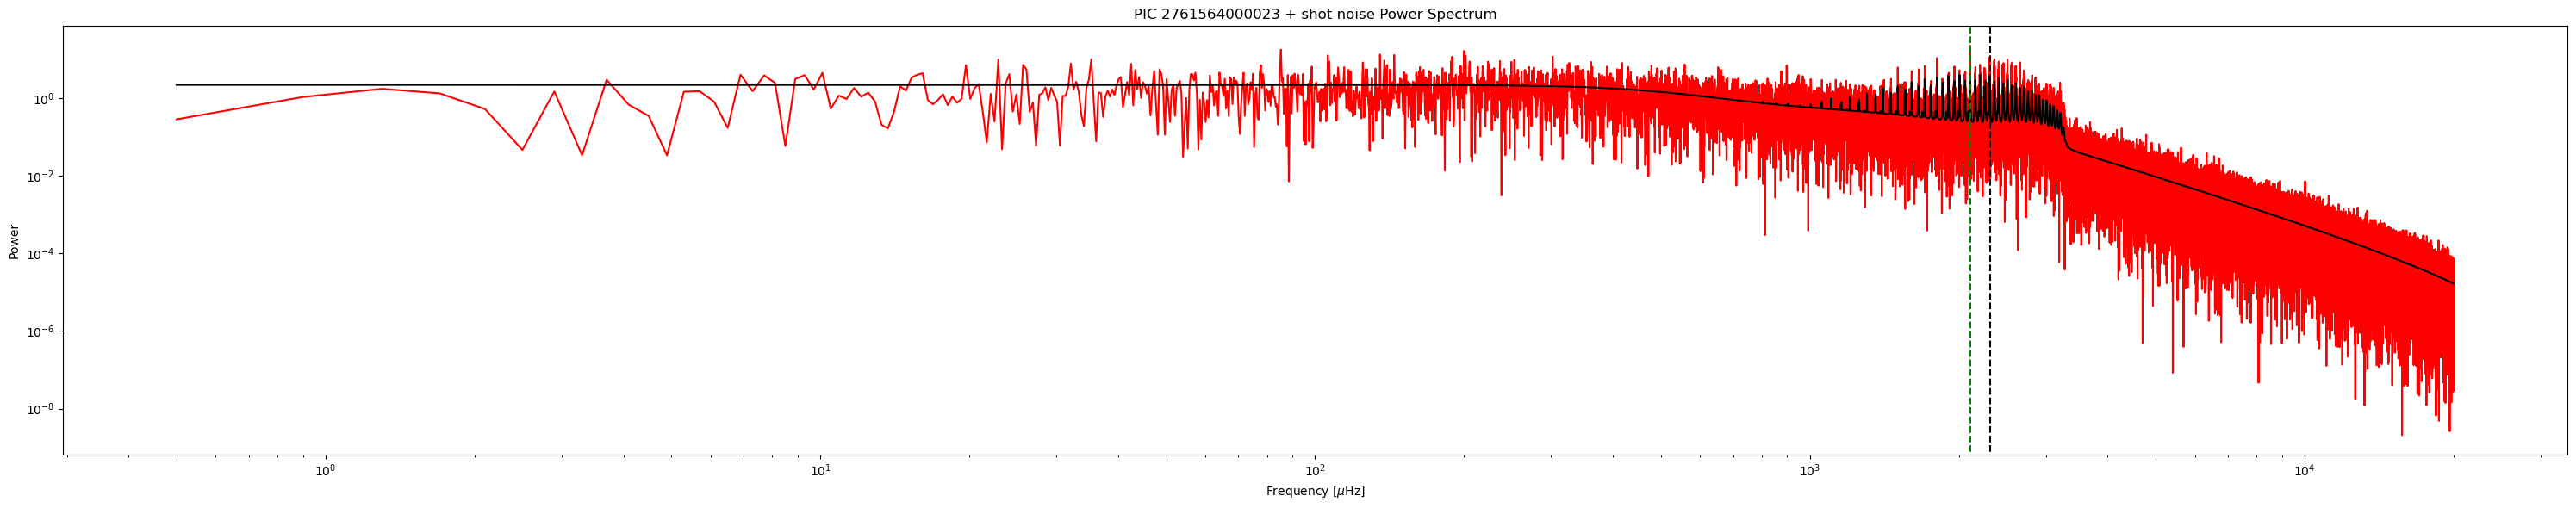

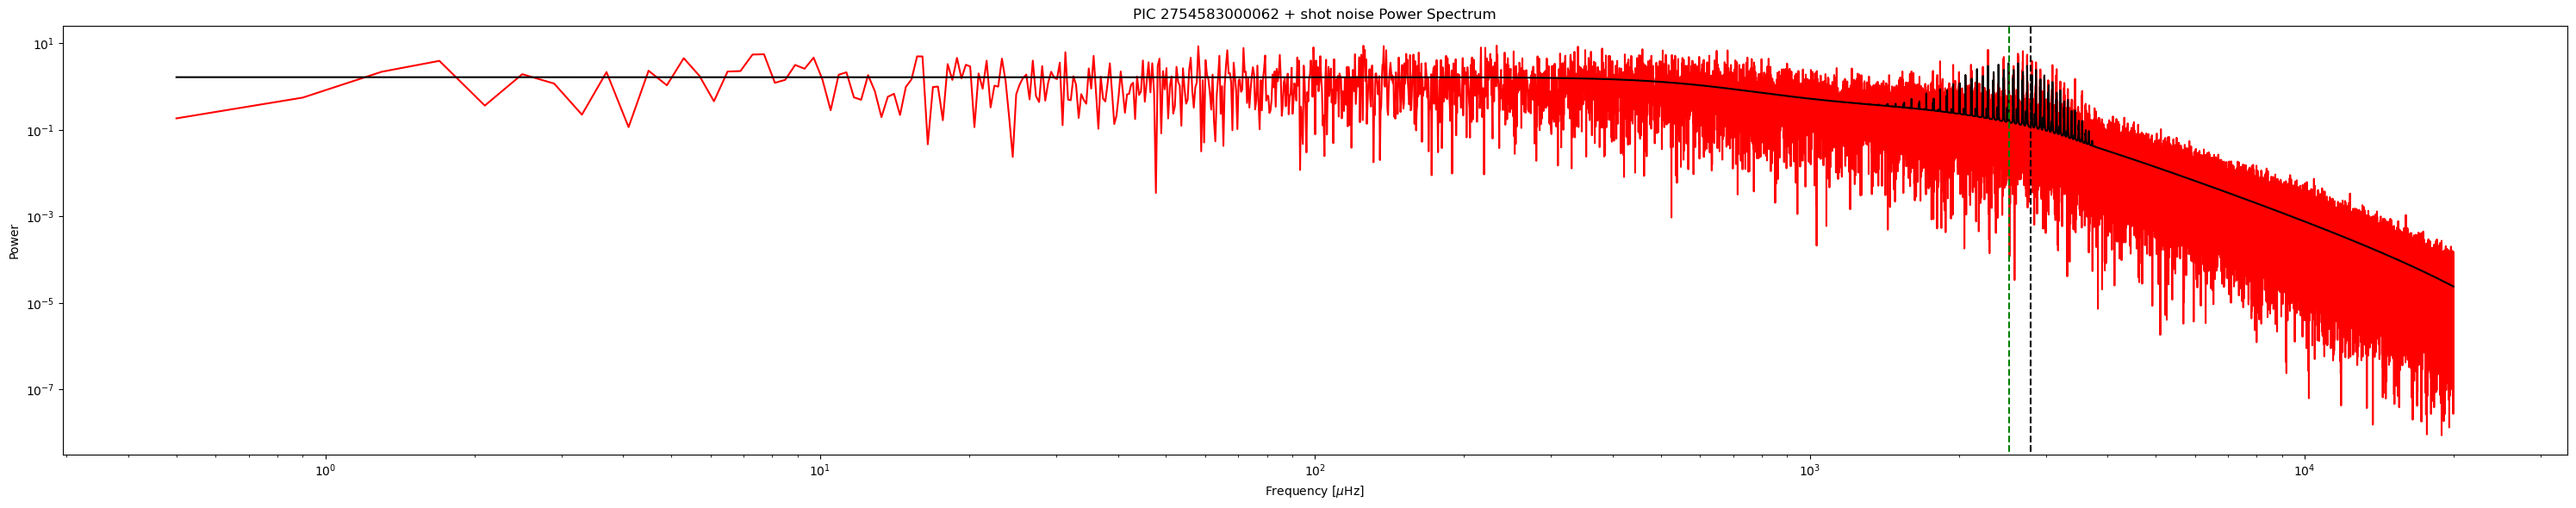

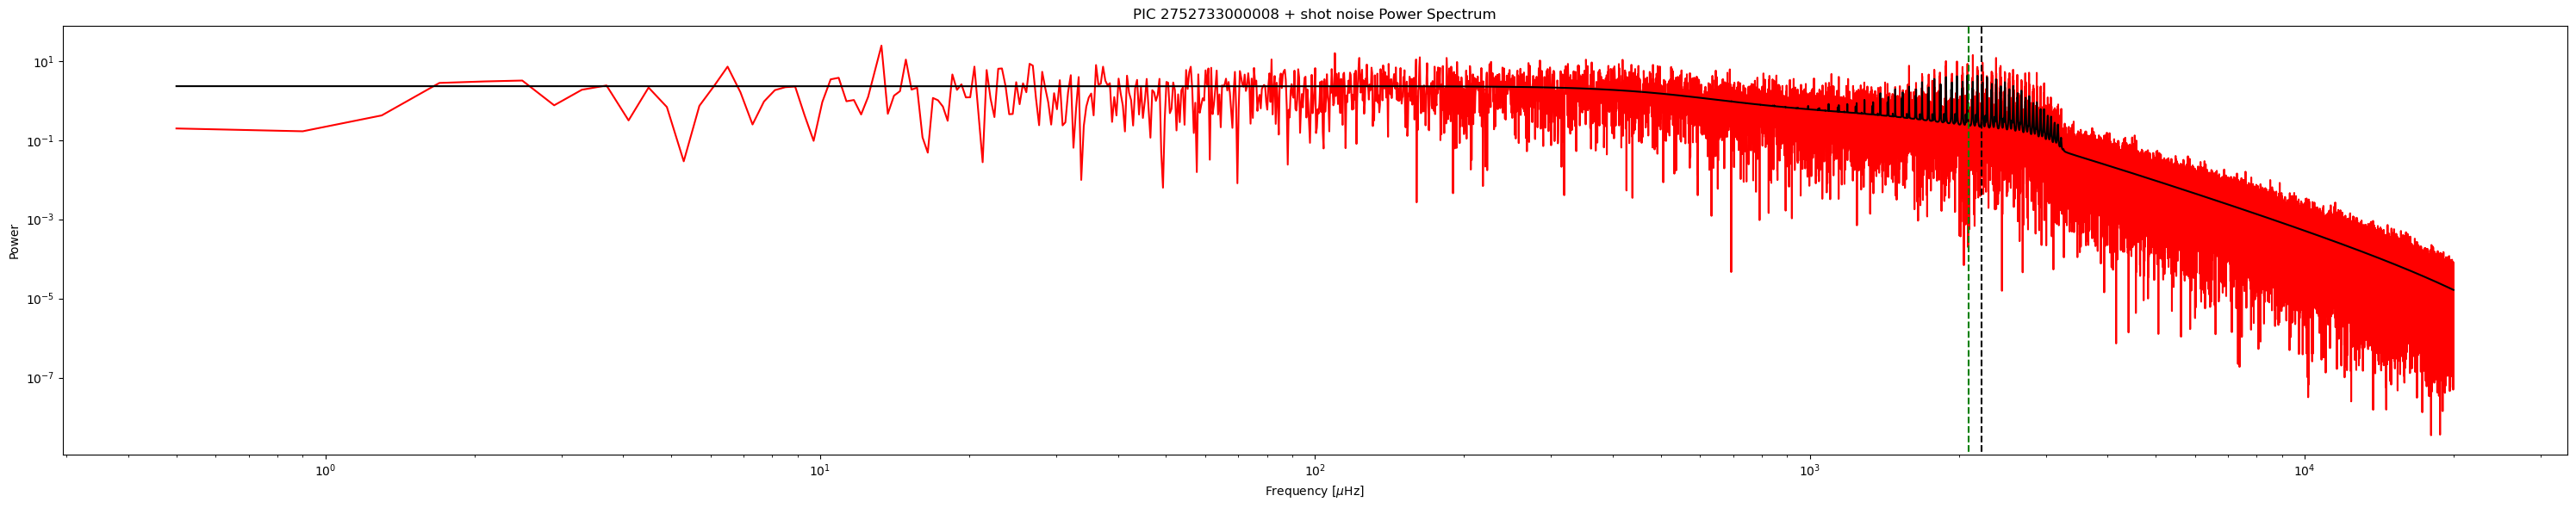

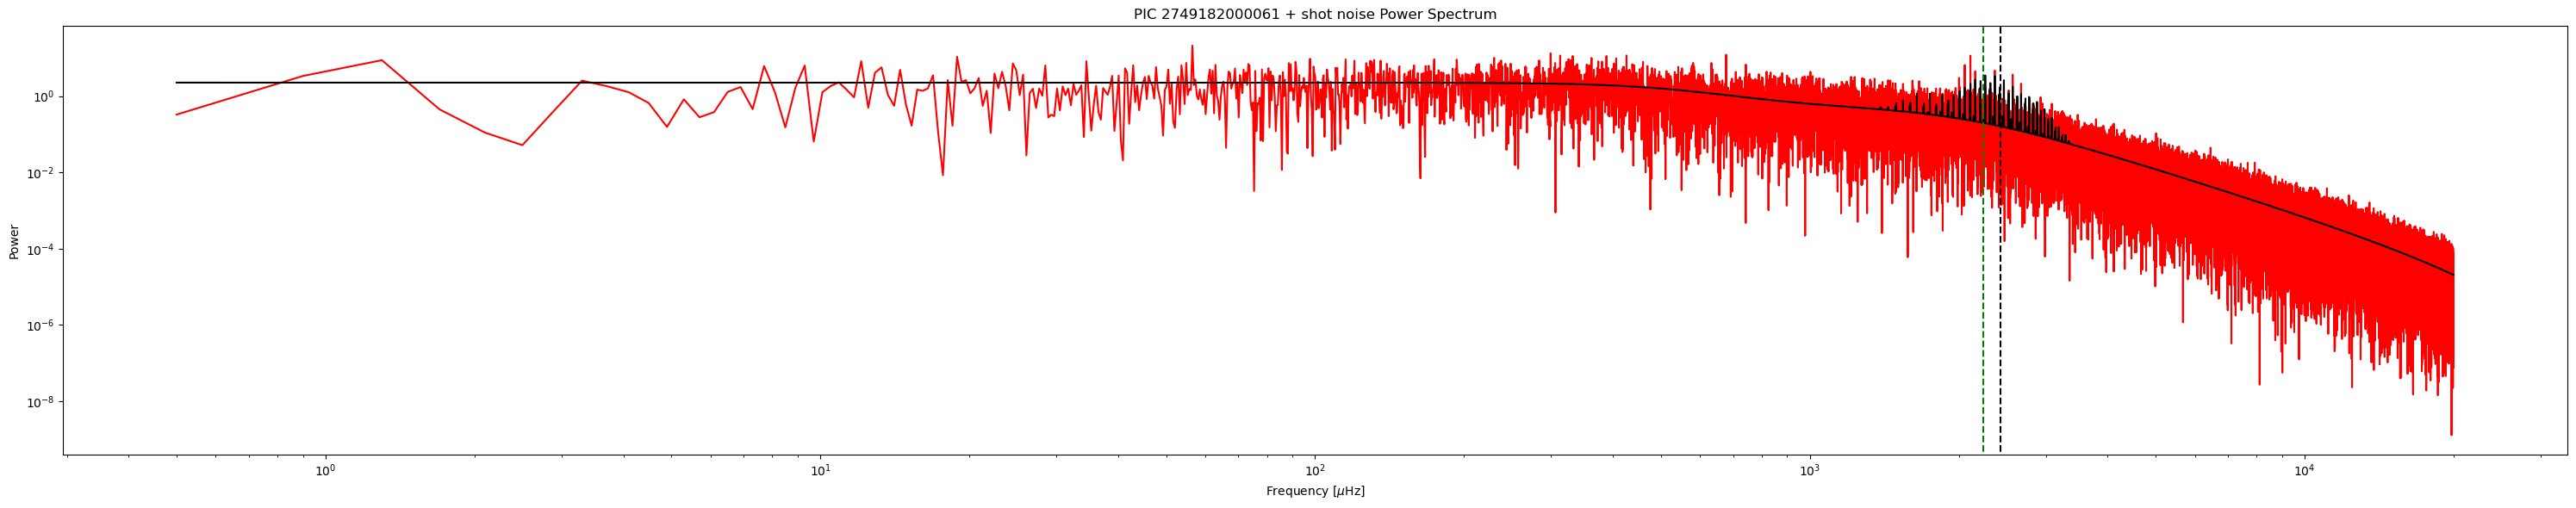

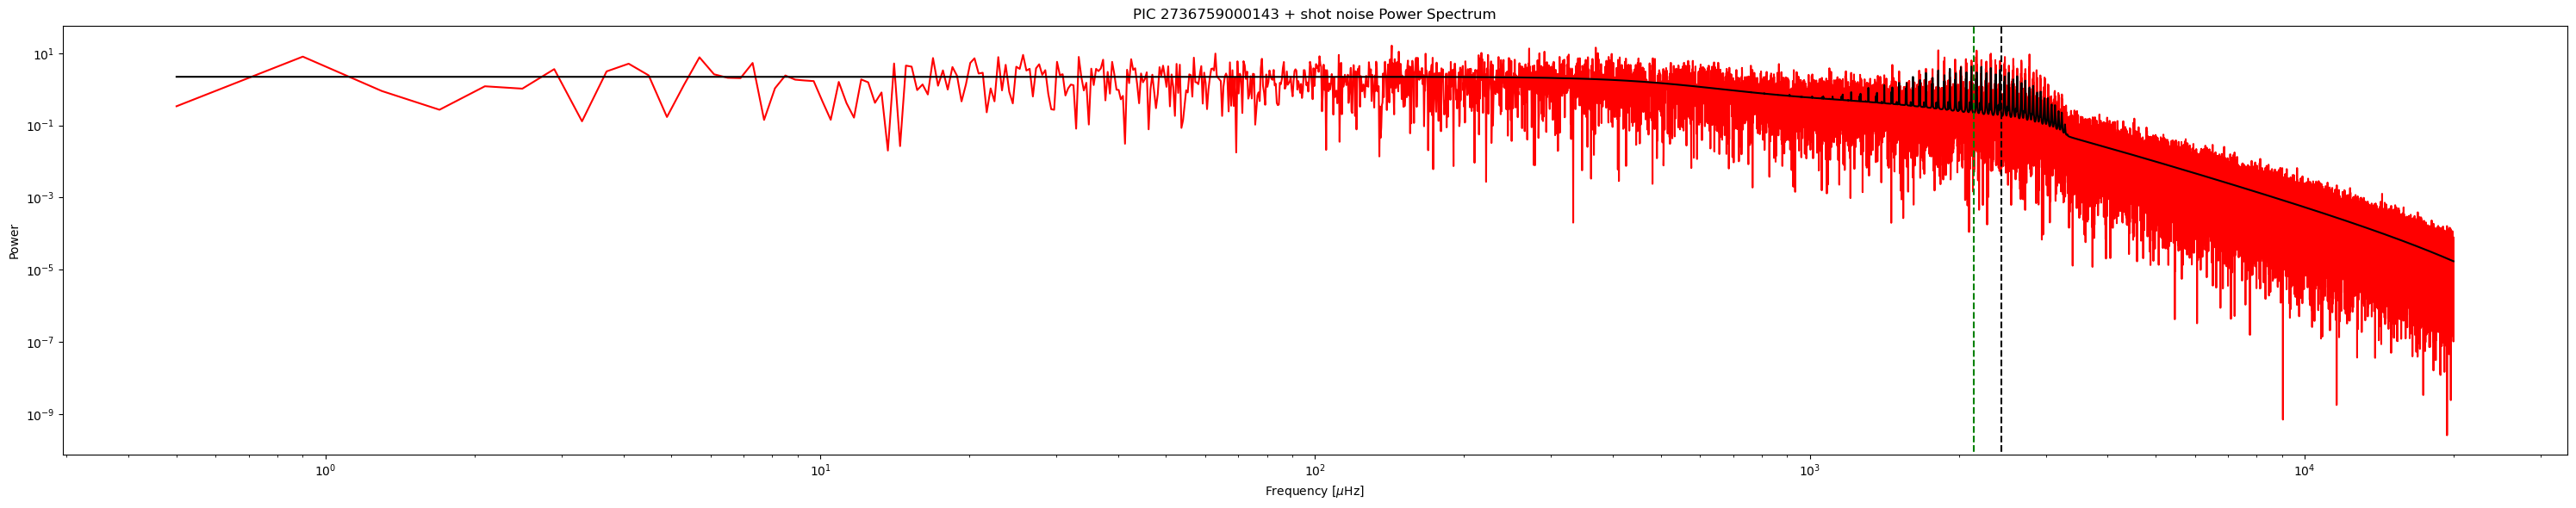

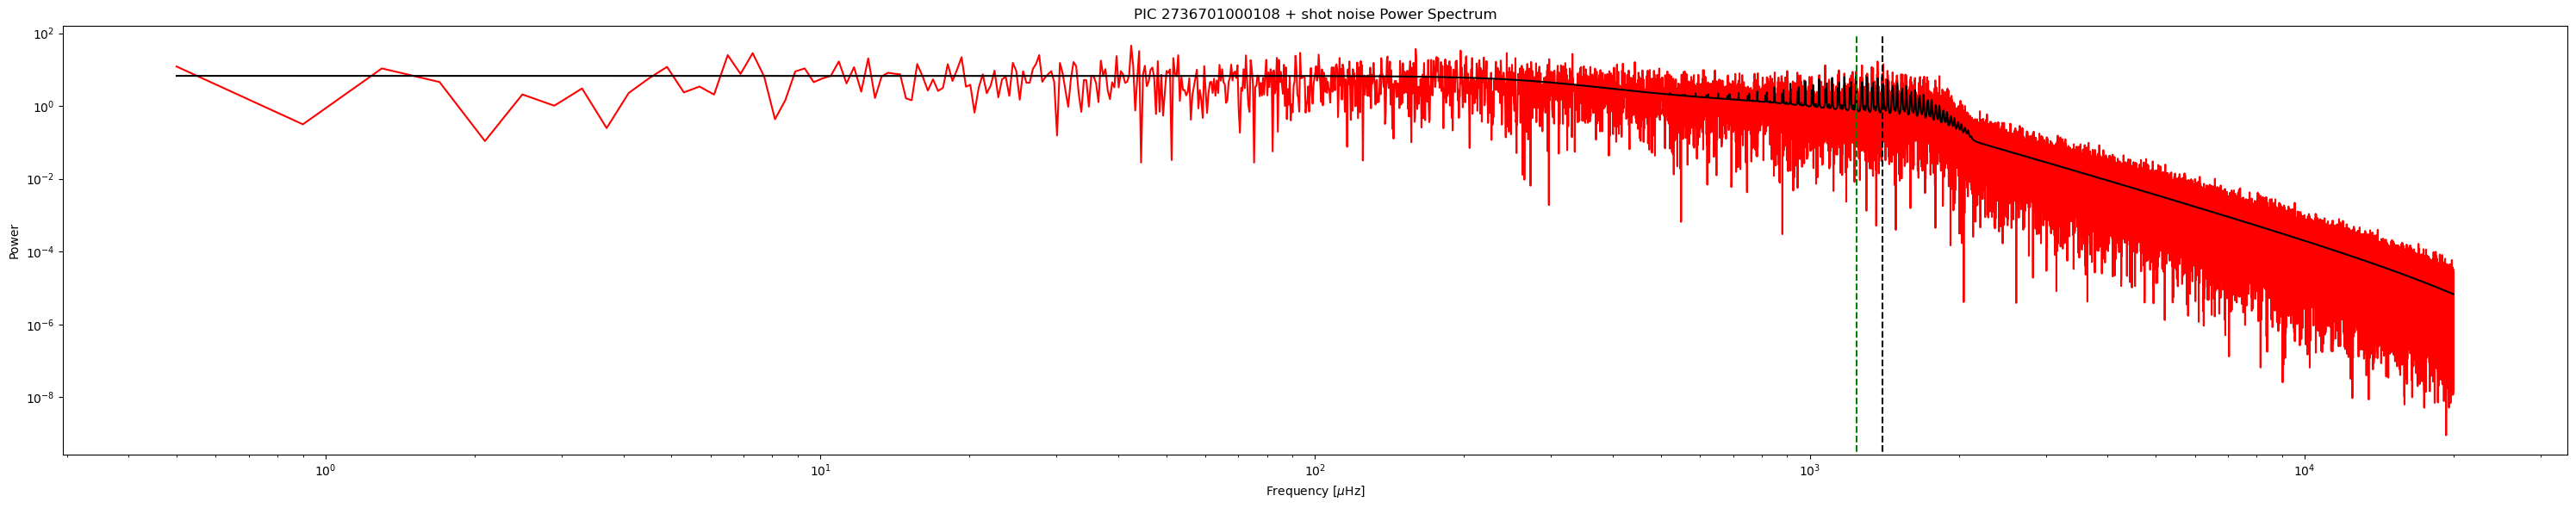

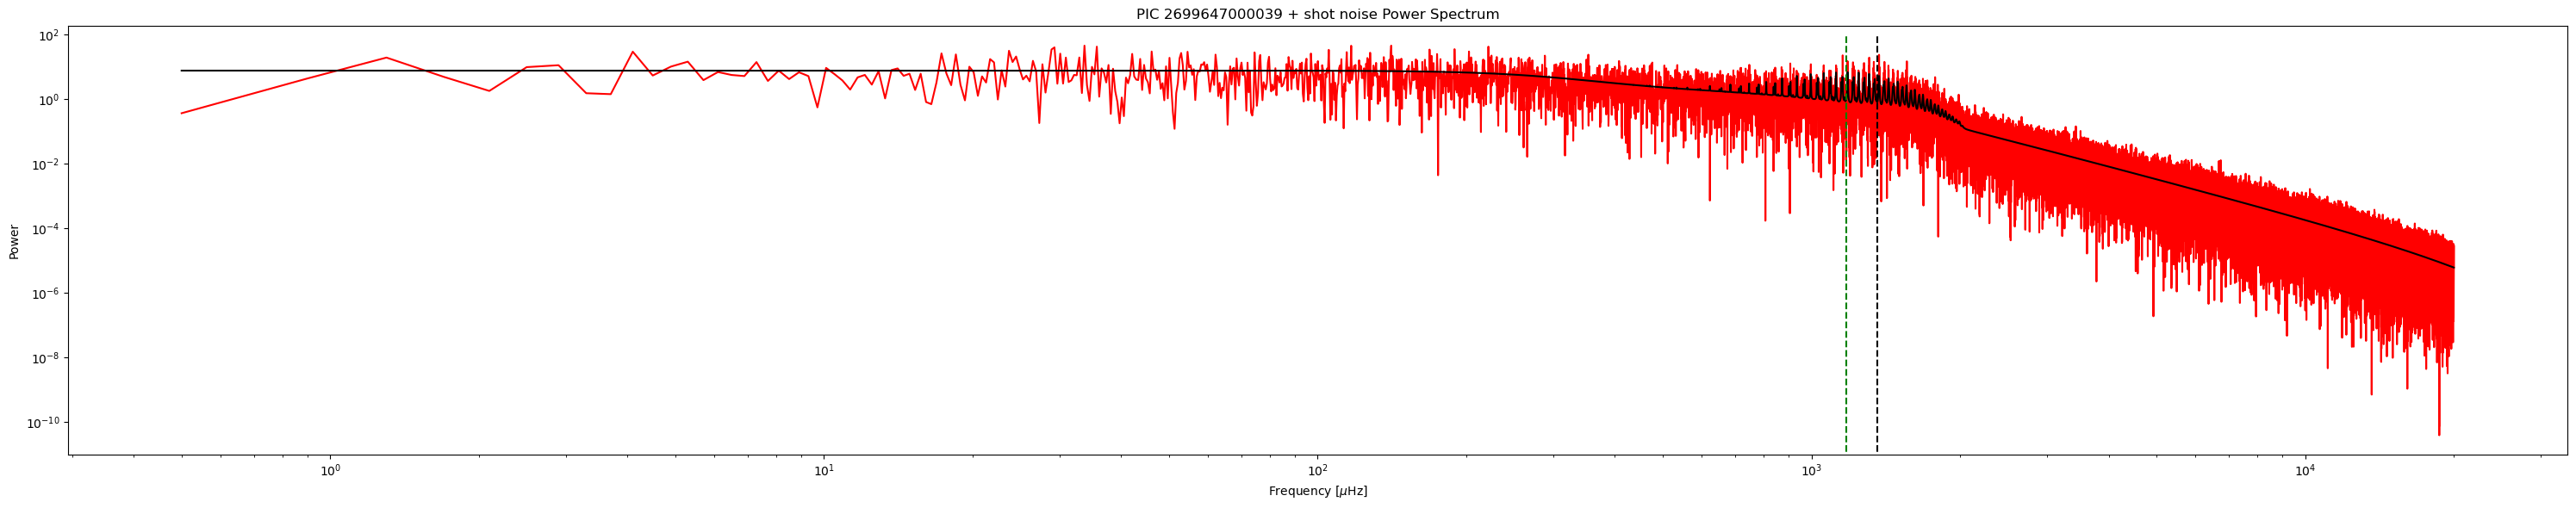

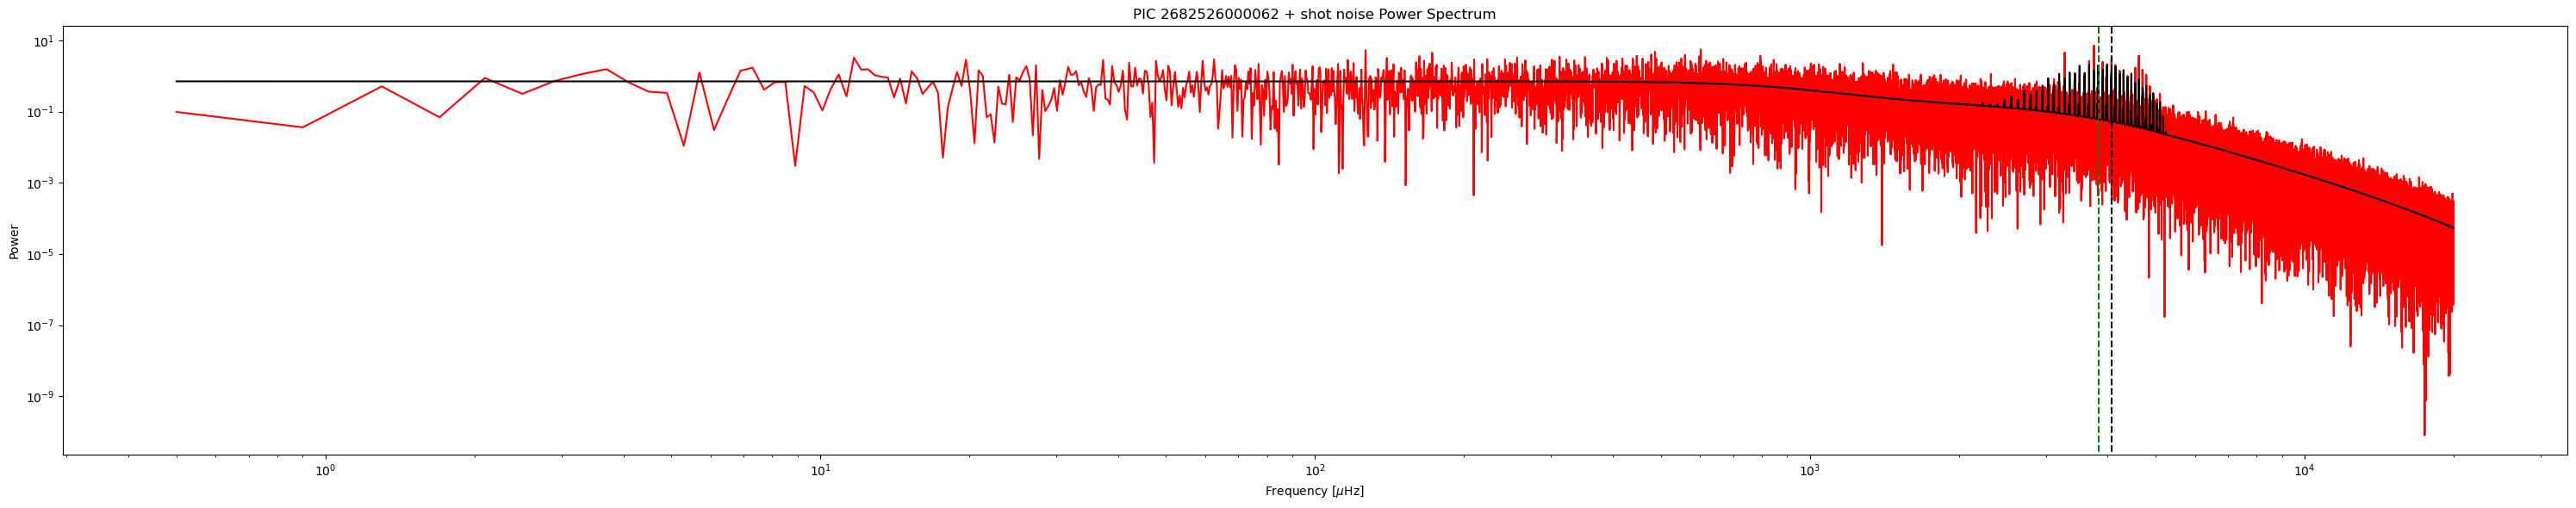

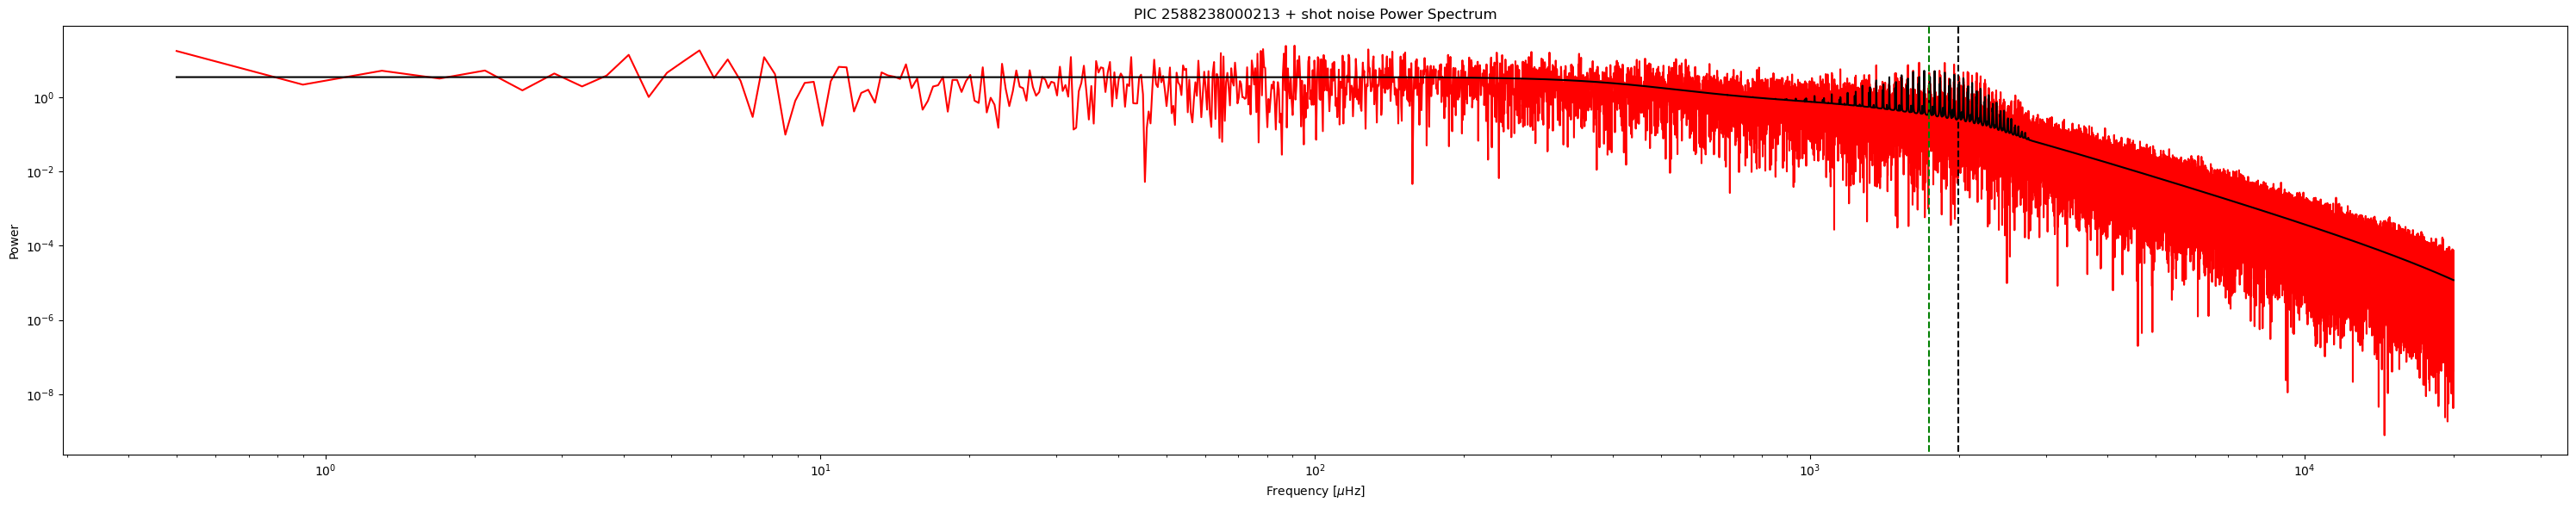

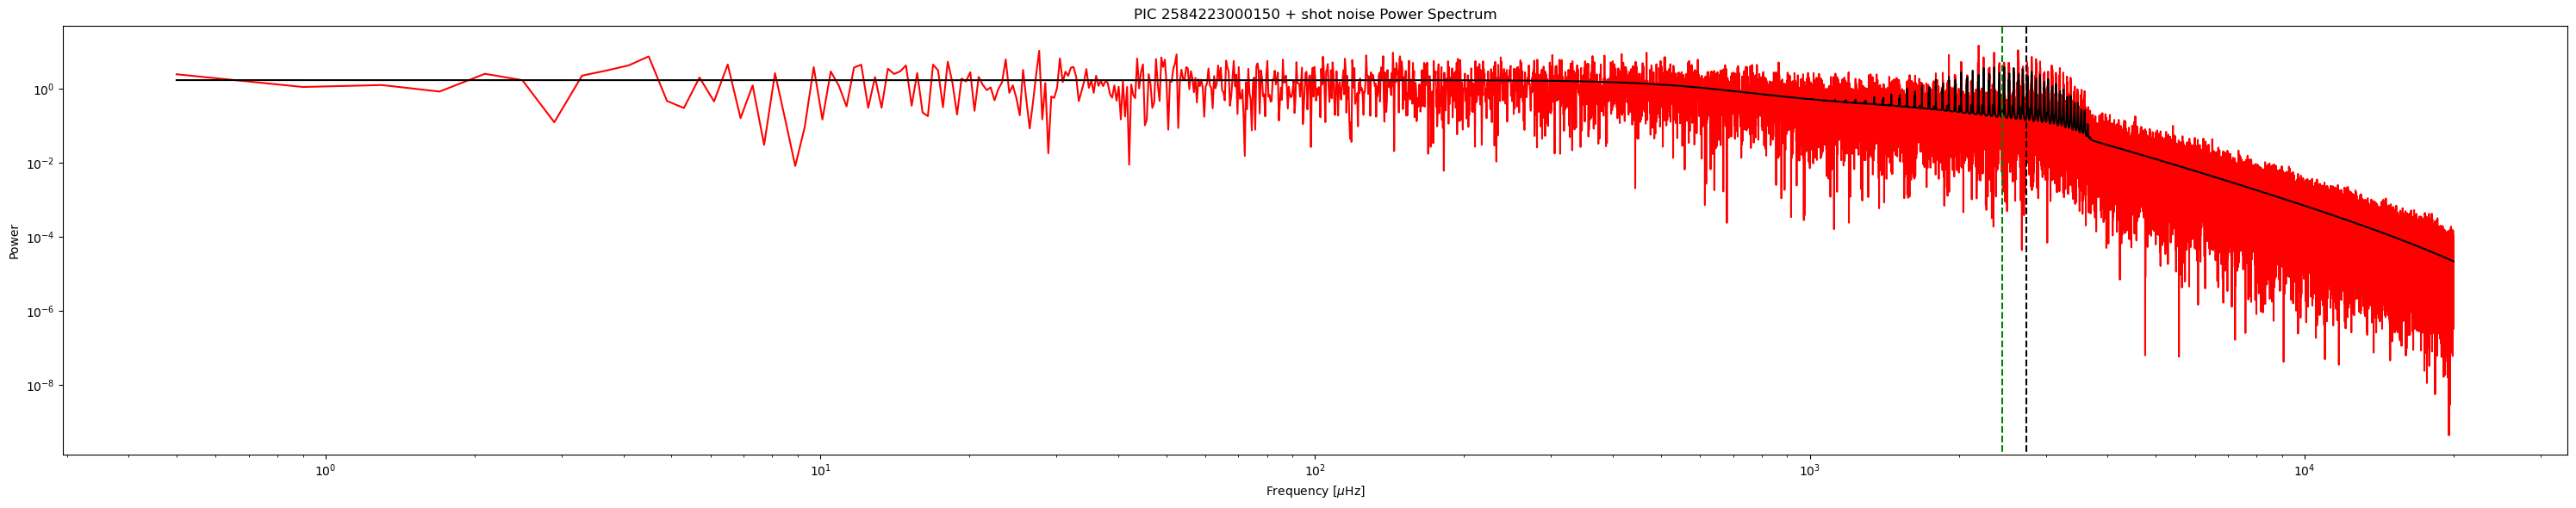

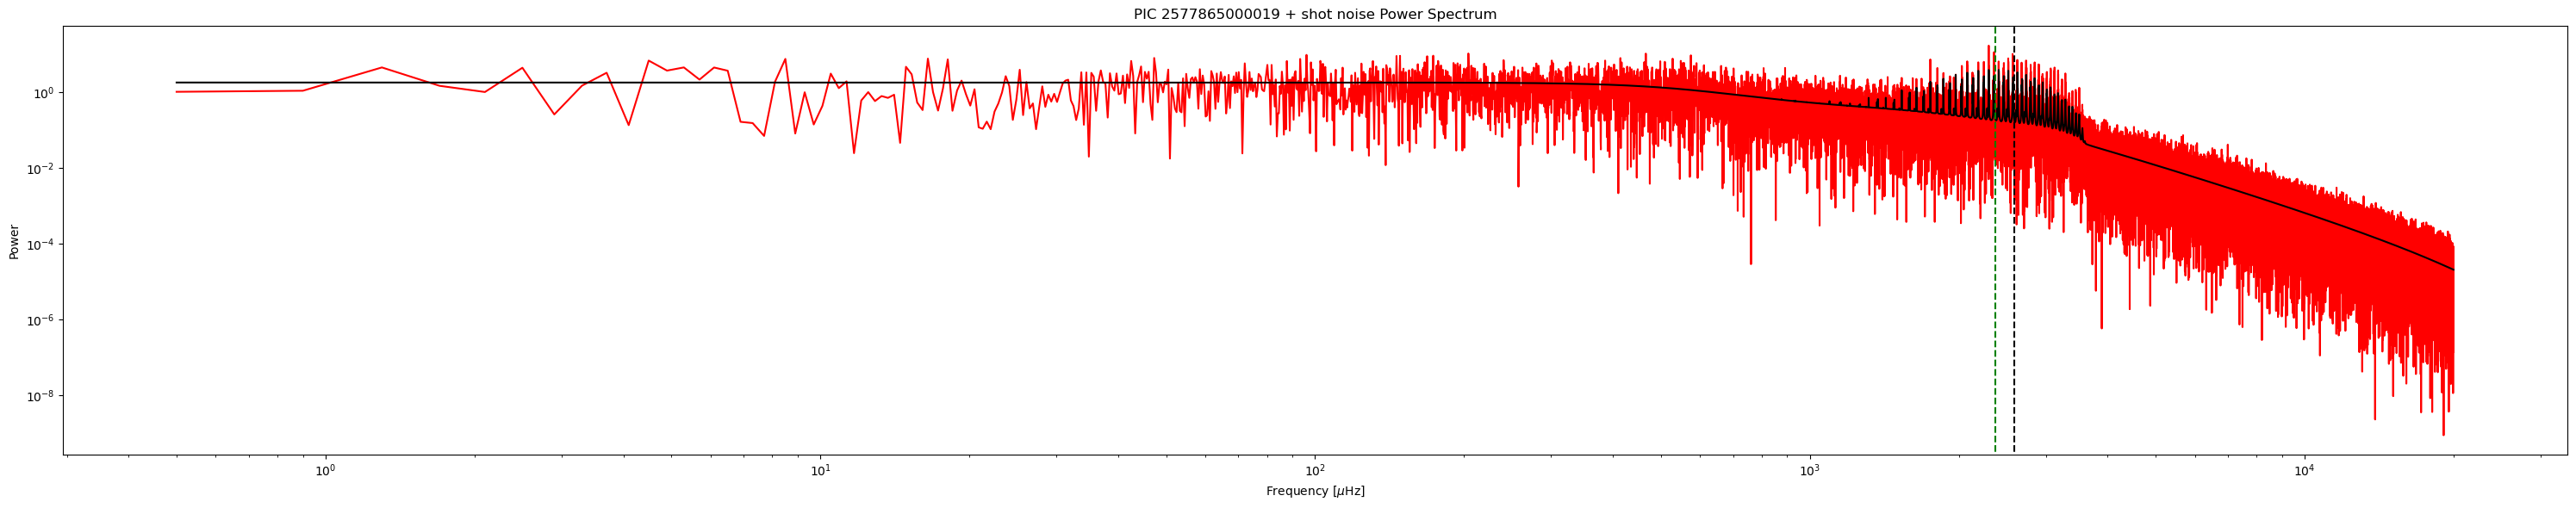

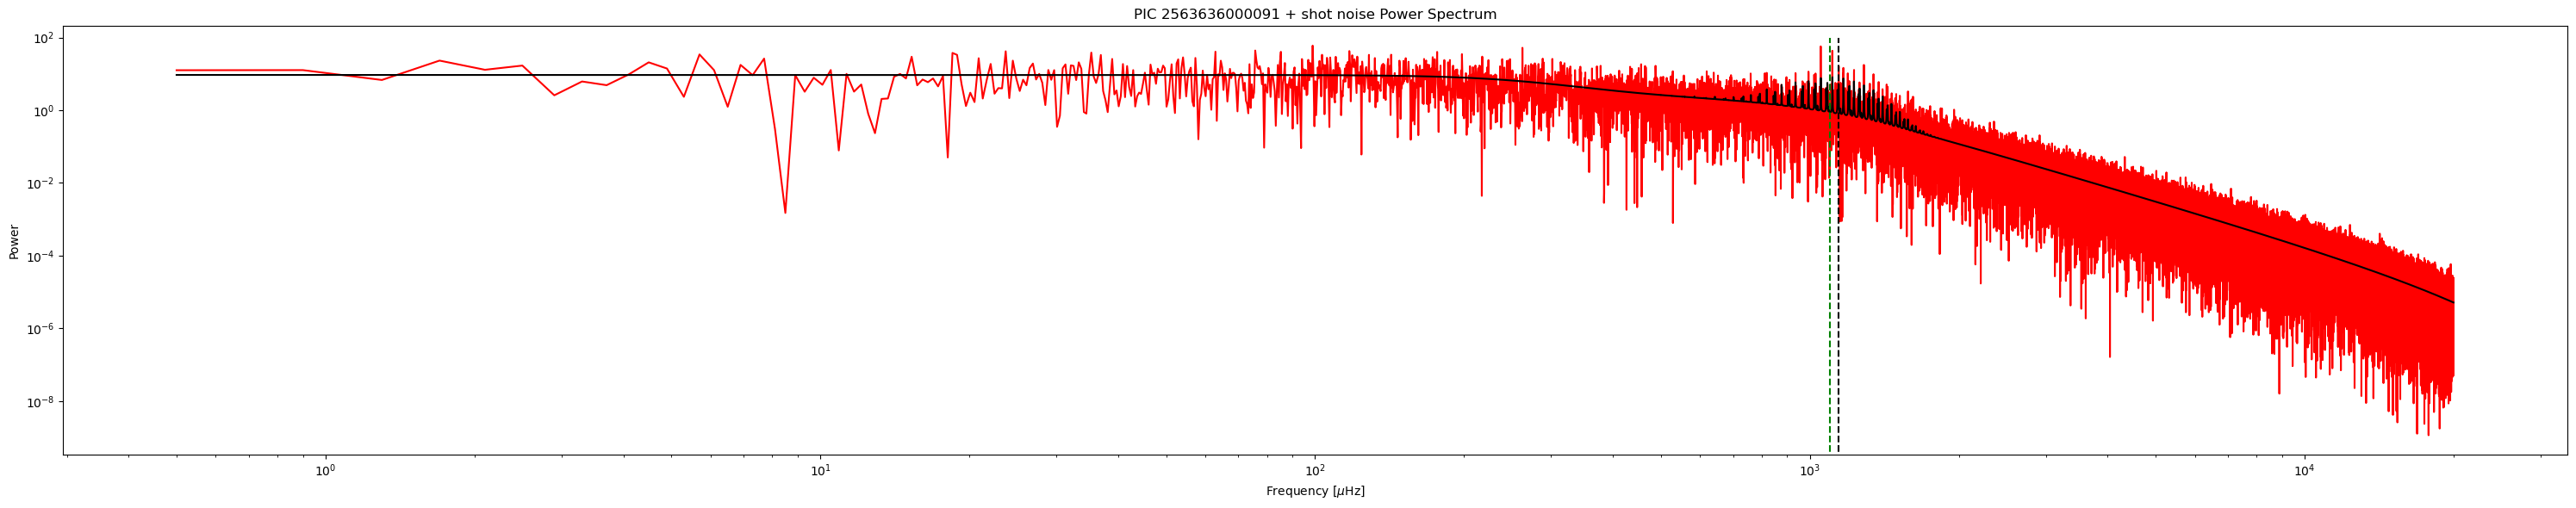

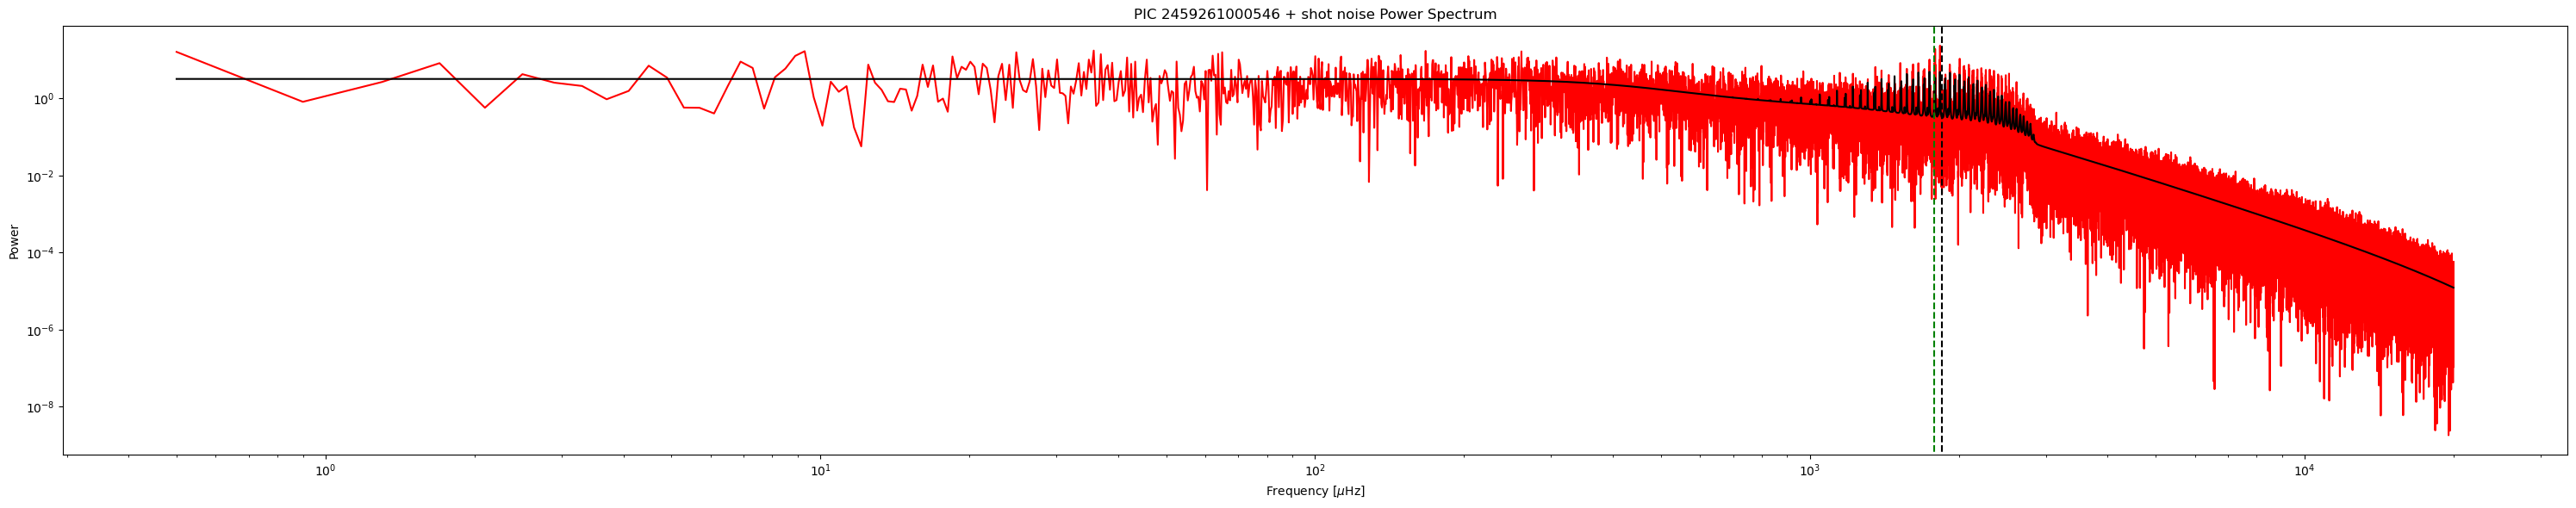

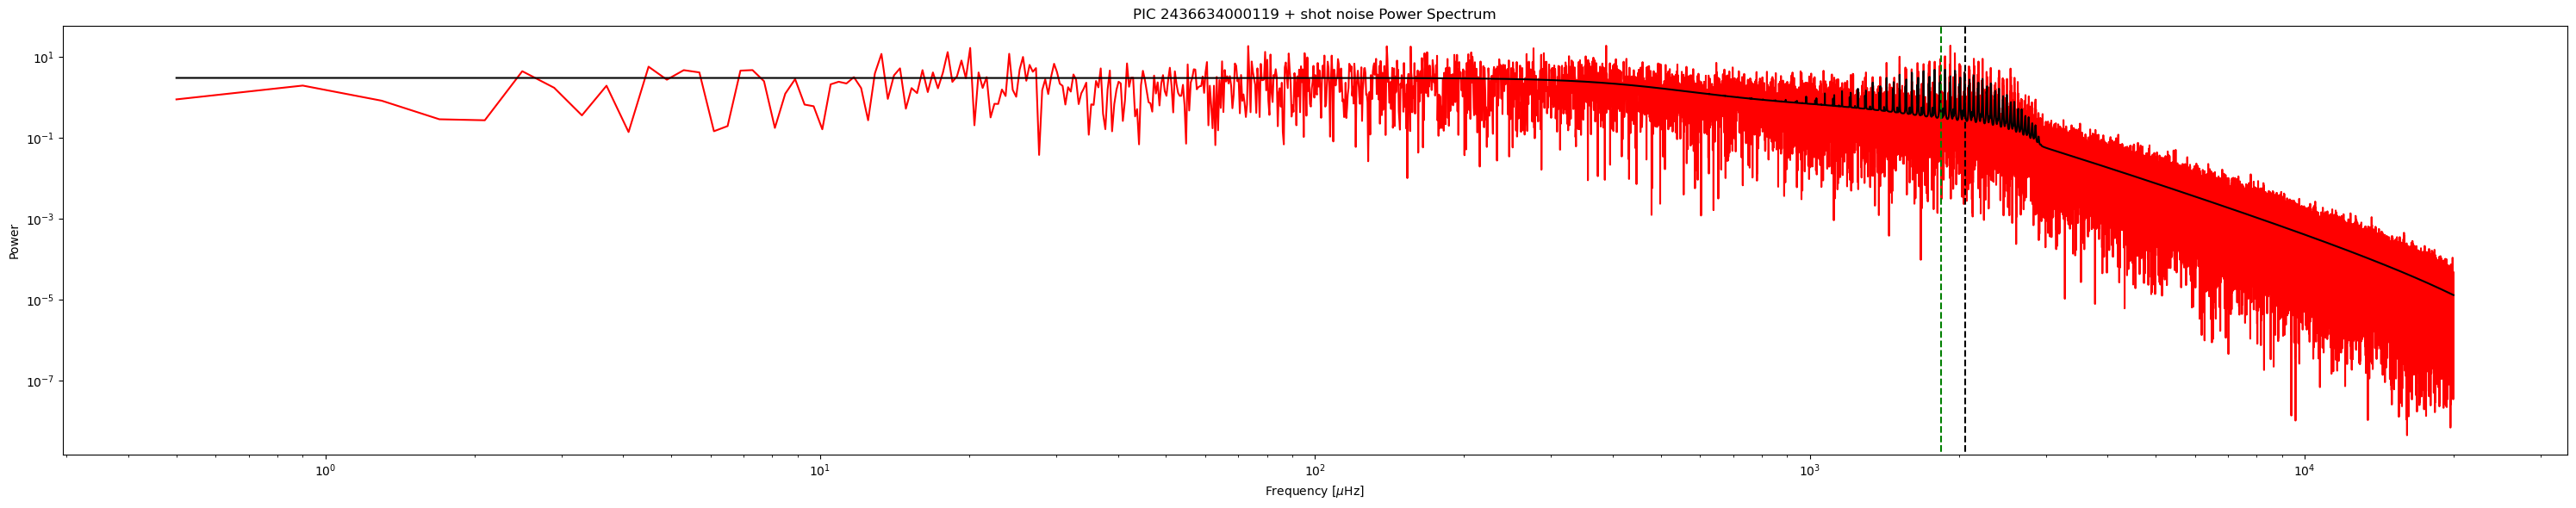

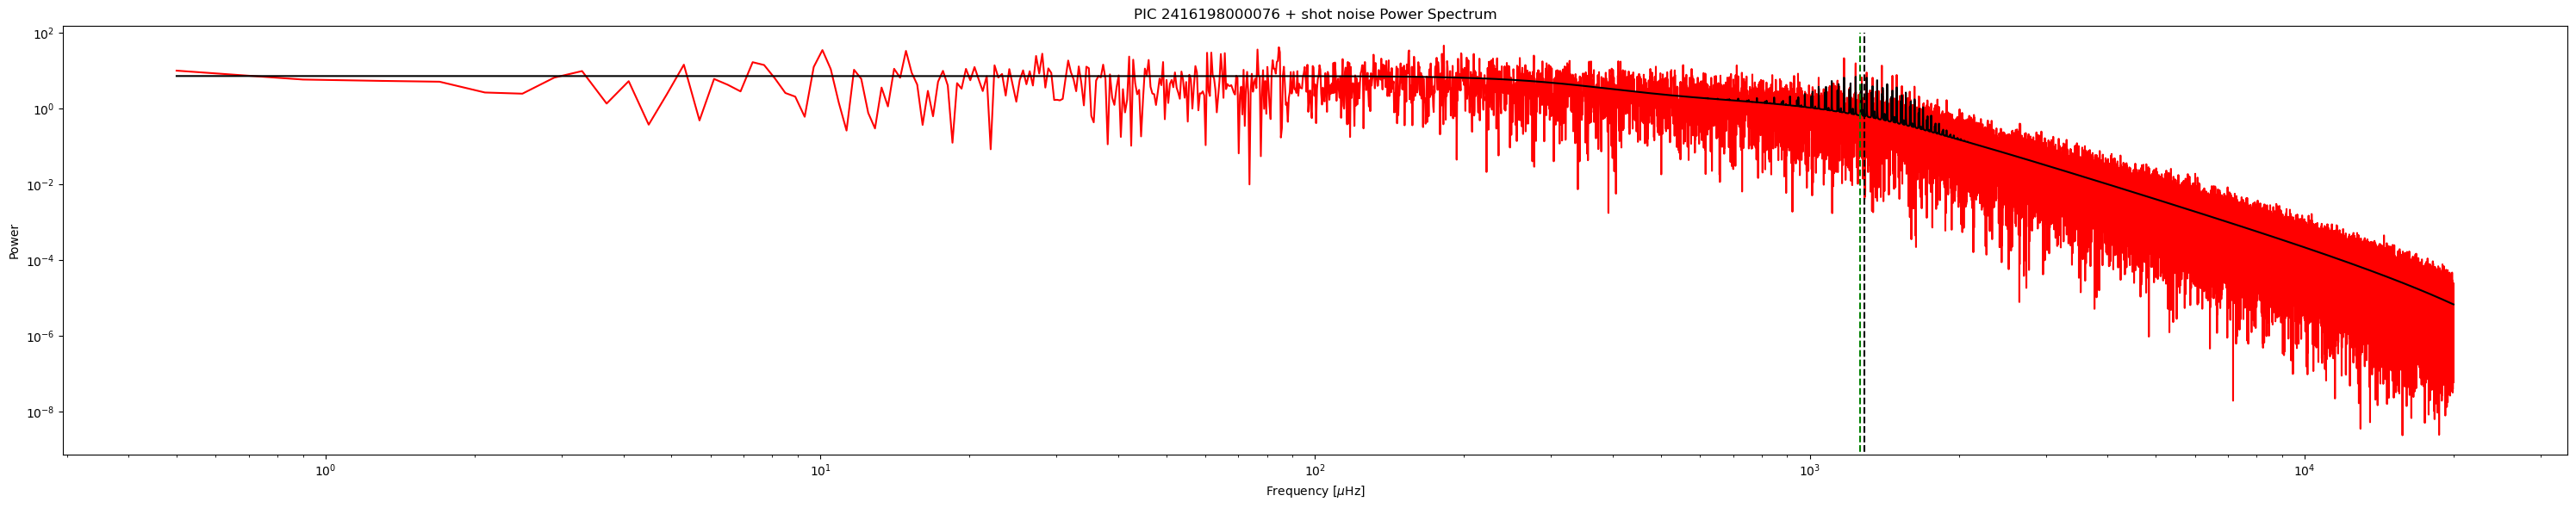

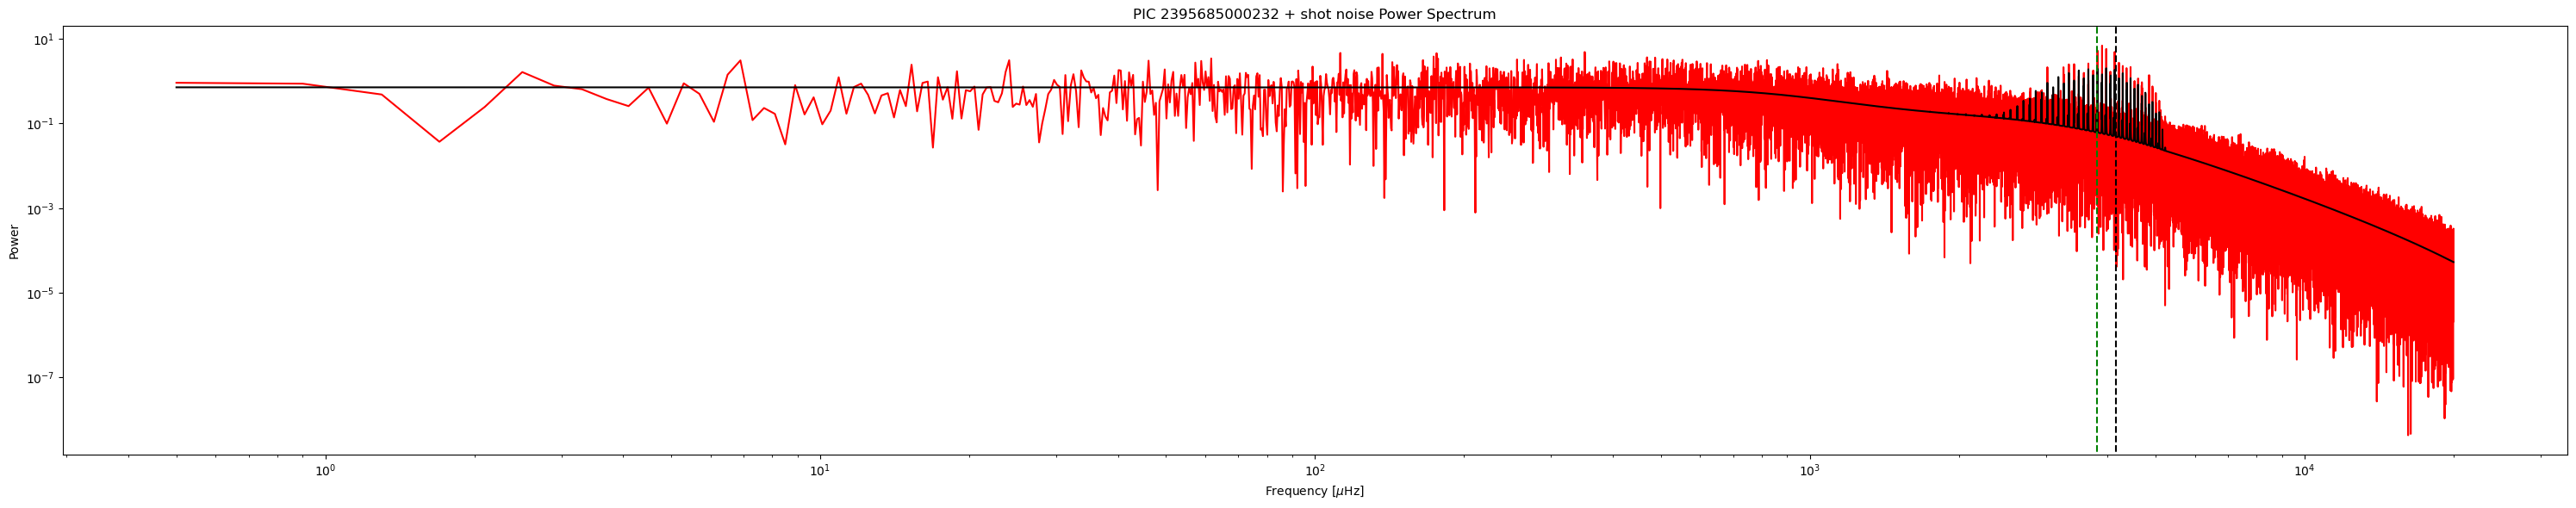

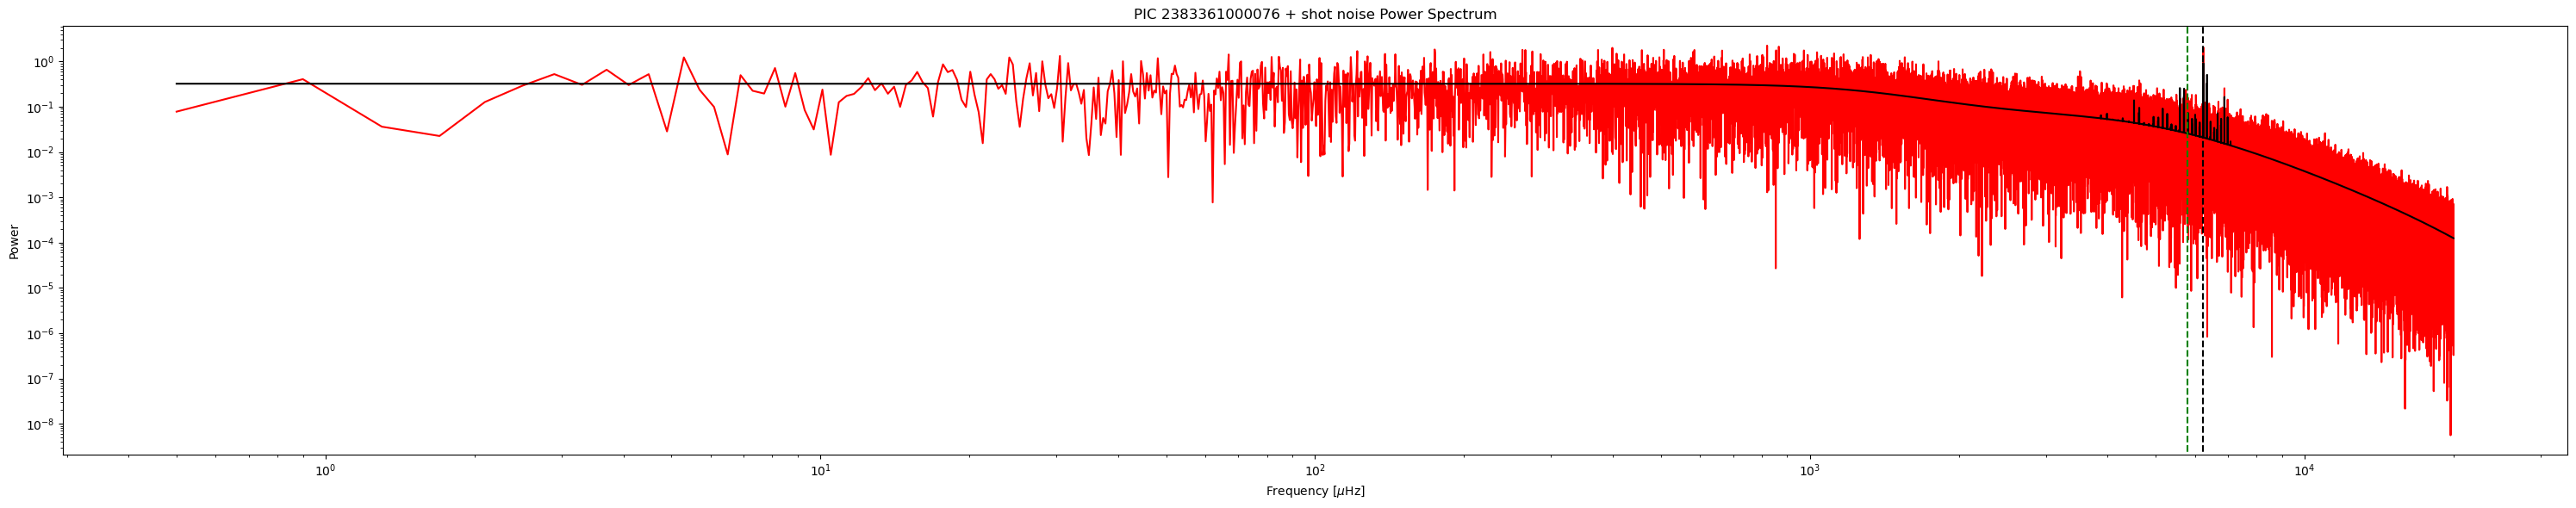

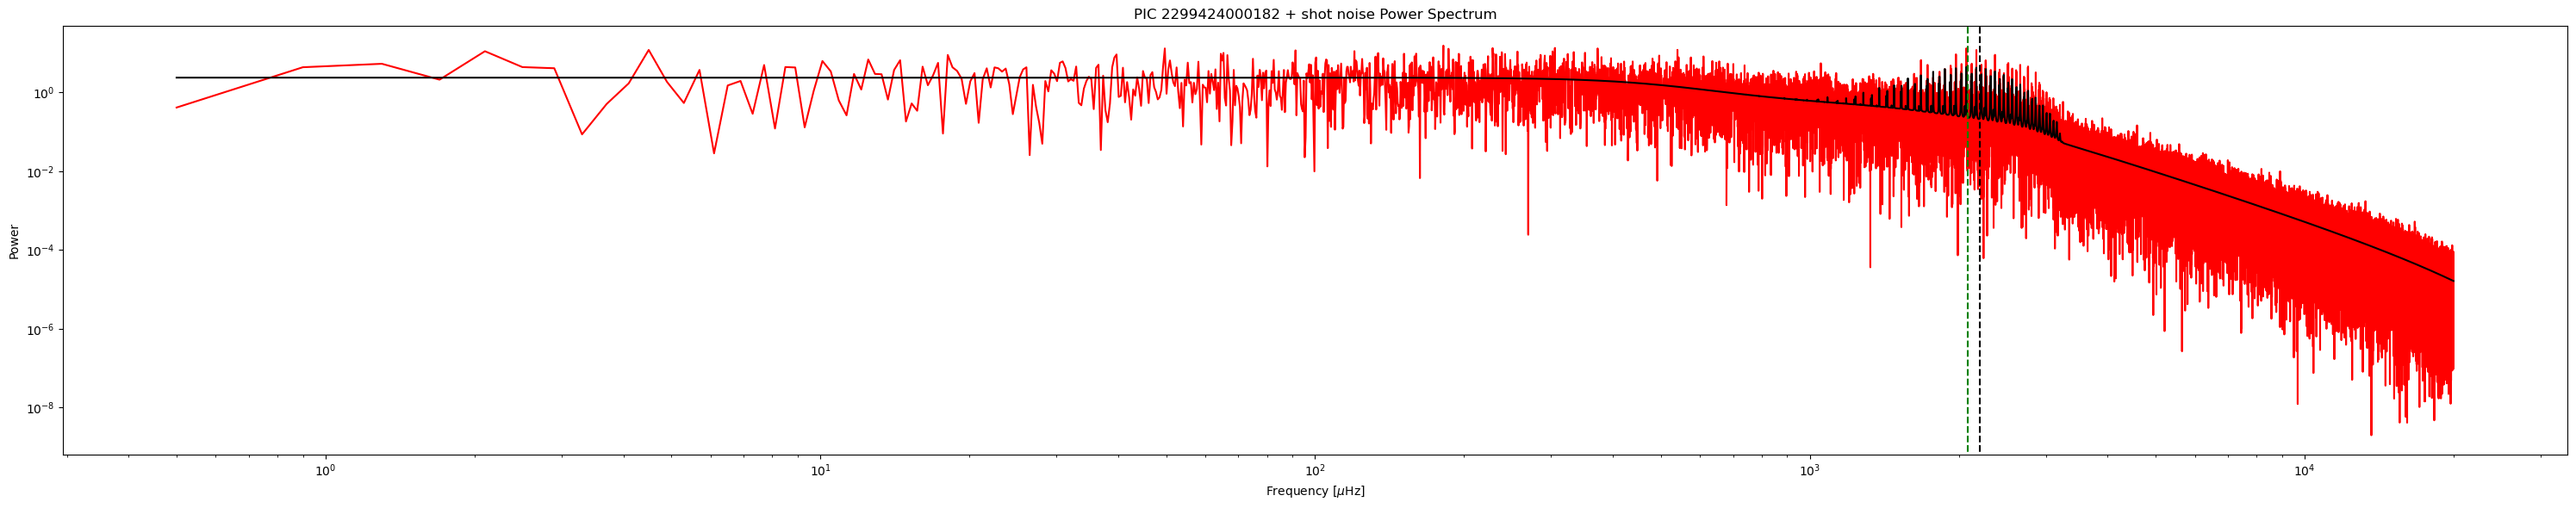

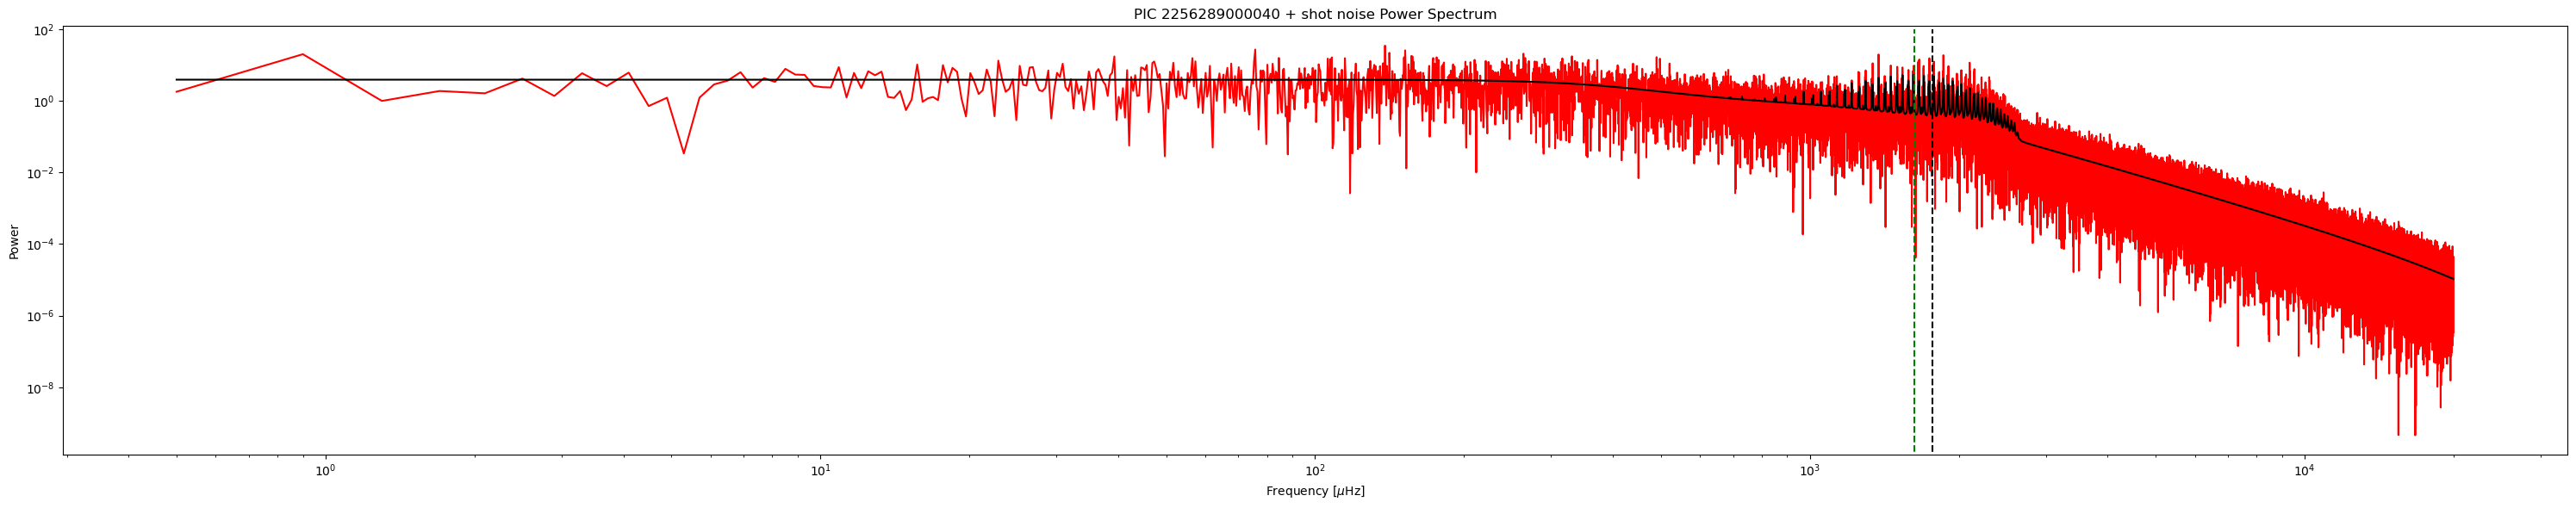

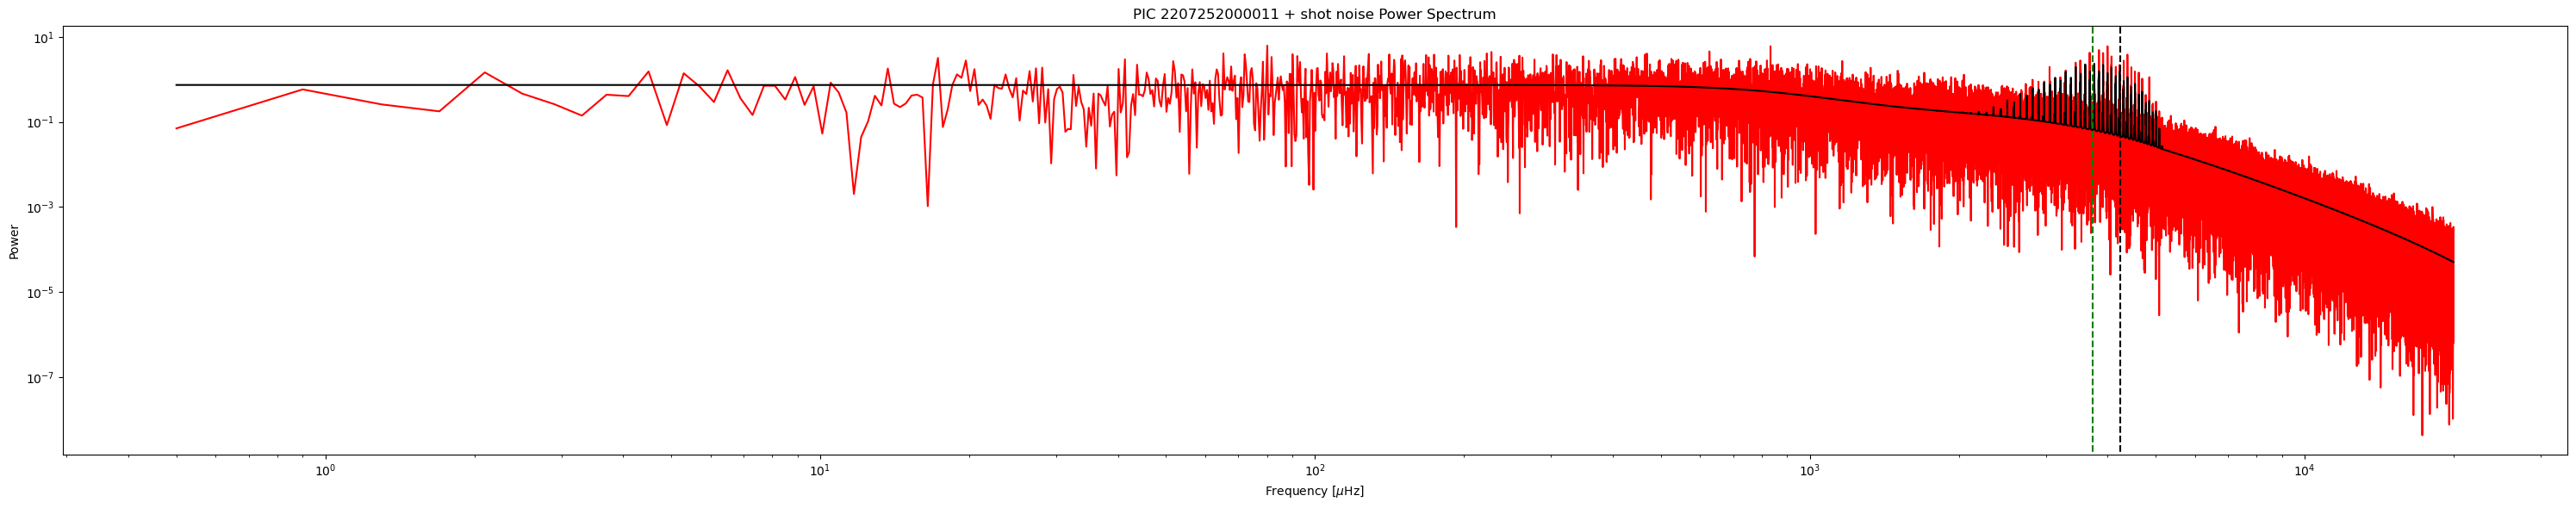

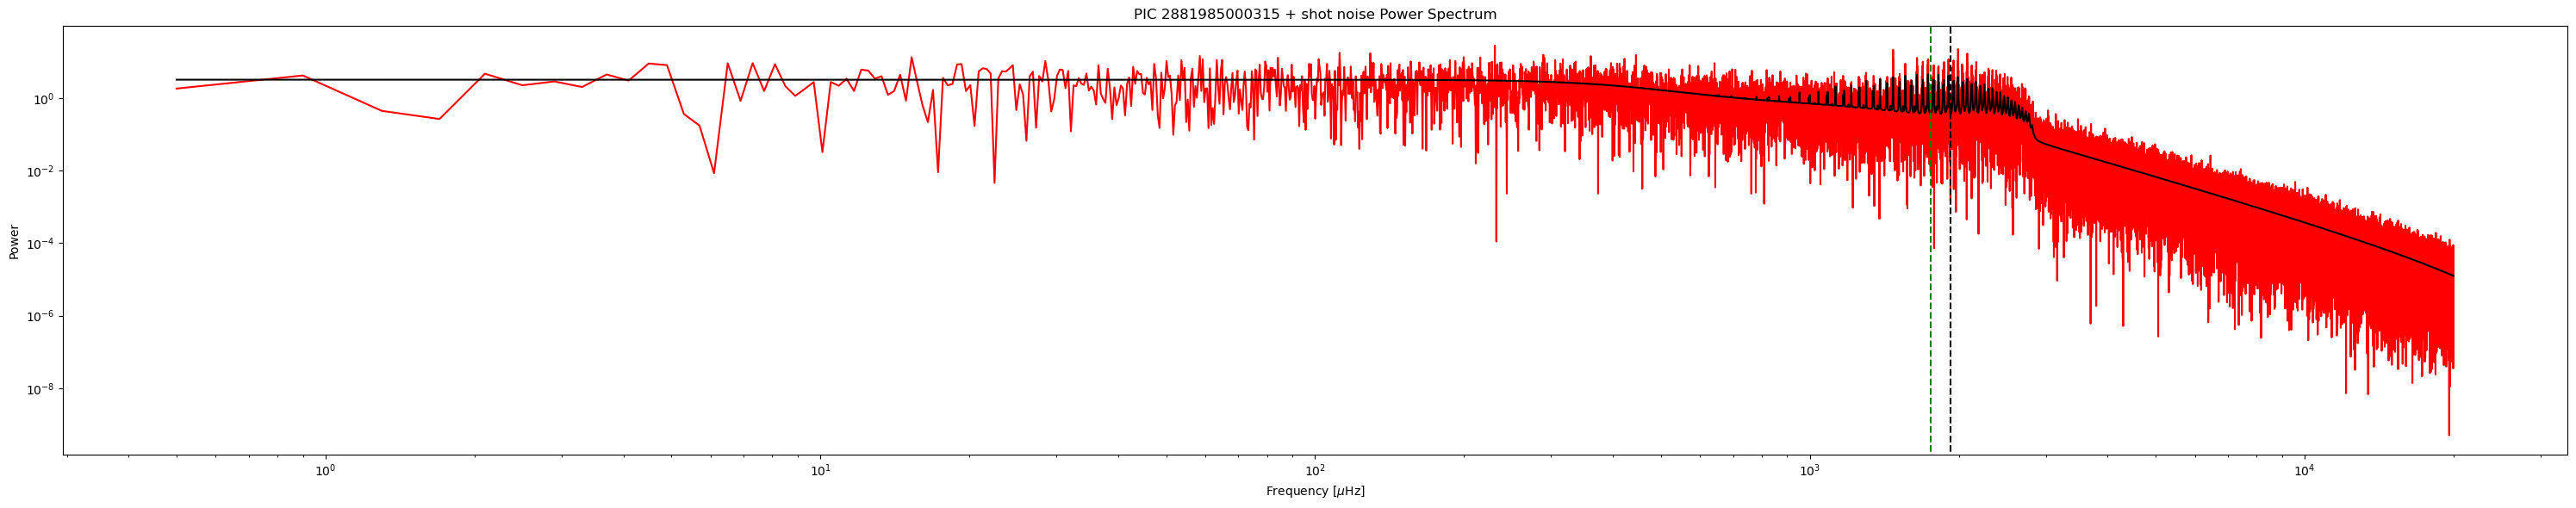

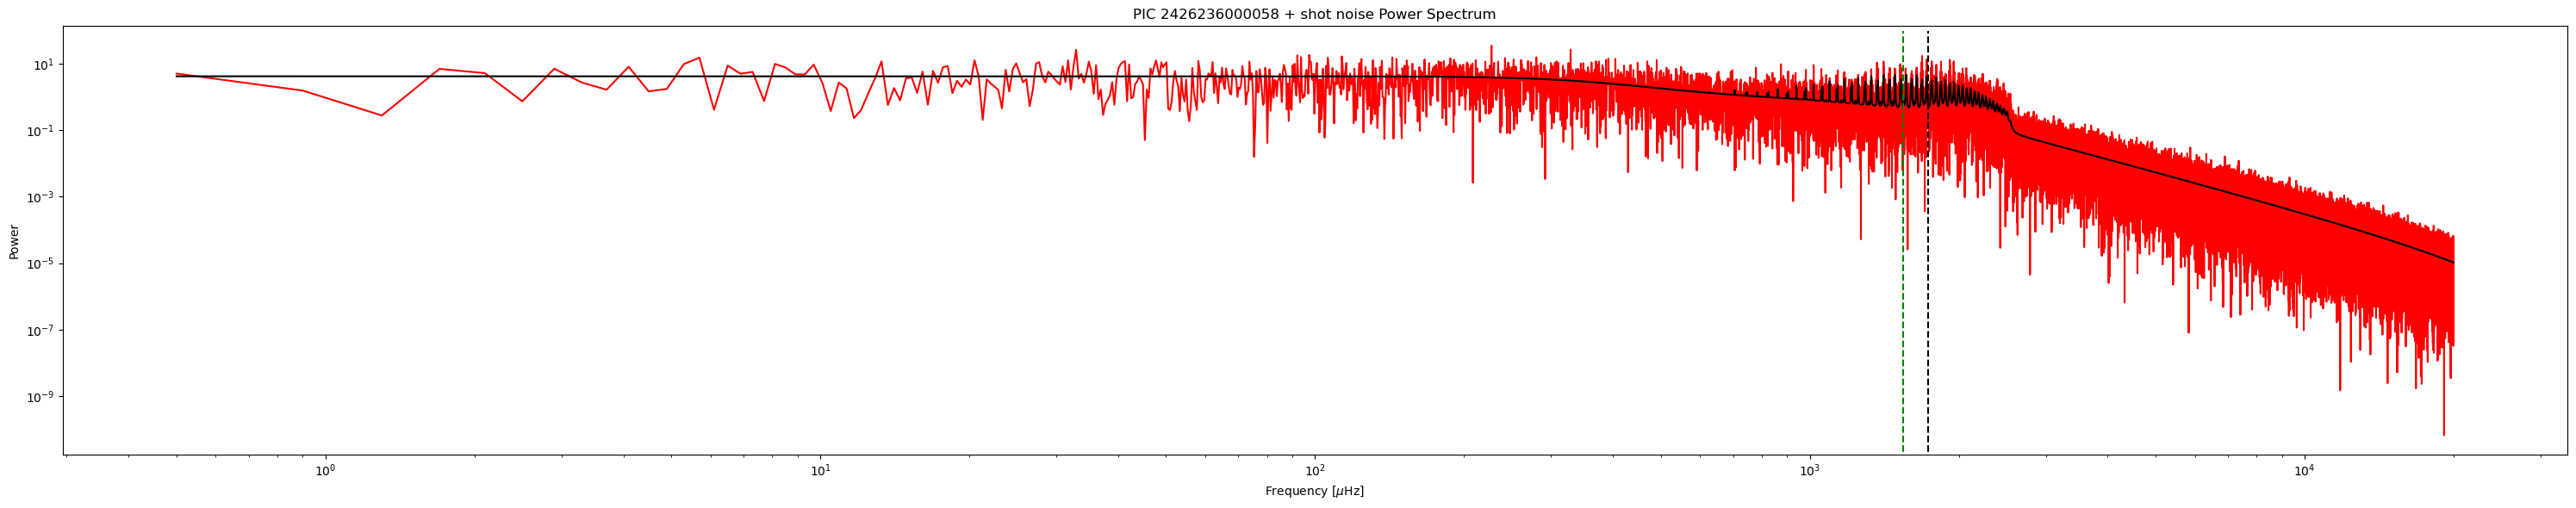

Nu_max metrics: [ 8.53996914  7.56140495  5.67384697  6.79236025  5.19614883  2.36297358
  5.94456558  6.50699119  6.80384111  6.41372895  6.06950333  6.68208184
  6.56550623  7.28026556  8.35544875  4.70743669  6.99892684  6.6131115
  8.28198428  5.92503944  5.30341638  3.67997424  5.53493745  7.20980186
  6.74984542  6.13694061  6.11148252  6.38382661  7.41204263  7.41732712
  6.12988349  6.37627738  6.30156078  6.36882465  7.78624599  4.97649228
  7.05739941  6.12067926  5.94605833 10.30910659  8.07967619  6.63488432
 10.08594326  6.75789592  5.79984668  7.25728913  8.19937713  6.23428701
  6.80754212  6.82500037]
Delta_nu metrics: [3.31591167 3.3216683  7.24365383 3.02255863 2.47107331 2.933274
 7.16206326 2.92490551 4.96264232 2.85826336 2.4027501  7.07381541
 3.57009193 3.25332042 2.24388228 3.18740531 3.42446025 4.1978936
 4.79035388 4.3984484  5.58476186 3.33713002 5.01759629 3.44253912
 3.89235977 3.76534519 3.82331038 3.88571299 3.62495696 4.244056
 3.97422771 6.73135115 3.11

In [38]:
# Prepare lists to store results
data_folder = r"C:\Users\douga\Documents\Asteroseismology\Simdata\50_star_list"
labels = matched_picnames

freqs_list = []
powers_list = []
oscillations_noisy = []

nu_max_metrics_kepler = []
delta_nu_metrics_kepler = []
combined_metrics_kepler = []

delta_nu_fits = []
delta_nu_errs = []
nu_max_fits = []
nu_max_errs = []

noise_lvls = []
# Loop over all files
x=0
import pandas as pd

for label, nu_max_true in zip(labels, nu_max_trues):
    # Load frequency and power
    df = pd.read_csv(f"C:/Users/douga/Documents/Asteroseismology/Simdata/50_star_list/{label}.csv", sep = ",", header = "infer")

    freq = df["Freq"].to_numpy()
    power = df["Power"].to_numpy()

    freqs_list.append(freq)
    powers_list.append(power)

    power_noisy = shot_noise(label, power)
    oscillations_noisy.append(power_noisy)

    nu_nyq = np.max(freq)
    delta_t = (10**6)/(2*nu_nyq)
    
    nu_max, delta_nu, lags_fit, acf_fit, delta_nu_est, acf_power = find_metric(power_noisy, freq)
    
    nu_max_metrics_kepler.append(nu_max)
    delta_nu_metrics_kepler.append(delta_nu)
    combined_metrics_kepler.append(nu_max * delta_nu)

    delta_nu_fit, delta_nu_err, nu_max_fit, nu_max_err = final_fit(lags_fit, acf_fit, delta_nu_est, acf_power)
    
    delta_nu_fits.append(delta_nu_fit)
    delta_nu_errs.append(delta_nu_err)
    nu_max_fits.append(nu_max_fit)
    nu_max_errs.append(nu_max_err)

    noise_lvl = find_noise_lvl(power_noisy, freq, nu_max_fit, nu_max_err)
    noise_lvls.append(noise_lvl) 
    
    plt.figure(figsize=(30,6))
    plt.plot(freq, power_noisy, c = "r")
    plt.plot(freq, power, c= "k")
    plt.xlabel("Frequency [$\mu$Hz]")
    plt.ylabel("Power")
    plt.title(f"{label} + shot noise Power Spectrum")
    plt.yscale("log")
    plt.xscale("log")
    plt.vlines(nu_max_fit, 0, 100, linestyles = "dashed", color = "k")
    plt.vlines(nu_max_true, 0, 100, linestyles = "dashed", color = "g")
    plt.tight_layout()
    plt.show()     

# Convert to NumPy arrays for convenience
freqs_list = np.array(freqs_list)
powers_list = np.array(powers_list)
nu_max_metrics_kepler = np.array(nu_max_metrics_kepler, dtype=float)
delta_nu_metrics_kepler = np.array(delta_nu_metrics_kepler, dtype=float)
combined_metrics_kepler = np.array(combined_metrics_kepler, dtype=float)
delta_nu_fits = np.array(delta_nu_fits)
delta_nu_errs = np.array(delta_nu_errs)
nu_max_fits = np.array(nu_max_fits)
nu_max_errs = np.array(nu_max_errs)
noise_lvls = np.array(noise_lvls)

print("Nu_max metrics:", nu_max_metrics_kepler)
print("Delta_nu metrics:", delta_nu_metrics_kepler)
print("Combined metrics:", combined_metrics_kepler)
print("Delta_nu:", delta_nu_fits)
print("Delta_nu errors:", delta_nu_errs)
print("Nu_max:", nu_max_fits)
print("Nu_max errors:", nu_max_errs)
print("Noise levels:", noise_lvls)

In [27]:
nu_max_trues =[
1198.2166725716916,
1675.4437463660847,
3622.74855974561,
1886.3344833509577,
950.4316170871501,
1012.3549715575228,
3687.6751801624964,
2208.014953659452,
3281.2903744820137,
1137.2266462769614,
989.5758480328036,
3626.027332329216,
2390.8824593774852,
1648.0205328167851,
1105.6447813158454,
832.5755192397999,
1918.968486254261,
2498.2049213350138,
1586.0599318931029,
969.7584327067326,
2690.0086599284346,
829.5830902317259,
3120.2720395612973,
2450.1571390600893,
1387.4249917665286,
2022.5795987967472,
2048.7519051003364,
1873.3336966823854,
2112.900778673383,
2526.175974959144,
2092.2467627428405,
2241.001307213203,
2141.54435768882,
1244.0902223039236,
1175.4533990495788,
3829.988698450248,
1742.5191741675242,
2443.6841606039884,
2367.2777625989106,
1099.1242756655106,
1784.7172779653479,
1839.3916106155068,
1263.268157367597,
3812.0973480757366,
5803.562780835539,
2083.6971243668136,
1625.122147347401,
3735.747993586923,
1751.9604672032592,
1543.4278336764846
]

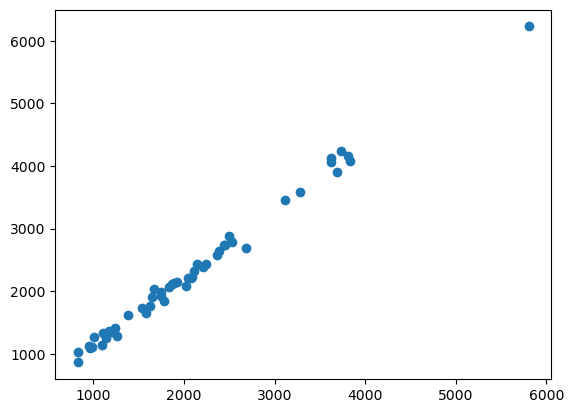

In [39]:
plt.scatter(nu_max_trues, nu_max_fits)

In [46]:
pred_noise_lvls = 2 * 3600 * 10**(-6) *(BOLrandomSysNSRNCAM_T_array)**2
print(pred_noise_lvls)
print(noise_lvls)
print(100*(pred_noise_lvls-noise_lvls)/pred_noise_lvls)
#predicted noise lvls from sig1hr are fractions of a percent off from noise_lvls from end of spectra
#going forward use pred_noise_lvls?

[1.31025668 2.4909121  2.80845    1.275524   1.99600191 1.47026951
 0.95054468 0.82432797 1.90827664 2.43498296 1.89657277 1.21119053
 2.68470777 2.27868575 2.25059336 1.65038119 2.65697327 2.59373075
 2.01522877 1.71865796 2.79424822 0.65473417 1.64384705 2.3509792
 1.83169796 1.40515853 2.10043006 2.01522877 1.42534722 0.75055753
 1.35334153 2.13252529 2.52855066 2.42704528 2.42176036 2.02729265
 2.18237828 2.17486347 1.05589506 2.76877529 1.20559384 2.56375391
 2.11274547 1.74770206 2.6459201  1.96495499 2.85127189 1.13944607
 1.68544804 1.52425804]
[1.26561353e-04 2.02543476e-04 6.20074196e-04 2.43738215e-04
 8.87169364e-05 9.86404208e-05 6.37983273e-04 3.17536421e-04
 5.41013838e-04 1.19325894e-04 9.71337693e-05 5.97402319e-04
 3.39088348e-04 2.09376436e-04 1.14297131e-04 7.21235733e-05
 2.58949526e-04 3.79324738e-04 1.93535444e-04 9.44046017e-05
 5.38284735e-04 7.15254956e-05 4.95448839e-04 3.53824170e-04
 1.56105601e-04 2.77644540e-04 2.94438544e-04 2.49112588e-04
 2.88897295e-0

In [44]:
def threshold_from_x(x, noise_lvl, freq, p):

    powers_noise=fake_signals(freq,100,x*noise_lvl)

    nu_max_metrics_noise = []
    #delta_nu_metrics_noise = []
    #combined_metrics_noise = []
    
    for power in powers_noise:
        nu_max, delta_nu, lags_fit, acf_fit, delta_nu_est, acf_power = find_metric(power, freq)
    
        nu_max_metrics_noise.append(nu_max)
        #delta_nu_metrics_noise.append(delta_nu)
        #combined_metrics_noise.append(nu_max * delta_nu)
    
    nu_max_metrics_noise = np.array(nu_max_metrics_noise)
    #delta_nu_metrics_noise = np.array(delta_nu_metrics_noise)
    #combined_metrics_noise = np.array(combined_metrics_noise)

    threshold = np.percentile(nu_max_metrics_noise, p)

    return threshold

def make_spectrum_noisy(x, power, bg_noise):
    
    spectrum = power + x*bg_noise

    noisy_spec = []
    for x in spectrum:
        a = np.random.uniform(0, 1)
        noisy_spec.append(x * (-np.log(a)))

    return noisy_spec

def make_multiple_noisy_spectra(number, x, power, bg_noise):
    powers_noisy = []

    for _ in range(number):
        power_n = make_spectrum_noisy(x, power, bg_noise)
        powers_noisy.append(power_n)

    return powers_noisy

def detection_probability(number, x, power, freq, bg_noise, sim_thresholds):
    threshold = sim_thresholds[x]
    powers_noisy = make_multiple_noisy_spectra(number, x, power, bg_noise)

    nu_max_metrics_x = []
    delta_nu_metrics_x = []

    for power in powers_noisy:
        nu_max_metric, delta_nu_metric, *_  = find_metric(power,freq)
        nu_max_metrics_x.append(nu_max_metric)
        delta_nu_metrics_x.append(delta_nu_metric)

    nu_max_metrics_x = np.array(nu_max_metrics_x)

    mean_nu_max_metric = np.mean(nu_max_metrics_x)
    detection_prob = np.sum(nu_max_metrics_x > threshold) / len(nu_max_metrics_x)
        
    return mean_nu_max_metric, detection_prob

In [41]:
nu_nyq = np.max(freqs_list[0])
delta_t = 10**(6)/(2*nu_nyq)
N = int(len(freqs_list[0]))
print(f"Nyquist frequency: {nu_nyq}muHz")
print(f"Cadence: {delta_t}s")
print(f"Number of data point: {N}")

Nyquist frequency: 20000.0muHz
Cadence: 25.0s
Number of data point: 49999


In [ ]:
#sig_cads = BOLrandomSysNSRNCAM_T_array * np.sqrt(3600/delta_t)
#print(sig_cads[0])
#np.save("sig_cads.npy", sig_cads)

In [48]:
x_values = [1]

In [ ]:
sim_thresholds_list = []

for pred_noise_lvl in tqdm(pred_noise_lvls):
    sim_thresholds = {
        x: threshold_from_x(x, pred_noise_lvl, freqs_list[0], 99)
        for x in tqdm(x_values)
    }

    sim_thresholds_list.append(sim_thresholds)

np.save("50sim_thresholds_list.npy", sim_thresholds_list)

  0%|          | 0/1 [00:00<?, ?it/s]

In [43]:
mean_nu_max_metrics_list = []
detection_probs_list = []

for power, freq, pred_noise_lvl, sim_thresholds in tqdm(zip(oscillations_noisy, freqs_list, pred_noise_lvls, sim_thresholds_list)):
    mean_nu_max_metrics = []
    detection_probs = []
    
    for x in tqdm(x_values):
        mean_nu_max_metric, detection_prob = detection_probability(50, x, power, freq, pred_noise_lvl, sim_thresholds)
        mean_nu_max_metrics.append(mean_nu_max_metric)
        detection_probs.append(detection_prob)

    mean_nu_max_metrics_list.append(mean_nu_max_metrics)
    detection_probs_list.append(detection_probs)
    
np.save("mean_nu_max_metrics_list.npy", mean_nu_max_metrics_list)
np.save("detection_probs_list.npy", detection_probs_list)

0it [00:00, ?it/s]
100%|██████████| 7/7 [04:02<00:00, 34.58s/it]
1it [04:02, 242.09s/it]
100%|██████████| 7/7 [04:09<00:00, 35.64s/it]
2it [08:11, 246.45s/it]
100%|██████████| 7/7 [04:14<00:00, 36.30s/it]
3it [12:25, 249.93s/it]
100%|██████████| 7/7 [04:14<00:00, 36.30s/it]
4it [16:39, 251.59s/it]
100%|██████████| 7/7 [04:13<00:00, 36.19s/it]
5it [20:53, 252.21s/it]
100%|██████████| 7/7 [04:12<00:00, 36.01s/it]
6it [25:05, 252.17s/it]
100%|██████████| 7/7 [03:41<00:00, 31.71s/it]
7it [28:47, 242.29s/it]
100%|██████████| 7/7 [03:45<00:00, 32.16s/it]
8it [32:32, 236.82s/it]
100%|██████████| 7/7 [03:39<00:00, 31.31s/it]
9it [36:11, 231.31s/it]
100%|██████████| 7/7 [03:57<00:00, 33.86s/it]
10it [40:08, 233.08s/it]
100%|██████████| 7/7 [04:04<00:00, 34.95s/it]
11it [44:13, 236.63s/it]
100%|██████████| 7/7 [03:59<00:00, 34.17s/it]
12it [48:12, 237.41s/it]
100%|██████████| 7/7 [03:42<00:00, 31.78s/it]
13it [51:54, 232.89s/it]
100%|██████████| 7/7 [03:55<00:00, 33.71s/it]
14it [55:50, 233.83s/

In [45]:
mean_nu_max_metrics_list = np.array(mean_nu_max_metrics_list)
detection_probs_list = np.array(detection_probs_list)

In [46]:
print(mean_nu_max_metrics_list)
print(detection_probs_list)

[[6.85680119 4.54790027 2.31940012 2.03826638 2.03639748 1.99278561
  1.97950631]
 [3.92754919 2.54967407 2.23205828 2.06994889 1.97682275 2.01104677
  2.10194566]
 [7.00551735 2.41383276 1.98952024 1.94625592 2.17264442 1.98468527
  1.96531625]
 [6.37406712 2.35980481 1.97502392 1.96802909 2.04368292 1.98414068
  2.05072241]
 [6.97481338 2.22289026 1.97162142 2.03133528 1.98324574 1.94737162
  2.05748593]
 [5.98006769 4.53808018 2.10584761 2.0613863  1.92965815 1.98661557
  2.05251724]
 [6.91778008 3.68816381 2.18061649 2.00406269 2.0199634  2.06776926
  2.05311384]
 [6.07790551 2.12428159 1.99964462 1.96954389 1.98274035 2.07317734
  2.00040495]
 [6.24428848 6.07658533 5.2777094  3.48393995 2.33259083 2.24364614
  2.07560998]
 [6.64287827 3.12629235 2.0279902  1.94810349 1.98300214 1.96863684
  1.98791189]
 [6.22464018 2.56149955 2.00793759 2.0215516  1.95085518 1.98924807
  1.98822445]
 [7.21386612 3.91886764 2.10437175 2.01856658 1.93662031 1.99921324
  2.02350512]
 [5.92888835 2.3

In [18]:
detection_probs_list = np.load("detection_probs_list.npy", allow_pickle = True)
sim_thresholds_list = np.load("sim_thresholds_list.npy", allow_pickle = True)
mean_nu_max_metrics_list = np.load("mean_nu_max_metrics_list.npy", allow_pickle = True)

print(detection_probs_list)

[1.   0.84 0.08 0.02 0.   0.04 0.  ]


In [48]:
x_50s = []
for detection_probs in detection_probs_list:
    x_50 = np.interp(0.5, detection_probs[::-1], x_values[::-1])
    x_50s.append(x_50)

print(x_50s)
    
#threshold_vals1 = np.array([thresholds1[xi] for xi in x_values])

[np.float64(0.3055555555555556), np.float64(0.07333333333333336), np.float64(0.11795454545454546), np.float64(0.11795454545454546), np.float64(0.11555555555555556), np.float64(0.29000000000000004), np.float64(0.2380952380952381), np.float64(0.11106382978723404), np.float64(0.6521739130434783), np.float64(0.18592592592592594), np.float64(0.14194444444444446), np.float64(0.26666666666666666), np.float64(0.13179487179487182), np.float64(0.14194444444444446), np.float64(0.11795454545454546), np.float64(0.30697674418604654), np.float64(0.2888888888888889), np.float64(0.34838709677419355), np.float64(0.1132608695652174), np.float64(0.1584375), np.float64(0.2), np.float64(0.21481481481481485), np.float64(0.2909090909090909), np.float64(0.4380952380952381), np.float64(0.10895833333333334), np.float64(0.1383783783783784), np.float64(0.12875000000000003), np.float64(0.4173913043478261), np.float64(0.3170731707317073), np.float64(0.4600000000000001), np.float64(0.2888888888888889), np.float64(0.4

In [59]:
def sigmoid(x, k, x0):
    return 1 / (1 + np.exp(-k * (x - x0)))

def sigmoid_fit(x, detection_probs, x_50):
    p0 = [x_50, 0.8]
    try:
        params, cov = curve_fit(sigmoid, x, detection_probs, p0=p0)
    except:
        print("Cannot fit sigmoid")
        params = np.nan
    return params

kfits = []
x_50_fits = []

for detection_probs, x_50 in tqdm(zip(detection_probs_list, x_50s)):
    params = sigmoid_fit(x_values, detection_probs, x_50)
    k_fit, x_50_fit = params
    kfits.append(k_fit)
    x_50_fits.append(x_50_fit)

1it [00:00, 95.35it/s]

Cannot fit sigmoid


TypeError: cannot unpack non-iterable float object

In [7]:
sim_thresholds_list = np.load("sim_thresholds_list.npy", allow_pickle = True)
detection_probs_list = np.load("detection_probs_list.npy", allow_pickle = True)

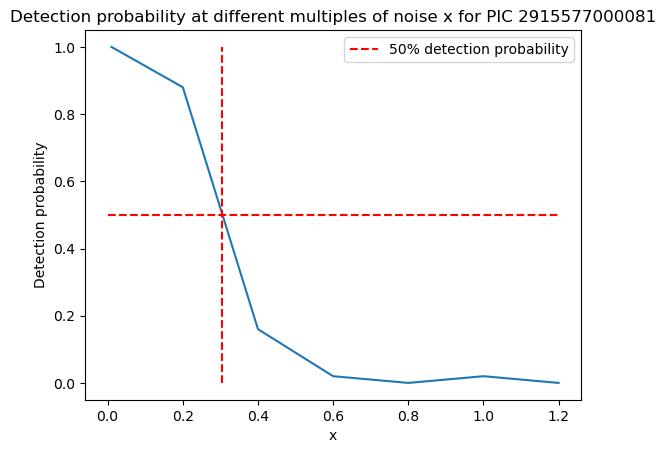

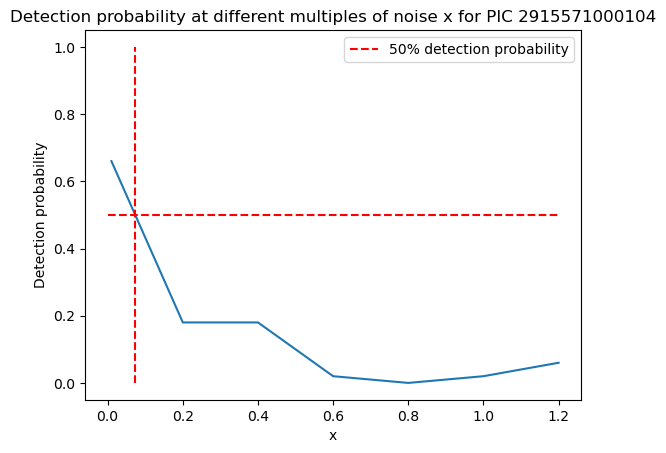

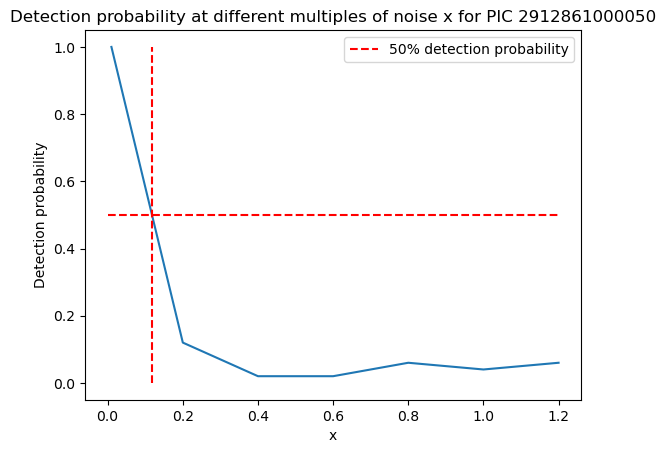

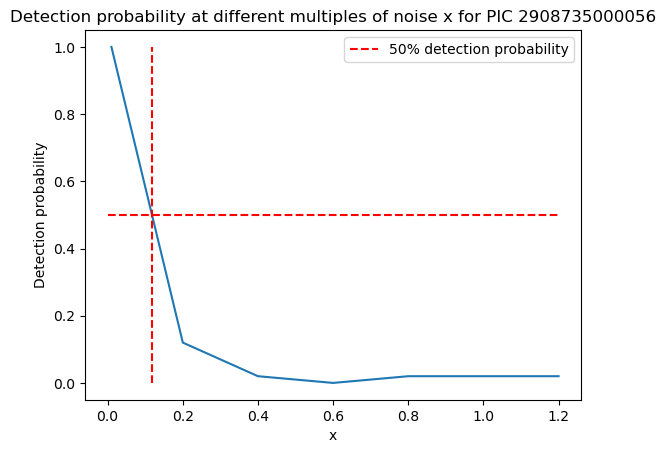

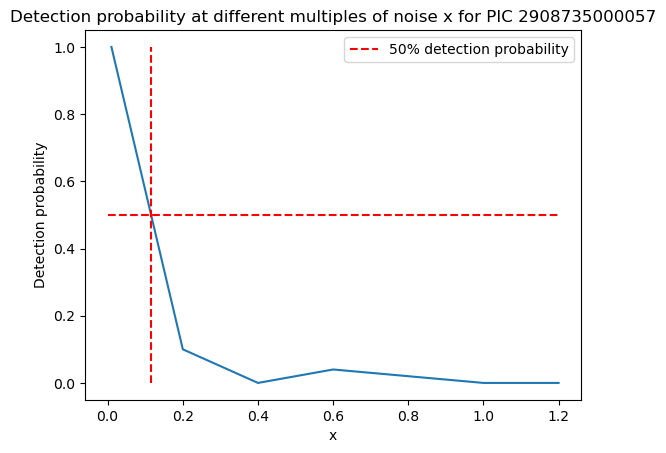

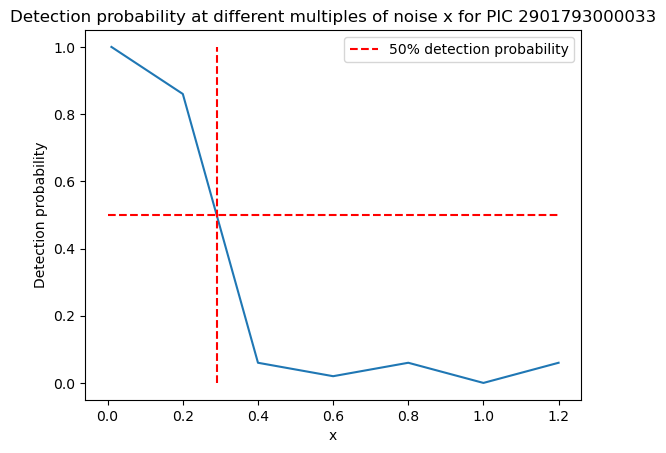

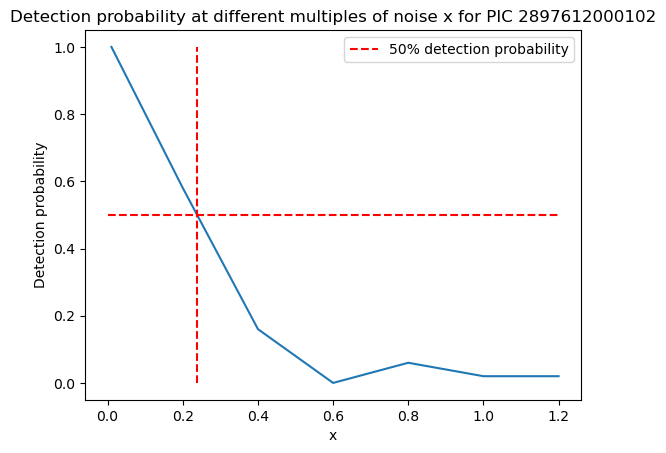

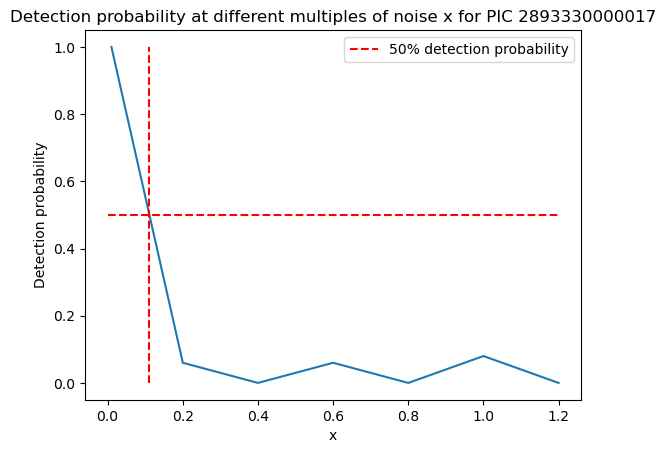

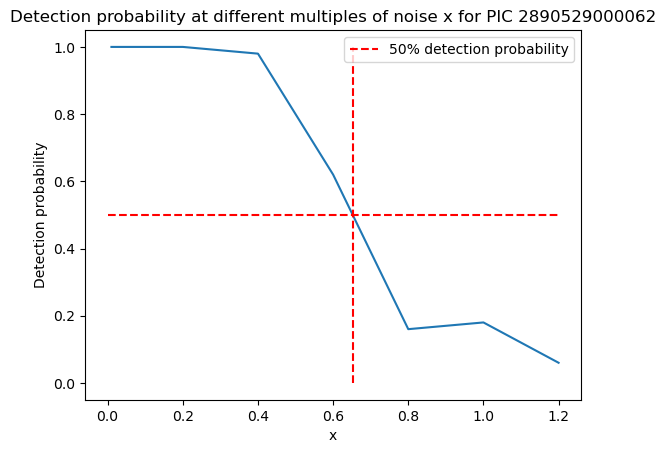

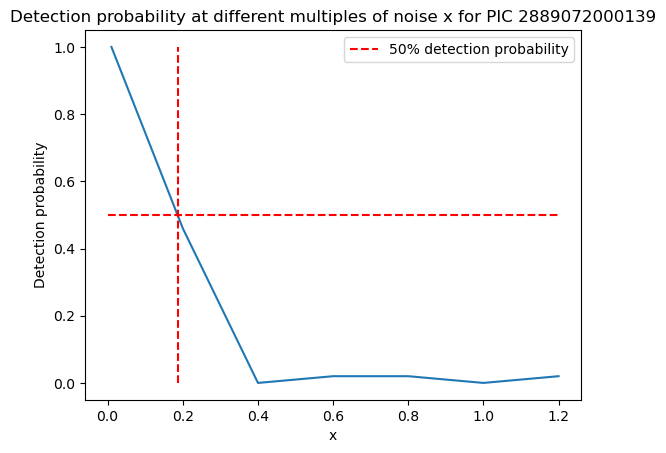

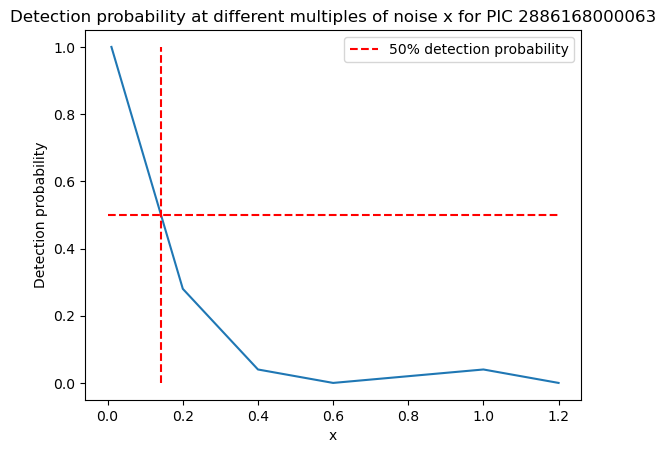

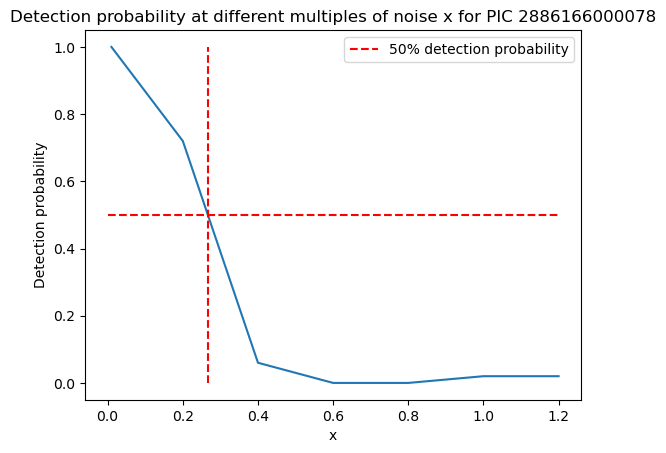

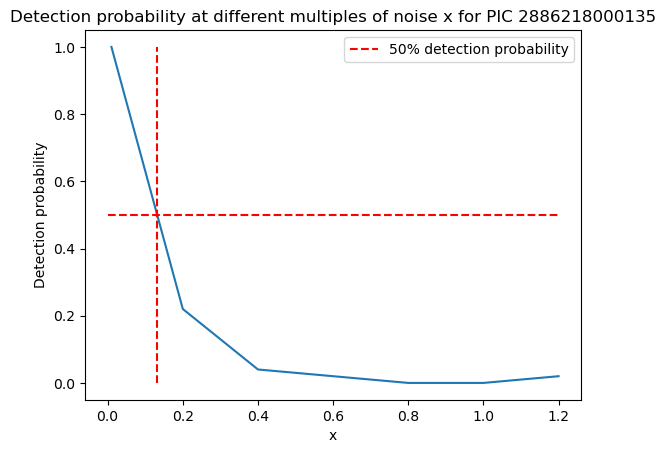

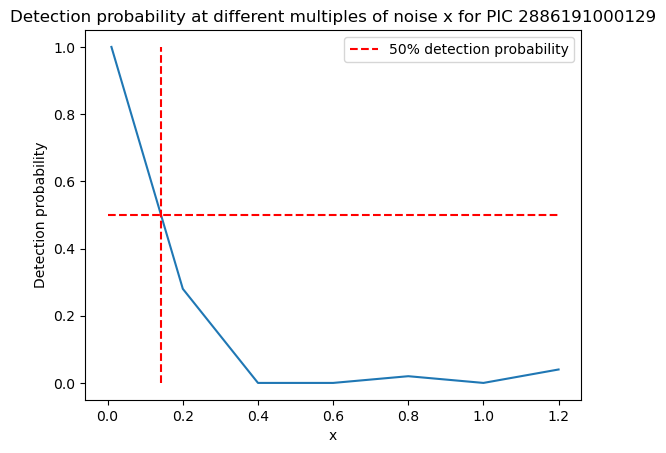

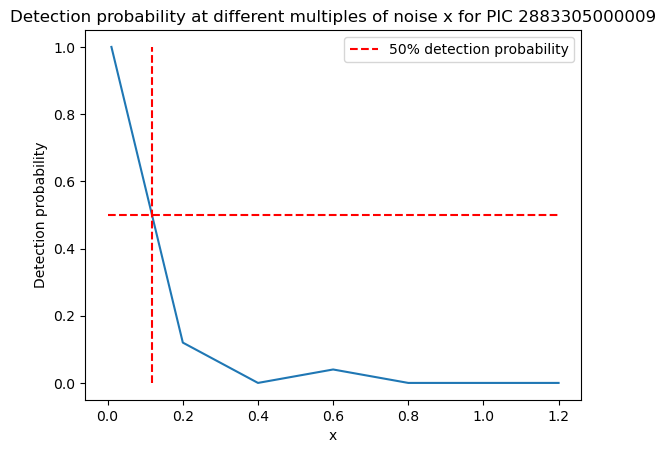

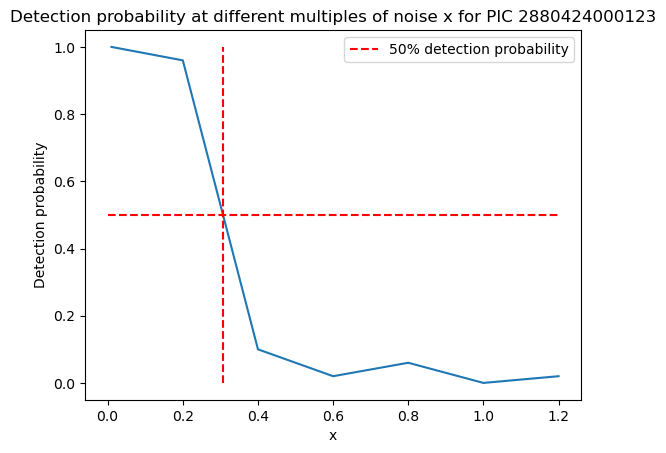

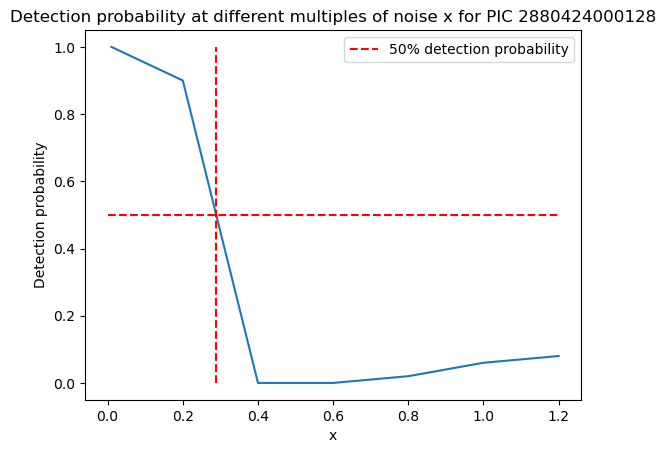

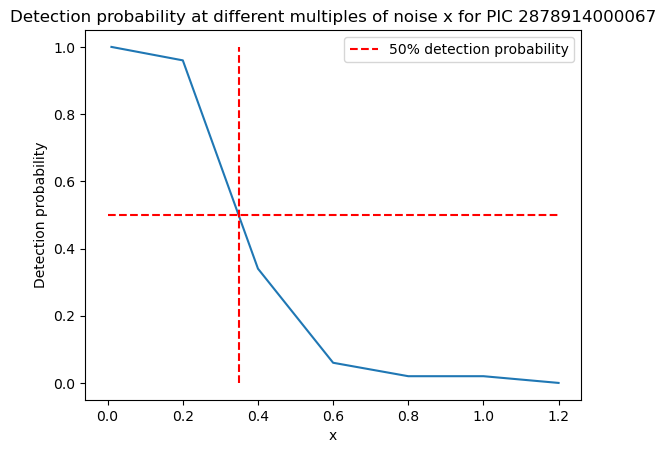

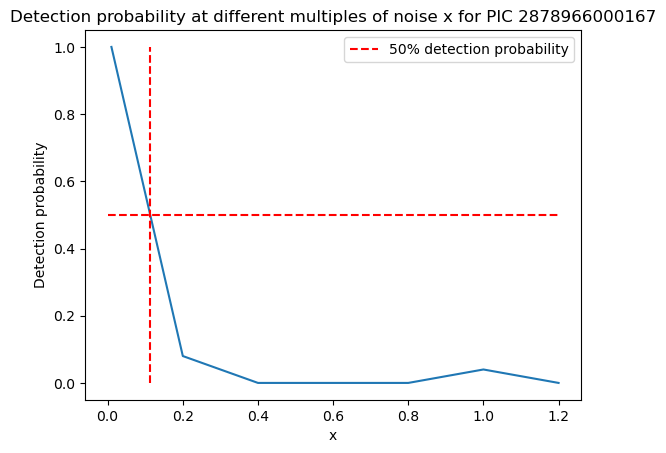

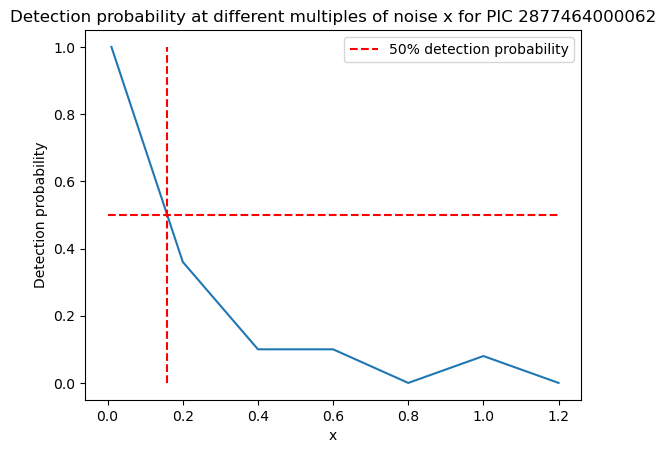

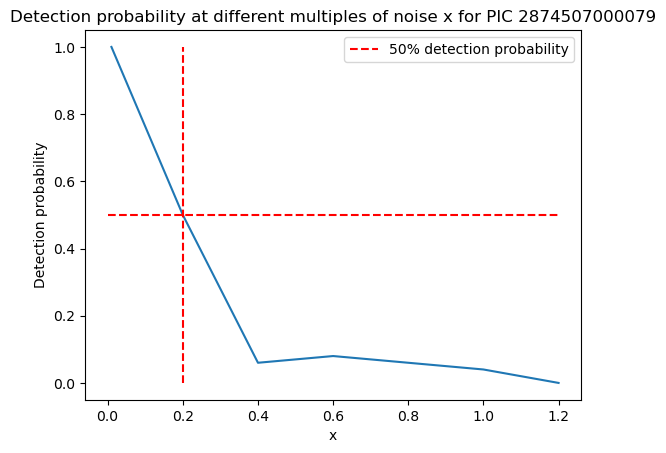

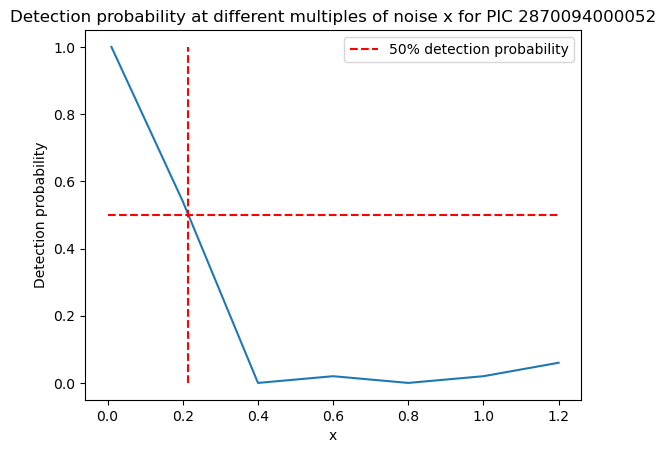

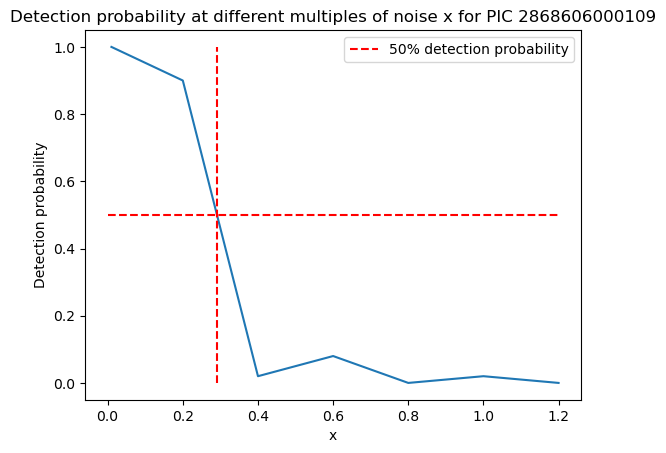

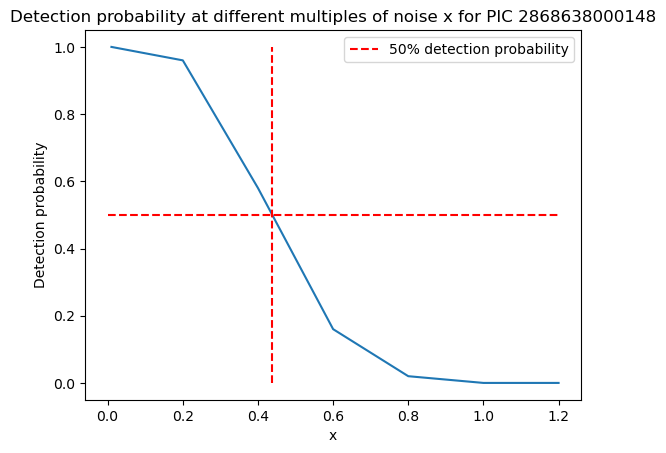

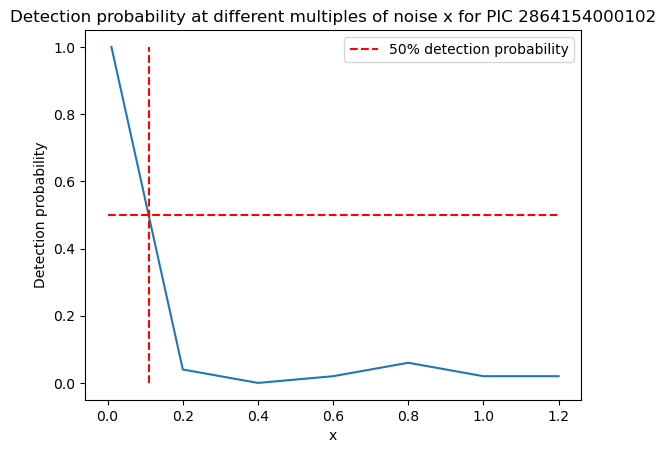

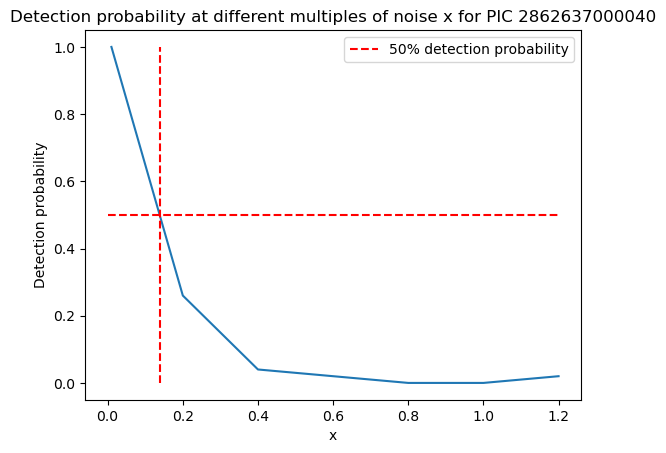

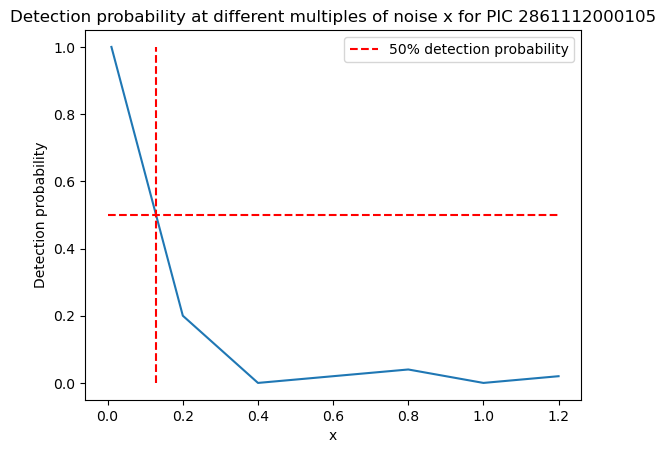

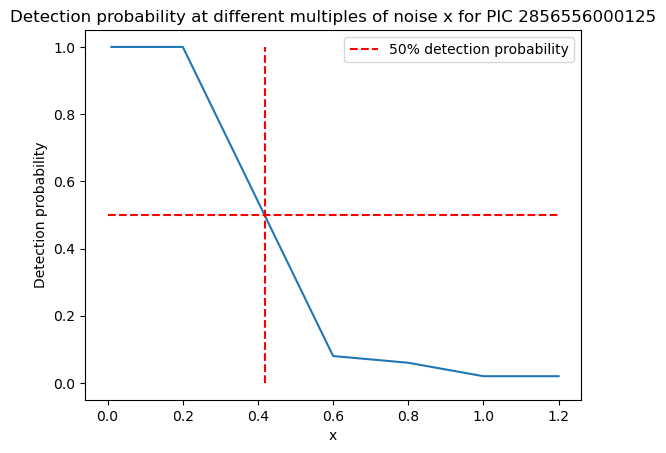

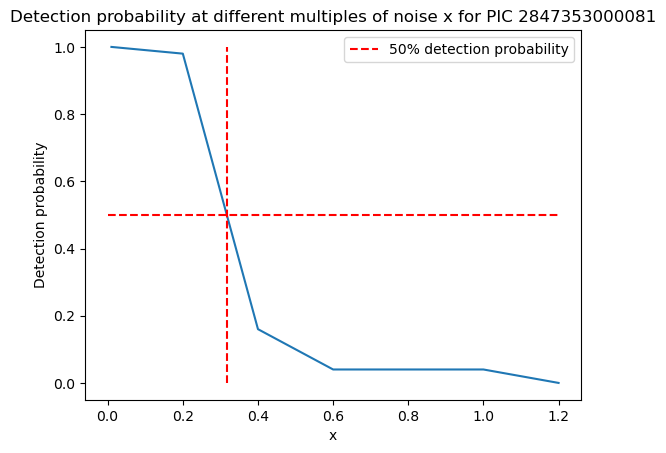

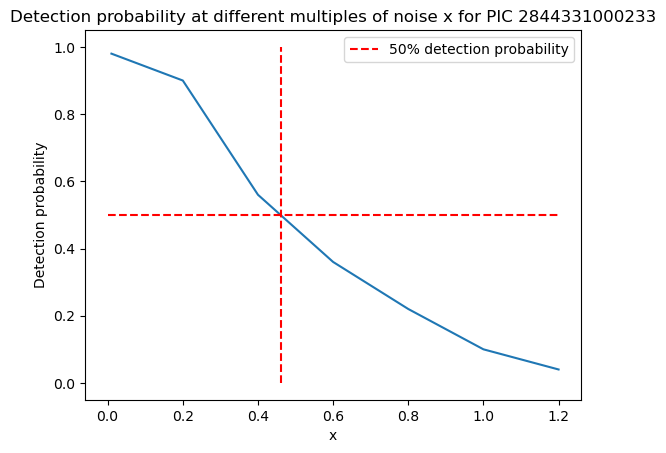

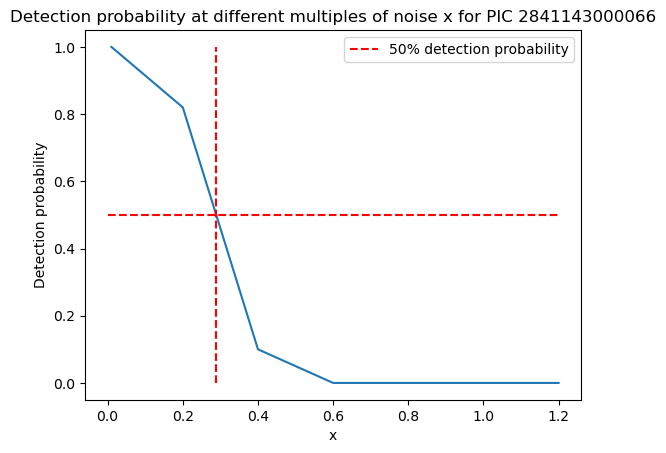

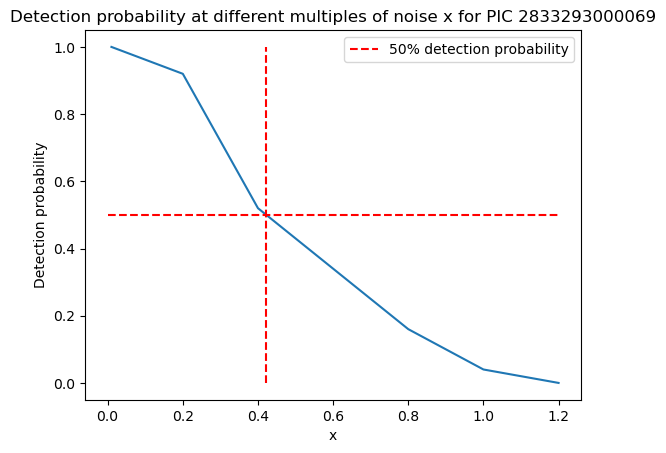

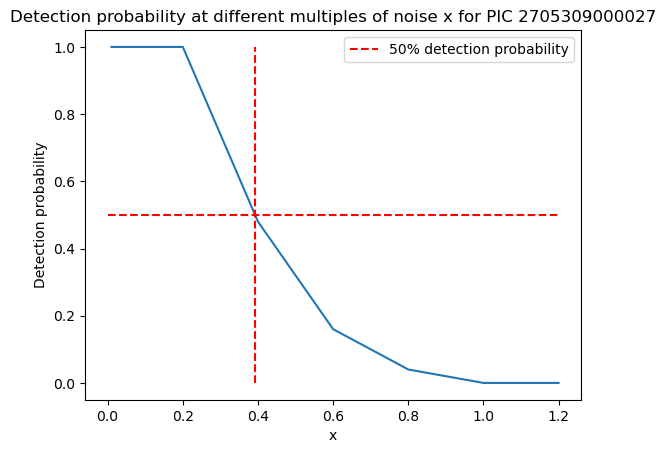

In [60]:
x_smooth = np.linspace(0,1.2,300)

for detection_probs, x_50, label in zip(detection_probs_list, x_50s, labels):
    plt.plot(x_values, detection_probs)
    #plt.plot(x_smooth, sigmoid(x_smooth, k_fit1, x_50_fit1))
    plt.title(f"Detection probability at different multiples of noise x for {label}")
    plt.ylabel("Detection probability")
    plt.xlabel("x")
    plt.hlines(0.5, 0, 1.2, linestyles = "dashed", colors = "red")
    plt.vlines(x_50, 0, 1, linestyles = "dashed", colors = "red", label = "50% detection probability")
    plt.legend()
    plt.show()

0it [00:00, ?it/s]


ValueError: x and y must have same first dimension, but have shapes (7,) and (1,)

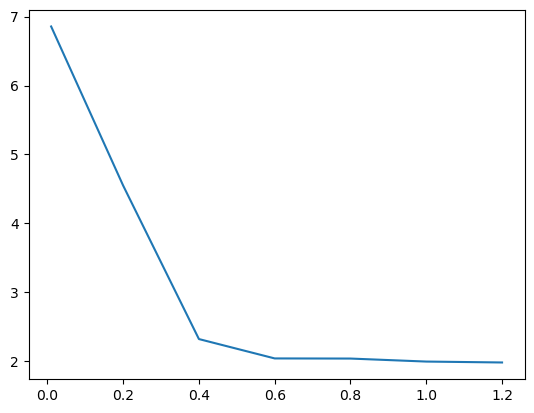

In [64]:
for mean_nu_max_metrics, label, sim_threshold, x_50 in tqdm(zip(mean_nu_max_metrics_list, labels, sim_thresholds_list, x_50s)):
    plt.plot(x_values, mean_nu_max_metrics, label = "Mean nu max SNR")
    plt.plot(x_values, sim_threshold, label = "Threshold SNR")
    plt.title(f"Mean nu max SNR and thresholds SNR against x for {labels[0]}")
    plt.vlines(x_50, 2.5, 4.5, linestyles = "dashed", colors = "red", label = "50% detection probability")
    plt.xlabel("x")
    plt.ylabel("SNR")
    plt.legend()
    plt.show()

In [65]:
sig1hrs_thresh = ((x_50s * pred_noise_lvls)/(2*3600*1e-6))**(1/2)
print(sig1hrs_thresh)
np.save("sig1hrs_thresh.npy", sig1hrs_thresh)

[10.7845584   4.8987952   8.90553188  6.98910817  8.21282071  8.76704868
  9.38815859  8.9014385   9.18210325  9.43877701  7.96460368 10.05426441
  8.41153568  9.55074324  8.64794804  9.51312131 10.67980455  9.35535577
  7.85490253  8.04841065  7.64288042 10.19658621 10.13457283 10.90128885
  7.69766073  8.89433928  7.42034606  9.78778273 11.09292281  8.3965246
 10.51855878  8.66165119  7.37207749]


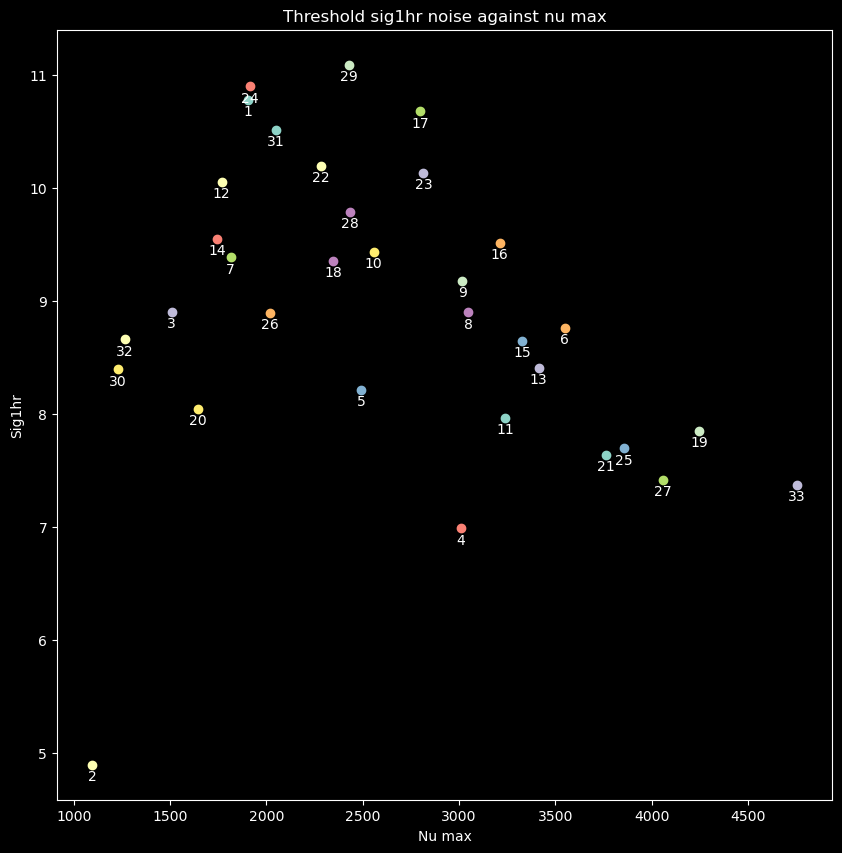

In [108]:
i=1
plt.figure(figsize=(10,10))
plt.style.use("dark_background")
for nu_max_fit, sig1hr, label in zip(nu_max_fits, sig1hrs_thresh, labels):
    plt.scatter(nu_max_fit, sig1hr, label = label)
    plt.text(nu_max_fit, sig1hr-0.04, str(i), ha='center', va='top')
    i+=1
plt.title("Threshold sig1hr noise against nu max")
plt.xlabel("Nu max")
plt.ylabel("Sig1hr")
plt.savefig("thresholds_numax.png", dpi = 600, bbox_inches = "tight")
#plt.legend()

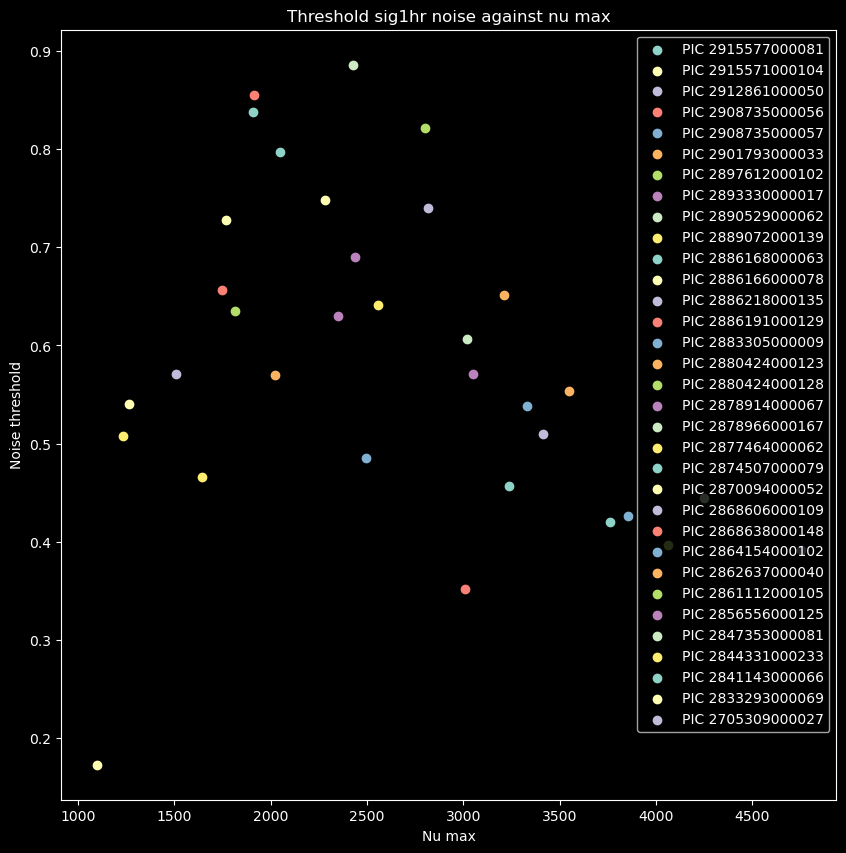

In [109]:
plt.figure(figsize=(10,10))
for nu_max_fit, x_50, pred_noise_lvl, label in zip(nu_max_fits, x_50s, pred_noise_lvls, labels):
    plt.scatter(nu_max_fit, x_50*pred_noise_lvl, label = label)
plt.title("Threshold sig1hr noise against nu max")
plt.xlabel("Nu max")
plt.ylabel("Noise threshold")
plt.legend()

In [107]:
print(x_50s * pred_noise_lvls)

[0.83740824 0.172787   0.57102119 0.35170296 0.48564305 0.55340023
 0.63459016 0.57049637 0.60703934 0.64145168 0.45673136 0.72783528
 0.50942831 0.65676021 0.53846644 0.65159623 0.82121922 0.63016331
 0.44423636 0.46639378 0.42057807 0.74858667 0.73950888 0.85563431
 0.42662866 0.56958675 0.39644306 0.68976497 0.88598114 0.5076117
 0.79660857 0.54017425 0.39130219]


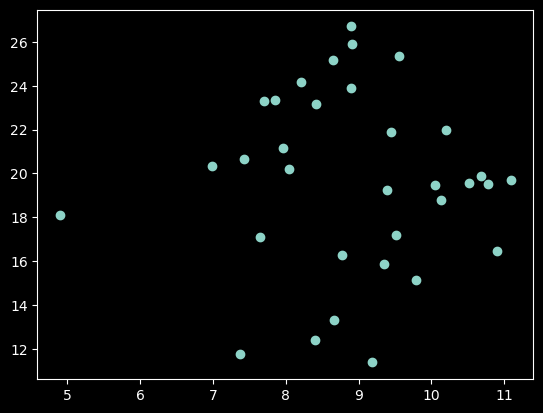

In [111]:
plt.scatter(sig1hrs_thresh, BOLrandomSysNSRNCAM_T_array)